<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/guido-clean/invasive_plants_analysis/classifier_bioclip_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
La struttura del modello utilizzato è simile a quella precedentemente implementata:
le immagini passano attraverso un modello preallenato (BioCLIP o ResNet) da cui vengono estratti gli embedding
gli embedding allenano un semplice classificatore.

La loss function è stata modificata: ogni classe ha il suo peso (dipendente dalla frequenza della classe).

Durante il training le fasi di estrazione degli embedding e predizione del label sono separate (così che il training sia molto più veloce e leggero). Una volta finito il training viene ricostruito il modello intero, così che il classificatore prenda come input l'immagine (non l'embedding) e restituisca il label (in modo che si possa effettuare successivamente explainability sulle immagini e non solo sugli embedding).

Rispetto al modello di Barbara, estraggo gli embeddings tutti insieme (e non separati per training set e validation set), così da poter effettuare cross validation senza dover ogni volta estrarre gli embeddings.

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms, models
from torchvision.transforms import functional as F
# from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
# import seaborn as sns
# import requests
# from io import BytesIO
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
# import random
import math
from collections import Counter
import datetime
import json
import os

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'ai4biological-pattern'...
remote: Enumerating objects: 734684, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 734684 (delta 135), reused 113 (delta 53), pack-reused 734464 (from 3)
Receiving objects: 100% (734684/734684), 8.36 GiB | 22.34 MiB/s, done.
Resolving deltas: 100% (2056/2056), done.
Updating files: 100% (214631/214631), done.
/content/ai4biological-pattern/ai4biological-pattern
Updating files: 100% (214629/214629), done.


In [40]:
def save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, classification_report_dict):
    import datetime
    import json
    import os

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_dir = f"/content/drive/MyDrive/Thesis/{output_dir}/logs"
    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, "training_log.json")

    # Load existing logs (if any)
    if os.path.exists(log_path):
        with open(log_path, "r") as f:
            all_logs = json.load(f)
    else:
        all_logs = []

    # Prepare this run's data
    this_log = {
        "model_name": model_name,
        "timestamp": timestamp,
        "final_train_loss": train_losses[-1] if train_losses else None,
        "final_val_loss": val_losses[-1] if val_losses else None,
        "final_train_accuracy": train_accuracies[-1] if train_accuracies else None,
        "final_val_accuracy": val_accuracies[-1] if val_accuracies else None,
        "classification_report_last_epoch": classification_report_dict[-1] if isinstance(classification_report_dict, list) else classification_report_dict,
        "train_loss_history": train_losses,
        "val_loss_history": val_losses,
        "train_accuracy_history": train_accuracies,
        "val_accuracy_history": val_accuracies
    }

    all_logs.append(this_log)

    # Save updated list
    with open(log_path, "w") as f:
        json.dump(all_logs, f, indent=4)

    print(f"📝 Appended log to {log_path}")


In [3]:
#@title Horizontal flip
def hflip(image):
  return F.hflip(image)

In [4]:
#@title Original Dataset
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.entries = []
        self.label_map = {
            "native": 0,
            "introduced non-invasive": 1,
            "invasive": 2
        }

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d != "metadata"]
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "filtered_metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                continue
            metadata_df = pd.read_csv(meta_path)
            for idx, row in metadata_df.iterrows():
                self.entries.append((taxon, row))  # Just index, don’t open anything

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        taxon, row = self.entries[idx]
        filename = str(row["filename"])
        image_path = os.path.join(self.root_dir, taxon, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.label_map.get(row["label"])
        return image, label, idx

In [5]:
#@title Augmented Dataset
class AugmentedClass1Dataset(Dataset):
  def __init__(self, original_dataset, transform=None):
    self.original_dataset = original_dataset
    self.transform = transform
    self.entries = [entry for entry in original_dataset.entries if original_dataset.label_map.get(entry[1]["label"]) == 1]
    self.root_dir = original_dataset.root_dir

  def __len__(self):
    return len(self.entries)

  def __getitem__(self, idx):
    taxon, row = self.entries[idx]
    filename = str(row['filename'])
    image_path = os.path.join(self.root_dir, taxon, filename)
    image = Image.open(image_path).convert("RGB")
    if self.transform:
        image = self.transform(image)
    label = 1
    return image, label, idx

In [6]:
#@title Return the dataloader of all images and not already separated (also class weights are not present)
def get_data_loader(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=transform,
    )

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    return loader

In [7]:
#@title helper function
def get_augmented_transform(preprocess=None):
    if preprocess:
        # BioCLIP: use its own preprocessing, plus flipping
        return transforms.Compose([
            transforms.Lambda(lambda img: F.hflip(img)),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda img: F.hflip(img)),
            transforms.ToTensor()
        ])

In [8]:
#@title Augmented DataLoader
def get_data_loader_augmented(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        original_transform = preprocess
    else:
        original_transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          # transforms.RandomHorizontalFlip(p=1.0)
        ])

    augmented_transform = get_augmented_transform(preprocess if use_bioclip else None)

    original_dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=original_transform,
    )

    augmented_dataset = AugmentedClass1Dataset(
        original_dataset=original_dataset,
        transform=augmented_transform,
    )

    augmented_loader = DataLoader(augmented_dataset, batch_size=32, shuffle=False)

    return augmented_loader

In [9]:
#@title 2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model():
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer
    print("Model obtained...")

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [10]:
#@title 3. Extract embeddings using the embeddings_extractor and return the embeddings tensors
def extract_embeddings(dataloader, embeddings_extractor, device, embeddings_save_path, augmented=False, use_bioclip=True):
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []

    if use_bioclip:
      with torch.no_grad():
        for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = embeddings_extractor.encode_image(images)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    else:
      with torch.no_grad():
        for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
            images = images.to(device)
            embeddings = embeddings_extractor(images).view(images.size(0), -1)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)
            all_ids.extend(obs_id)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)

    all_embeddings = {
       'embeddings' : embeddings_tensors,
       'labels' : labels_tensors,
       'ids' : obs_id_tensor
    }

    if augmented==False:
      torch.save(all_embeddings, embeddings_save_path)

    # embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return all_embeddings

In [33]:
#@title Split the embeddings 80-20, then add the augmentation to the training set
def split_embeddings(embeddings_dict, augmented_embeddings_dict=None, val_percentage=0.2):

    """Split the embeddings and not the images into training set and validation set"""

    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]

    embedding_size = embeddings_tensors.shape[1] #useful for classifier

    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)

    train_size = int((1-val_percentage) * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    #if using augmentation
    if augmented_embeddings_dict:
      print("Augmenting train dataset...")
      aug_embeddings_tensors = augmented_embeddings_dict["embeddings"]
      aug_labels_tensors = augmented_embeddings_dict["labels"]
      aug_obs_id_tensor = augmented_embeddings_dict["ids"]

      augmented_train_dataset = torch.utils.data.TensorDataset(aug_embeddings_tensors, aug_labels_tensors, aug_obs_id_tensor)

      #concatenate train dataset with augmented train dataset
      train_dataset = ConcatDataset([train_dataset, augmented_train_dataset])

    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[int(label)] += 1

    print("🔢 Class distribution in train set:", label_counts)

    # total = sum(label_counts.values())
    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts[0]),
        1.0 / math.log(1.02 + label_counts[1]),
        1.0 / math.log(1.02 + label_counts[2]),
    ], dtype=torch.float)

    print("⚖️ Class weights:", class_weights)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=True)

    return train_loader, val_loader, class_weights, embedding_size

In [12]:
#@title Classifier
class InvasiveSpeciesClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=256, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(), #consider adding a Dropout layer
            # nn.Dropout(0.3), #We remove the dropout layer
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [51]:
#@title Early Stopping class

#Patience: how many epochs to wait after last improvements
#delta: minimum change in validation to be considered improvement
class EarlyStopping:

    def __init__(self, patience=5, delta=0.01, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [59]:
#@title 4. Training function
def train_classifier(train_loader, val_loader, feature_extractor, classifier, optimizer, criterion, device, output_dir, model_name, num_epoch=10):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    early_stopping = EarlyStopping(patience=10, delta=0, verbose=True)

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        classifier.train()
        running_loss, correct, total = 0, 0, 0

        for embeddings, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, feature_extractor, classifier, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
        print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

        print("\n📋 Classification Report:")
        report_dict = classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0, output_dict=True)
        print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0, output_dict=False))

        #plot confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        classes = ["Native", "NN-NI", "NN-I"]

        # Show all ticks and label them
        ax.set(xticks=np.arange(len(classes)),
              yticks=np.arange(len(classes)),
              xticklabels=classes,
              yticklabels=classes,
              ylabel='True label',
              xlabel='Predicted label',
              title='Validation Confusion Matrix')

        # Rotate the tick labels and set alignment.
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Loop over data dimensions and create text annotations.
        fmt = 'd'
        thresh = cm.max() / 2. if cm.max() > 0 else 1
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], fmt),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")

        fig.tight_layout()
        plt.grid(False)
        plt.show()

        # Check early stopping condition
        early_stopping.check_early_stop(val_loss)

        if early_stopping.stop_training:
          print(f"Early stopping at epoch {epoch}")
          break


    torch.save(classifier.state_dict(), f'classifier_head_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/classifier_head_{model_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies, report_dict

In [14]:
#@title 5. Evaluation function
def evaluate_classifier(loader, feature_extractor, classifier, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [15]:
#@title Full Model
class FullModel(nn.Module):
    def __init__(self, embedding_model, classifier_head):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier_head = classifier_head

    def forward(self, x):
        with torch.no_grad():
            if hasattr(self.encoder, 'encode_image'):
                features = self.encoder.encode_image(x)
            else:
                features = self.encoder(x)

        if features.ndim == 4:
            features = features.view(features.size(0), -1)

        return self.classifier_head(features)

In [43]:
#@title Create model and predict
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None, augmentation=False, output_dir="invasive_species", model_name="prova", embeddings_save_path=None, debug_subset_size=None):
    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if use_bioclip:
        feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version)
        feature_extractor = feature_extractor.to(device)
    else:
        feature_extractor = get_resnet_embeddings_extractor_model()
        feature_extractor = feature_extractor.to(device)
        preprocess = None
    print("Feature extractor obtained..")


    if os.path.exists(embeddings_save_path):

        print("✅ Embeddings already exist, loading from file...")
        embeddings_dict = torch.load(embeddings_save_path)
        # embeddings = embeddings_dict["embeddings"]
        # labels = embeddings_dict["labels"]
        # ids = embeddings_dict["ids"]

        #now get only images of class 1 from the original dataset, pass them to the function and concatenate the original training dataset and the augmented dataset
        img_loader = get_data_loader(root_dir=github_repository)

        if augmentation==True:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository)
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation == True:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None

        #to this function I will pass both extracted embeddings and augmented embeddings (if they exist)
        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2)

    else:

        img_loader = get_data_loader(root_dir=github_repository)
        print("Dataloader obtained..")

        #this function also saves embeddings in the desired path
        #input size is the same for training and validation, is is the size (number of features) of the single embedding.
        embeddings_dict = extract_embeddings(img_loader, feature_extractor, device, use_bioclip, embeddings_save_path)

        if augmentation==True:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository)
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip)

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation == True:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None

        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings(embeddings_dict, augmented_embeddings_dict, val_percentage=0.2)


    classifier = InvasiveSpeciesClassifier(embedding_dim=input_size).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies, report_dict = train_classifier(
        train_loader=embeddings_train_loader,
        val_loader=embeddings_val_loader,
        feature_extractor=feature_extractor,
        classifier=classifier,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=50
    )

    # Save results
    save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, report_dict)

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    full_model = FullModel(feature_extractor, classifier)
    print("Full model built...")
    full_model.eval()
    torch.save(full_model.state_dict(), f'full_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/full_{model_name}.pth'
    torch.save(full_model.state_dict(), google_drive_path)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

In [17]:
#prima versione, nel get_data_loader veniva utilizzato:
#class_weights = torch.tensor([
#        total / label_counts[0],  #Native
#        total / label_counts[1],  #NN Non-Invasive
#        total / label_counts[2],  #NN Invasive
#    ], dtype=torch.float)
# create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, output_dir="invasive_species", model_name="first_attempt_with_class_weighting")

Using device: cuda
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 29/29 [00:06<00:00,  4.77it/s]


Augmenting train dataset...
🔢 Class distribution in train set: Counter({0: 24761, 2: 9642, 1: 1631})
⚖️ Class weights: tensor([0.0988, 0.1352, 0.1090])

🔁 Epoch 1/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1050.74it/s]


📉 Train Loss: 0.7470 | Accuracy: 0.6901
📈 Val Loss:   0.6755 | Accuracy: 0.7142

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.73      0.94      0.82      6195
NN Non-Invasive       0.19      0.02      0.03       177
    NN Invasive       0.54      0.18      0.27      2411

       accuracy                           0.71      8783
      macro avg       0.49      0.38      0.37      8783
   weighted avg       0.67      0.71      0.66      8783



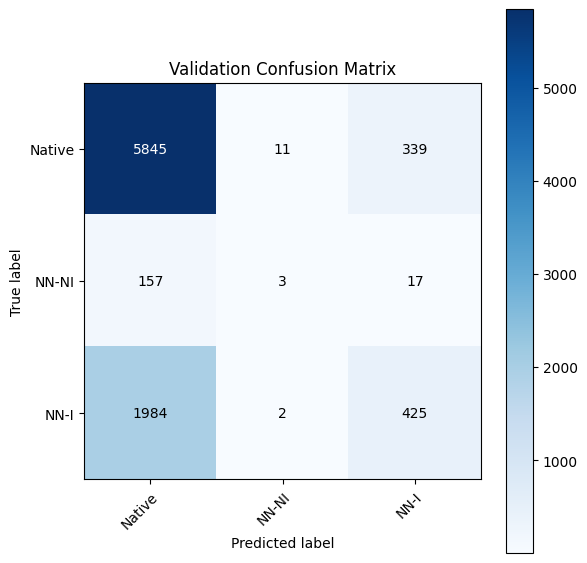


🔁 Epoch 2/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1122.95it/s]


📉 Train Loss: 0.7120 | Accuracy: 0.6949
📈 Val Loss:   0.6636 | Accuracy: 0.7085

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.85      0.81      6195
NN Non-Invasive       0.21      0.05      0.07       177
    NN Invasive       0.51      0.38      0.44      2411

       accuracy                           0.71      8783
      macro avg       0.49      0.43      0.44      8783
   weighted avg       0.68      0.71      0.69      8783



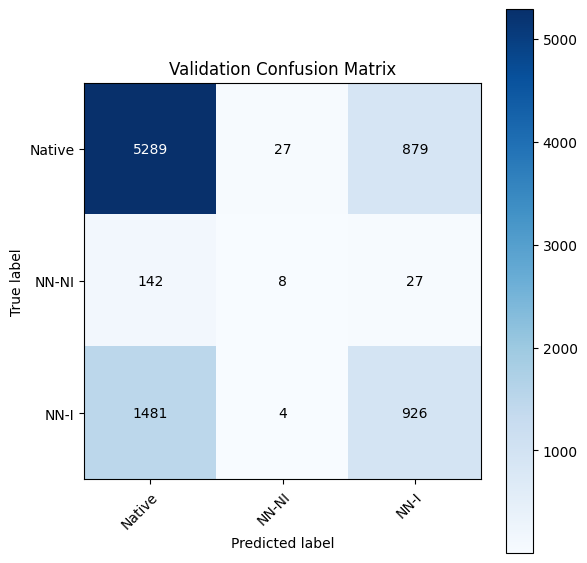


🔁 Epoch 3/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 779.30it/s]


📉 Train Loss: 0.6953 | Accuracy: 0.7006
📈 Val Loss:   0.6558 | Accuracy: 0.7105

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.76      0.86      0.81      6195
NN Non-Invasive       0.20      0.10      0.13       177
    NN Invasive       0.52      0.36      0.42      2411

       accuracy                           0.71      8783
      macro avg       0.49      0.44      0.45      8783
   weighted avg       0.68      0.71      0.69      8783



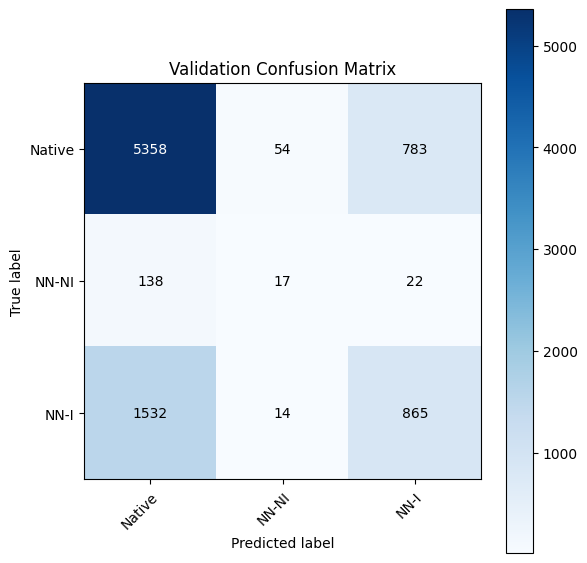


🔁 Epoch 4/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1106.93it/s]


📉 Train Loss: 0.6803 | Accuracy: 0.7082
📈 Val Loss:   0.6332 | Accuracy: 0.7221

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.93      0.83      6195
NN Non-Invasive       0.41      0.07      0.12       177
    NN Invasive       0.56      0.25      0.34      2411

       accuracy                           0.72      8783
      macro avg       0.57      0.41      0.43      8783
   weighted avg       0.69      0.72      0.68      8783



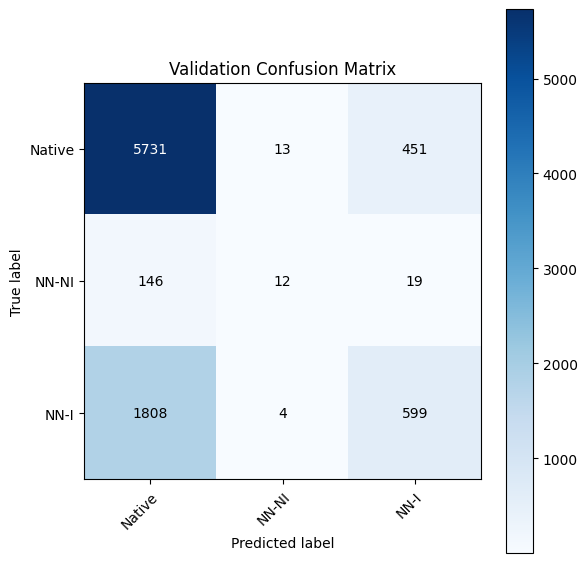


🔁 Epoch 5/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1094.55it/s]


📉 Train Loss: 0.6679 | Accuracy: 0.7128
📈 Val Loss:   0.6359 | Accuracy: 0.7216

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.92      0.83      6195
NN Non-Invasive       0.24      0.12      0.16       177
    NN Invasive       0.57      0.26      0.36      2411

       accuracy                           0.72      8783
      macro avg       0.52      0.43      0.45      8783
   weighted avg       0.69      0.72      0.68      8783



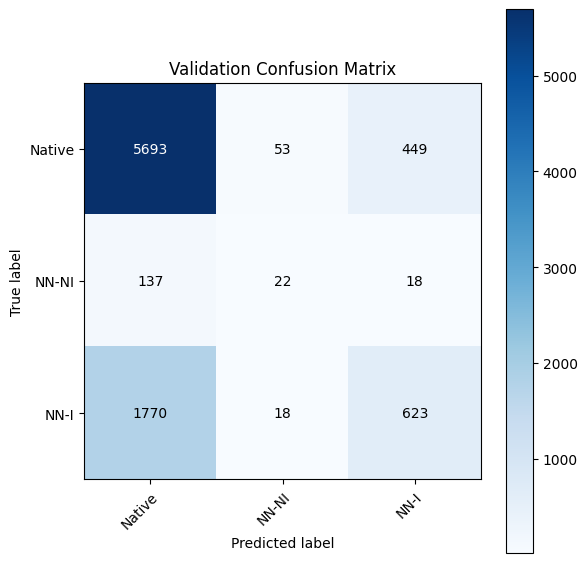


🔁 Epoch 6/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1097.44it/s]


📉 Train Loss: 0.6564 | Accuracy: 0.7168
📈 Val Loss:   0.6152 | Accuracy: 0.7245

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.91      0.82      6195
NN Non-Invasive       0.56      0.08      0.14       177
    NN Invasive       0.56      0.30      0.39      2411

       accuracy                           0.72      8783
      macro avg       0.62      0.43      0.45      8783
   weighted avg       0.70      0.72      0.69      8783



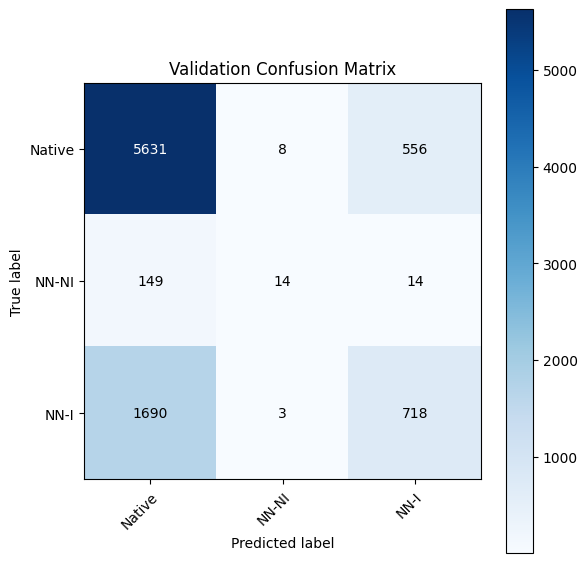


🔁 Epoch 7/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1072.22it/s]


📉 Train Loss: 0.6455 | Accuracy: 0.7223
📈 Val Loss:   0.6188 | Accuracy: 0.7264

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.93      0.83      6195
NN Non-Invasive       0.38      0.12      0.18       177
    NN Invasive       0.59      0.24      0.34      2411

       accuracy                           0.73      8783
      macro avg       0.57      0.43      0.45      8783
   weighted avg       0.70      0.73      0.68      8783



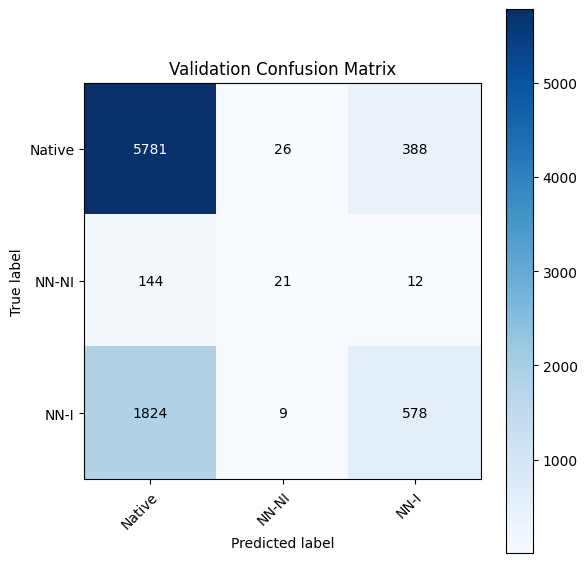


🔁 Epoch 8/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 734.75it/s]


📉 Train Loss: 0.6347 | Accuracy: 0.7274
📈 Val Loss:   0.6186 | Accuracy: 0.7256

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.92      0.83      6195
NN Non-Invasive       0.31      0.14      0.19       177
    NN Invasive       0.58      0.27      0.37      2411

       accuracy                           0.73      8783
      macro avg       0.55      0.44      0.46      8783
   weighted avg       0.70      0.73      0.69      8783



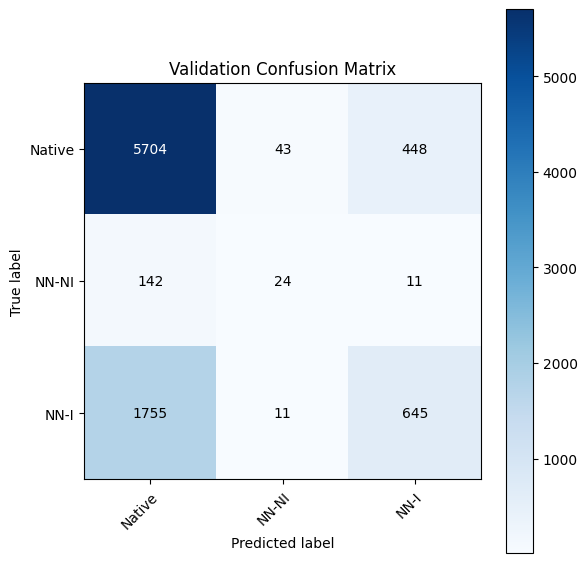


🔁 Epoch 9/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1053.88it/s]


📉 Train Loss: 0.6269 | Accuracy: 0.7302
📈 Val Loss:   0.6191 | Accuracy: 0.7236

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.74      0.94      0.83      6195
NN Non-Invasive       0.30      0.11      0.16       177
    NN Invasive       0.60      0.21      0.31      2411

       accuracy                           0.72      8783
      macro avg       0.55      0.42      0.44      8783
   weighted avg       0.69      0.72      0.67      8783



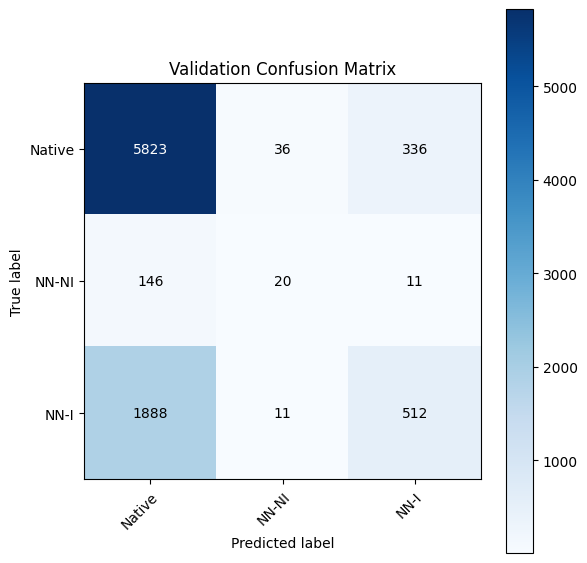


🔁 Epoch 10/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1104.81it/s]


📉 Train Loss: 0.6180 | Accuracy: 0.7376
📈 Val Loss:   0.6091 | Accuracy: 0.7246

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.76      0.91      0.82      6195
NN Non-Invasive       0.30      0.14      0.19       177
    NN Invasive       0.57      0.30      0.39      2411

       accuracy                           0.72      8783
      macro avg       0.54      0.45      0.47      8783
   weighted avg       0.70      0.72      0.69      8783



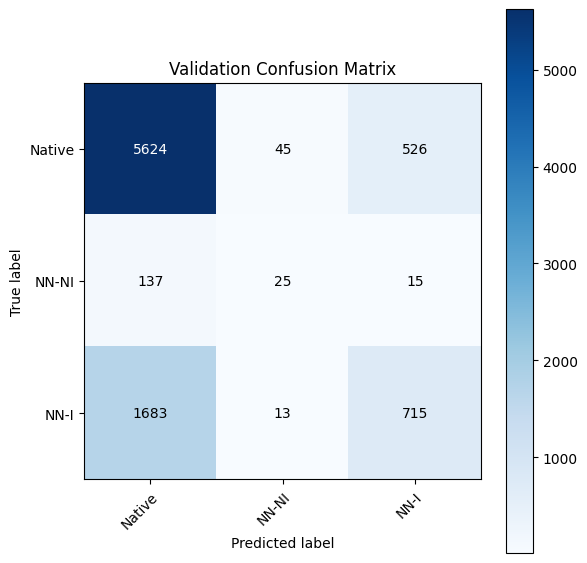


🔁 Epoch 11/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1052.92it/s]


📉 Train Loss: 0.6082 | Accuracy: 0.7384
📈 Val Loss:   0.6152 | Accuracy: 0.7225

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.79      0.84      0.81      6195
NN Non-Invasive       0.28      0.20      0.23       177
    NN Invasive       0.54      0.46      0.50      2411

       accuracy                           0.72      8783
      macro avg       0.54      0.50      0.51      8783
   weighted avg       0.71      0.72      0.71      8783



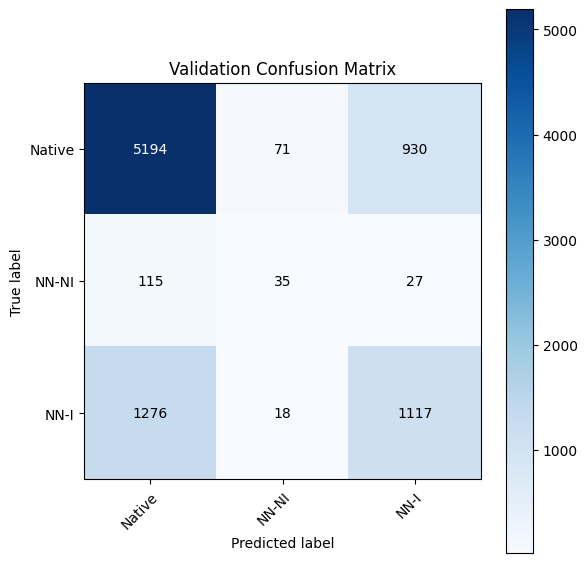


🔁 Epoch 12/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 748.86it/s]


📉 Train Loss: 0.5988 | Accuracy: 0.7434
📈 Val Loss:   0.6156 | Accuracy: 0.7273

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.89      0.82      6195
NN Non-Invasive       0.30      0.28      0.29       177
    NN Invasive       0.57      0.35      0.43      2411

       accuracy                           0.73      8783
      macro avg       0.55      0.51      0.52      8783
   weighted avg       0.71      0.73      0.71      8783



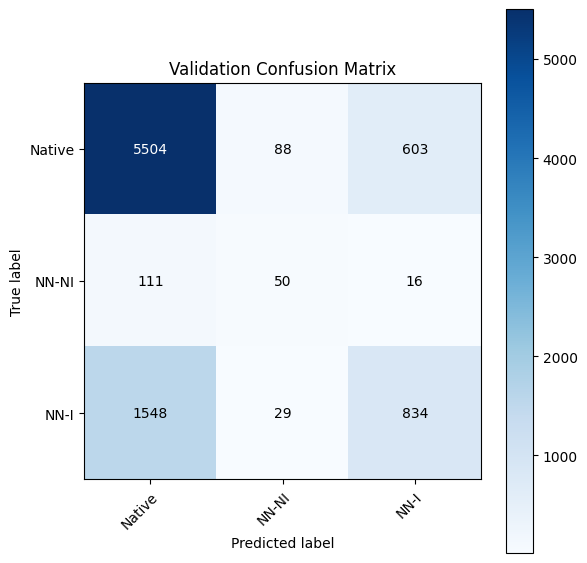


🔁 Epoch 13/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1058.52it/s]


📉 Train Loss: 0.5905 | Accuracy: 0.7486
📈 Val Loss:   0.6090 | Accuracy: 0.7296

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.92      0.83      6195
NN Non-Invasive       0.32      0.15      0.21       177
    NN Invasive       0.60      0.28      0.38      2411

       accuracy                           0.73      8783
      macro avg       0.56      0.45      0.47      8783
   weighted avg       0.70      0.73      0.69      8783



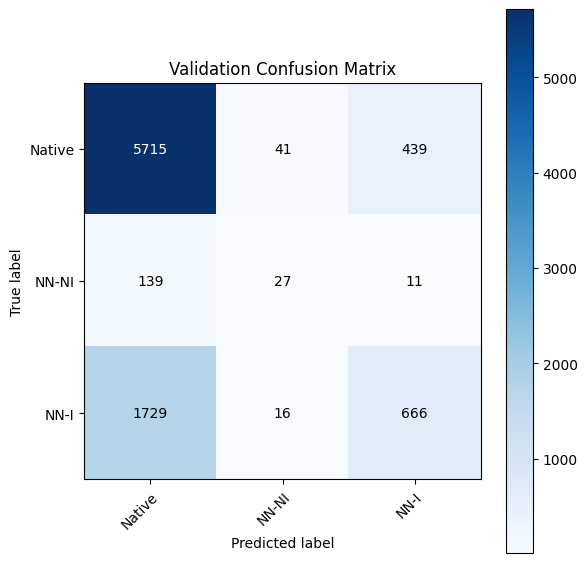


🔁 Epoch 14/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1096.43it/s]


📉 Train Loss: 0.5840 | Accuracy: 0.7508
📈 Val Loss:   0.6053 | Accuracy: 0.7255

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.76      0.89      0.82      6195
NN Non-Invasive       0.30      0.21      0.25       177
    NN Invasive       0.57      0.33      0.42      2411

       accuracy                           0.73      8783
      macro avg       0.54      0.48      0.50      8783
   weighted avg       0.70      0.73      0.70      8783



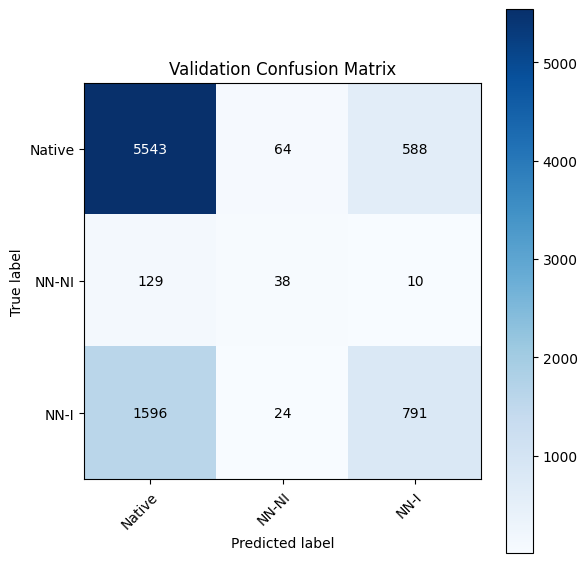


🔁 Epoch 15/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1072.00it/s]


📉 Train Loss: 0.5741 | Accuracy: 0.7586
📈 Val Loss:   0.6148 | Accuracy: 0.7280

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.76      0.92      0.83      6195
NN Non-Invasive       0.29      0.21      0.25       177
    NN Invasive       0.60      0.28      0.38      2411

       accuracy                           0.73      8783
      macro avg       0.55      0.47      0.49      8783
   weighted avg       0.70      0.73      0.69      8783



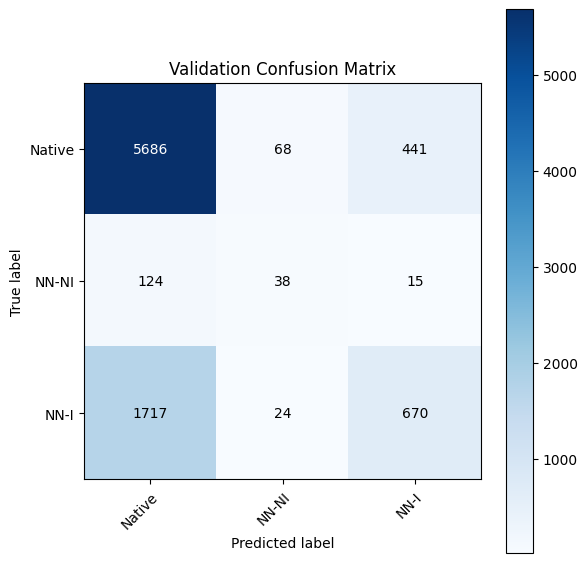


🔁 Epoch 16/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1040.26it/s]


📉 Train Loss: 0.5670 | Accuracy: 0.7580
📈 Val Loss:   0.6100 | Accuracy: 0.7262

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.89      0.82      6195
NN Non-Invasive       0.28      0.30      0.29       177
    NN Invasive       0.58      0.34      0.43      2411

       accuracy                           0.73      8783
      macro avg       0.54      0.51      0.51      8783
   weighted avg       0.71      0.73      0.70      8783



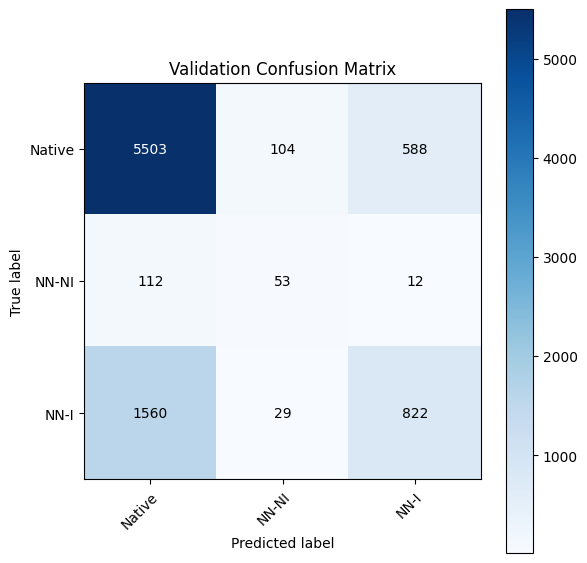


🔁 Epoch 17/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 730.90it/s]


📉 Train Loss: 0.5574 | Accuracy: 0.7646
📈 Val Loss:   0.6227 | Accuracy: 0.7298

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.94      0.83      6195
NN Non-Invasive       0.33      0.23      0.27       177
    NN Invasive       0.64      0.22      0.32      2411

       accuracy                           0.73      8783
      macro avg       0.57      0.46      0.48      8783
   weighted avg       0.71      0.73      0.68      8783



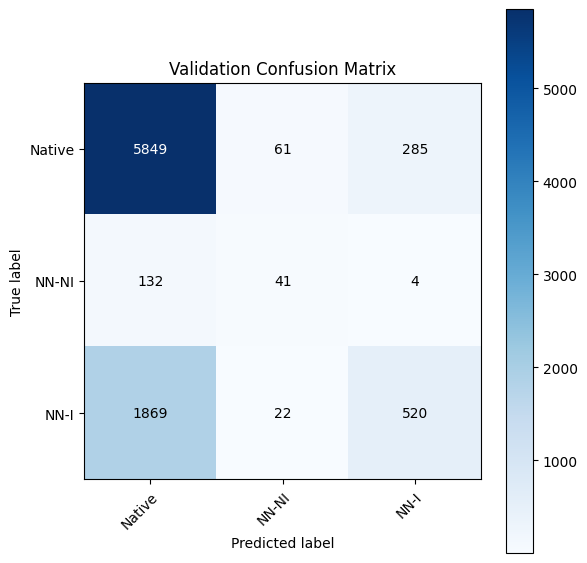


🔁 Epoch 18/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1060.53it/s]


📉 Train Loss: 0.5495 | Accuracy: 0.7705
📈 Val Loss:   0.6113 | Accuracy: 0.7228

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.88      0.82      6195
NN Non-Invasive       0.33      0.37      0.35       177
    NN Invasive       0.56      0.34      0.42      2411

       accuracy                           0.72      8783
      macro avg       0.55      0.53      0.53      8783
   weighted avg       0.70      0.72      0.70      8783



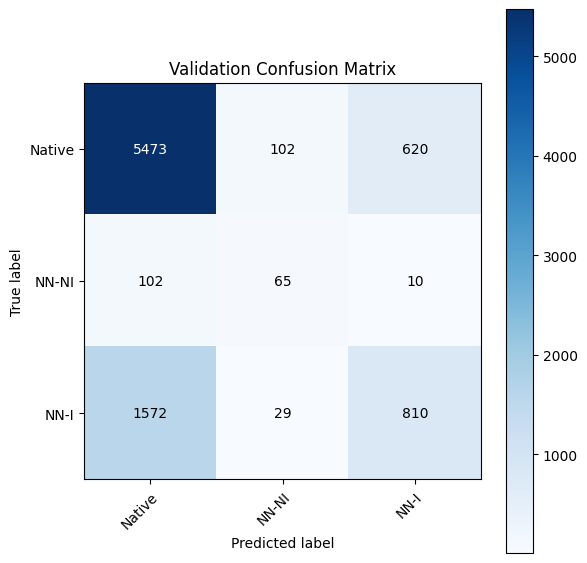


🔁 Epoch 19/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1032.04it/s]


📉 Train Loss: 0.5430 | Accuracy: 0.7715
📈 Val Loss:   0.6052 | Accuracy: 0.7290

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.75      0.92      0.83      6195
NN Non-Invasive       0.35      0.23      0.27       177
    NN Invasive       0.60      0.28      0.38      2411

       accuracy                           0.73      8783
      macro avg       0.57      0.47      0.49      8783
   weighted avg       0.70      0.73      0.69      8783



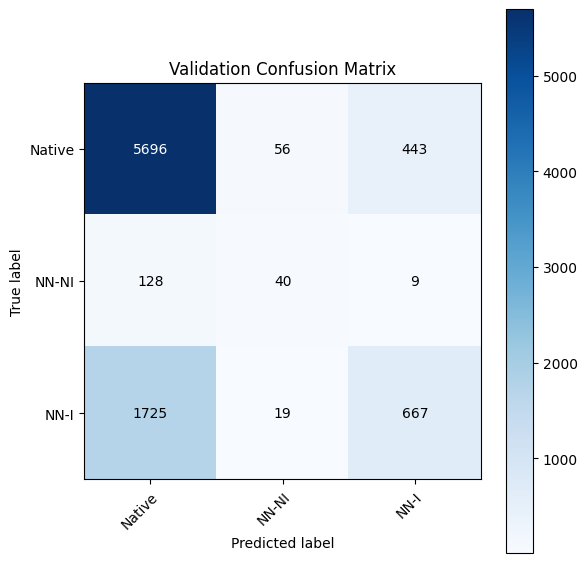


🔁 Epoch 20/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1044.22it/s]


📉 Train Loss: 0.5346 | Accuracy: 0.7758
📈 Val Loss:   0.5948 | Accuracy: 0.7290

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.89      0.82      6195
NN Non-Invasive       0.38      0.21      0.27       177
    NN Invasive       0.57      0.36      0.44      2411

       accuracy                           0.73      8783
      macro avg       0.57      0.49      0.51      8783
   weighted avg       0.71      0.73      0.71      8783



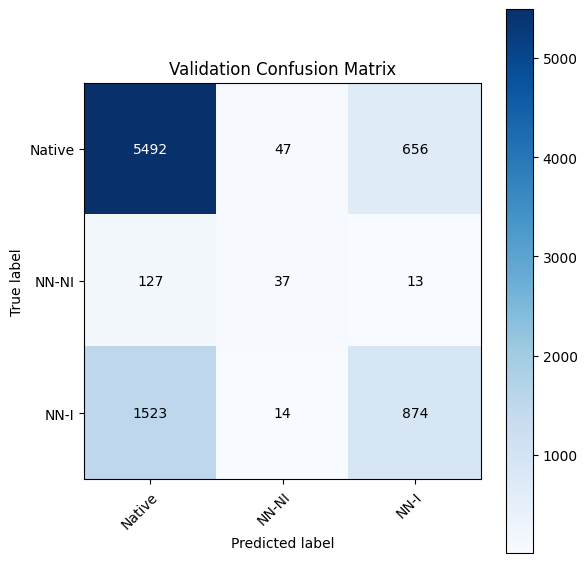


🔁 Epoch 21/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1043.64it/s]


📉 Train Loss: 0.5275 | Accuracy: 0.7782
📈 Val Loss:   0.5948 | Accuracy: 0.7270

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.78      0.85      0.82      6195
NN Non-Invasive       0.36      0.28      0.31       177
    NN Invasive       0.55      0.43      0.48      2411

       accuracy                           0.73      8783
      macro avg       0.56      0.52      0.54      8783
   weighted avg       0.71      0.73      0.72      8783



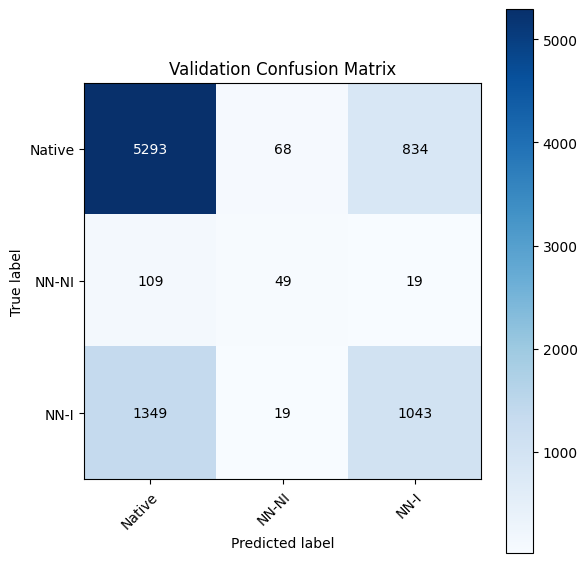


🔁 Epoch 22/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 813.40it/s]


📉 Train Loss: 0.5178 | Accuracy: 0.7833
📈 Val Loss:   0.5928 | Accuracy: 0.7272

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.78      0.86      0.82      6195
NN Non-Invasive       0.35      0.19      0.25       177
    NN Invasive       0.55      0.42      0.48      2411

       accuracy                           0.73      8783
      macro avg       0.56      0.49      0.51      8783
   weighted avg       0.71      0.73      0.71      8783



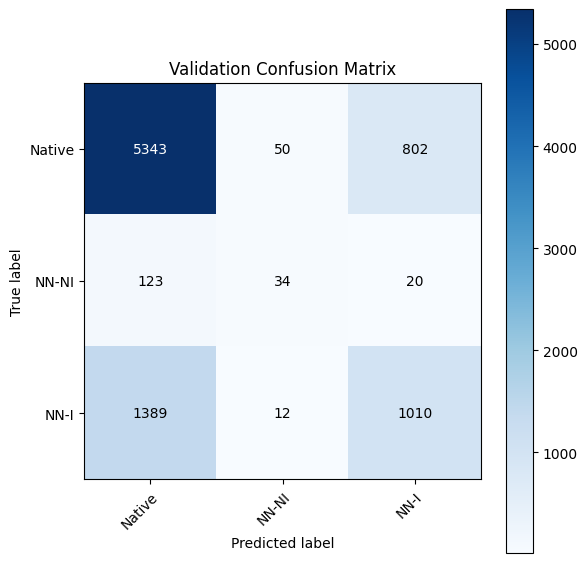


🔁 Epoch 23/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 988.60it/s]


📉 Train Loss: 0.5114 | Accuracy: 0.7874
📈 Val Loss:   0.5935 | Accuracy: 0.7254

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.79      0.85      0.81      6195
NN Non-Invasive       0.41      0.28      0.33       177
    NN Invasive       0.54      0.45      0.49      2411

       accuracy                           0.73      8783
      macro avg       0.58      0.52      0.55      8783
   weighted avg       0.71      0.73      0.72      8783



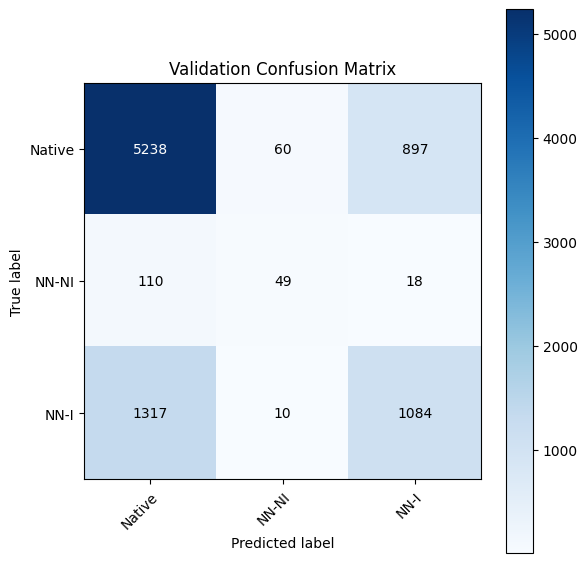


🔁 Epoch 24/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1053.03it/s]


📉 Train Loss: 0.5019 | Accuracy: 0.7904
📈 Val Loss:   0.5996 | Accuracy: 0.7281

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.89      0.82      6195
NN Non-Invasive       0.39      0.29      0.34       177
    NN Invasive       0.57      0.35      0.43      2411

       accuracy                           0.73      8783
      macro avg       0.58      0.51      0.53      8783
   weighted avg       0.70      0.73      0.71      8783



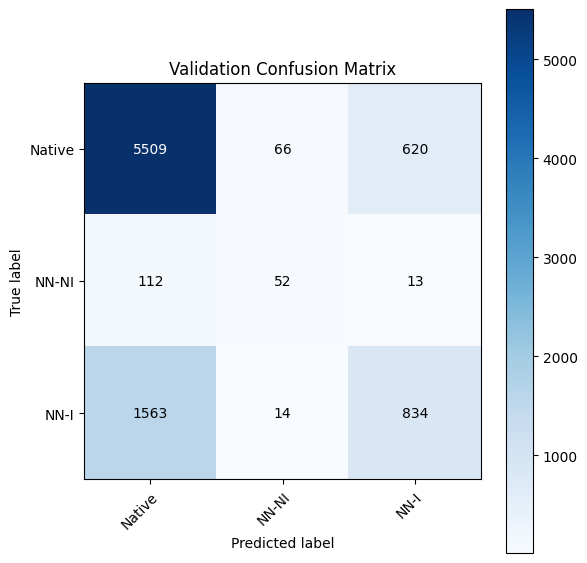


🔁 Epoch 25/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1029.76it/s]


📉 Train Loss: 0.4951 | Accuracy: 0.7950
📈 Val Loss:   0.6127 | Accuracy: 0.7123

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.79      0.80      6195
NN Non-Invasive       0.34      0.34      0.34       177
    NN Invasive       0.51      0.54      0.52      2411

       accuracy                           0.71      8783
      macro avg       0.55      0.56      0.55      8783
   weighted avg       0.72      0.71      0.71      8783



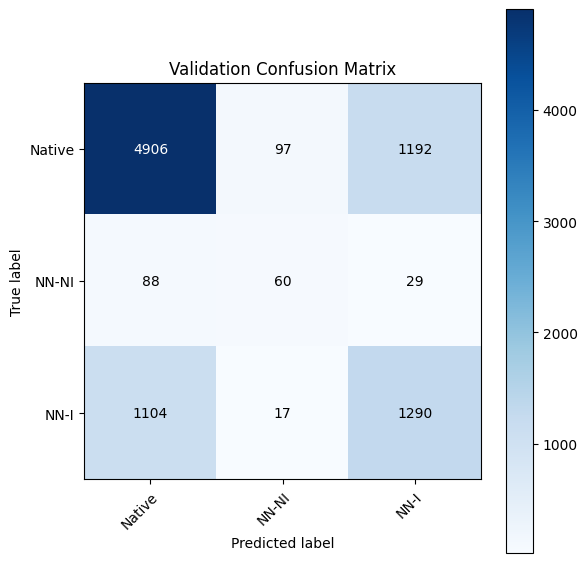


🔁 Epoch 26/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 782.56it/s]


📉 Train Loss: 0.4874 | Accuracy: 0.7987
📈 Val Loss:   0.6072 | Accuracy: 0.7336

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.90      0.83      6195
NN Non-Invasive       0.32      0.33      0.33       177
    NN Invasive       0.60      0.33      0.43      2411

       accuracy                           0.73      8783
      macro avg       0.56      0.52      0.53      8783
   weighted avg       0.71      0.73      0.71      8783



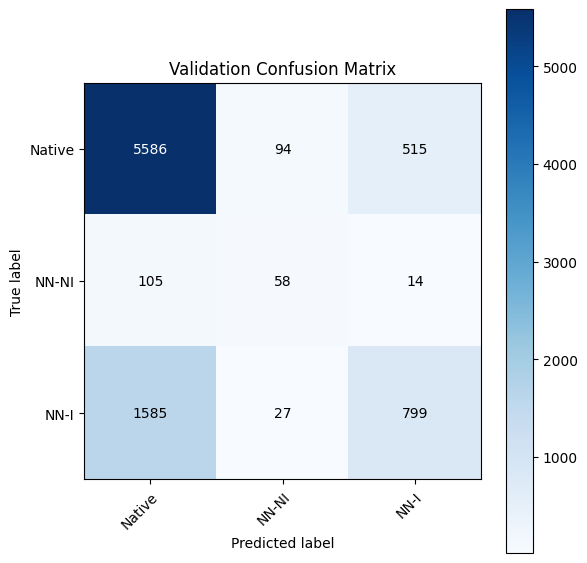


🔁 Epoch 27/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1050.95it/s]


📉 Train Loss: 0.4795 | Accuracy: 0.8025
📈 Val Loss:   0.6376 | Accuracy: 0.7080

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.79      0.82      0.80      6195
NN Non-Invasive       0.23      0.53      0.32       177
    NN Invasive       0.54      0.42      0.47      2411

       accuracy                           0.71      8783
      macro avg       0.52      0.59      0.53      8783
   weighted avg       0.71      0.71      0.70      8783



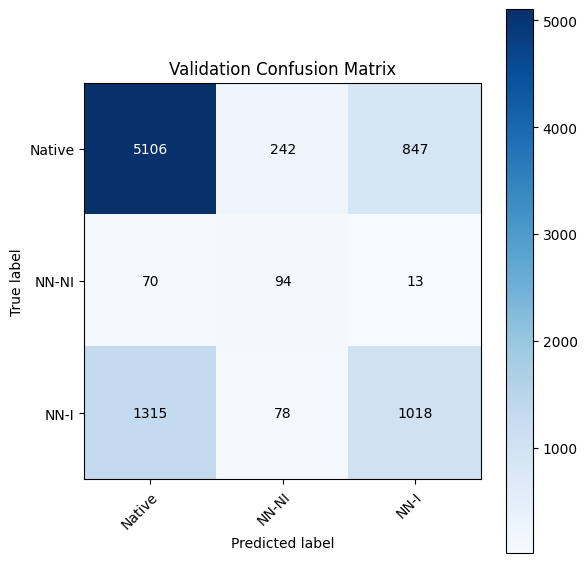


🔁 Epoch 28/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 988.20it/s]


📉 Train Loss: 0.4751 | Accuracy: 0.8069
📈 Val Loss:   0.6039 | Accuracy: 0.7256

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.87      0.82      6195
NN Non-Invasive       0.33      0.39      0.35       177
    NN Invasive       0.57      0.37      0.45      2411

       accuracy                           0.73      8783
      macro avg       0.56      0.55      0.54      8783
   weighted avg       0.71      0.73      0.71      8783



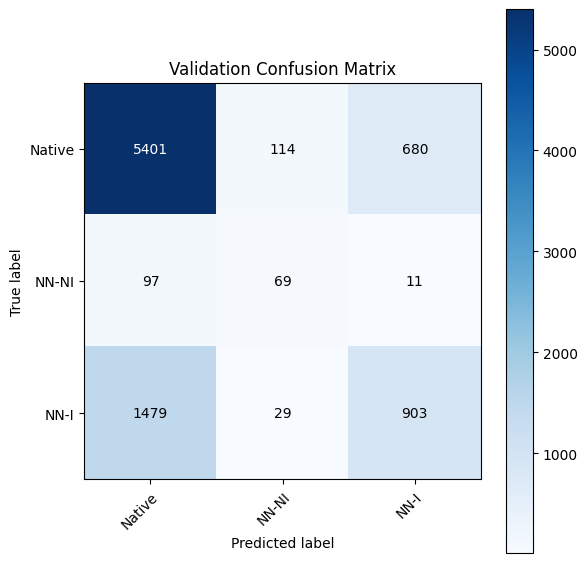


🔁 Epoch 29/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1005.74it/s]


📉 Train Loss: 0.4661 | Accuracy: 0.8069
📈 Val Loss:   0.5999 | Accuracy: 0.7234

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.79      0.83      0.81      6195
NN Non-Invasive       0.40      0.25      0.31       177
    NN Invasive       0.53      0.48      0.51      2411

       accuracy                           0.72      8783
      macro avg       0.58      0.52      0.54      8783
   weighted avg       0.71      0.72      0.72      8783



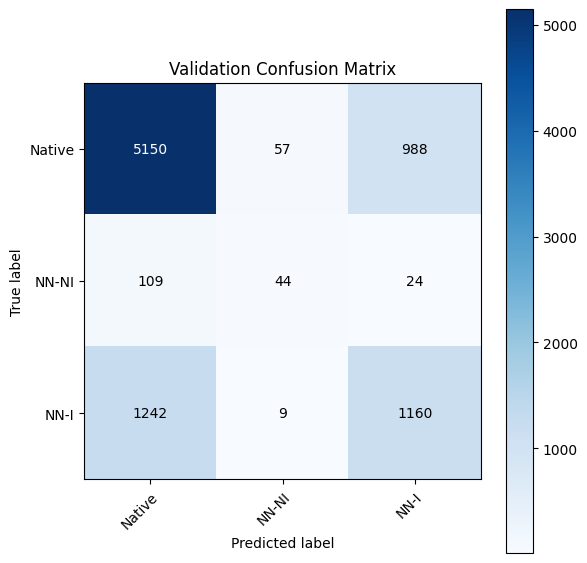


🔁 Epoch 30/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1012.71it/s]


📉 Train Loss: 0.4578 | Accuracy: 0.8139
📈 Val Loss:   0.5984 | Accuracy: 0.7302

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.77      0.88      0.82      6195
NN Non-Invasive       0.38      0.34      0.36       177
    NN Invasive       0.57      0.38      0.46      2411

       accuracy                           0.73      8783
      macro avg       0.58      0.53      0.55      8783
   weighted avg       0.71      0.73      0.71      8783



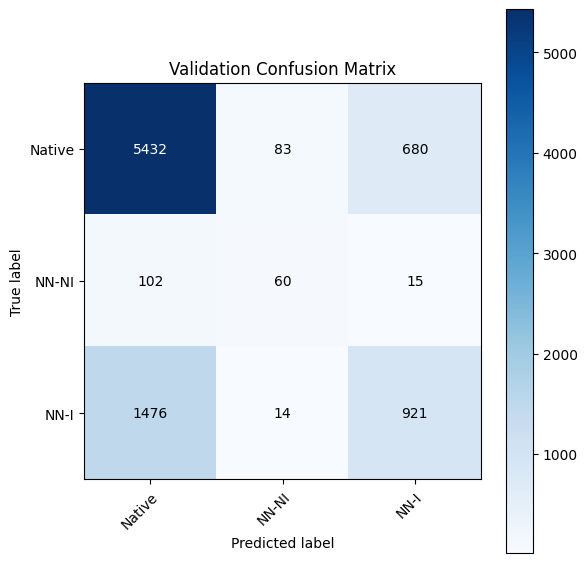


🔁 Epoch 31/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 811.80it/s]


📉 Train Loss: 0.4518 | Accuracy: 0.8161
📈 Val Loss:   0.6029 | Accuracy: 0.7230

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.78      0.85      0.81      6195
NN Non-Invasive       0.35      0.37      0.36       177
    NN Invasive       0.55      0.43      0.48      2411

       accuracy                           0.72      8783
      macro avg       0.56      0.55      0.55      8783
   weighted avg       0.71      0.72      0.71      8783



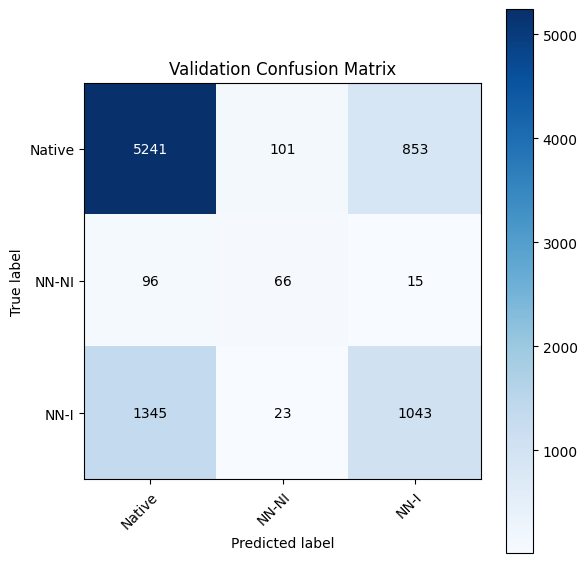


🔁 Epoch 32/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1014.81it/s]


📉 Train Loss: 0.4432 | Accuracy: 0.8206
📈 Val Loss:   0.6033 | Accuracy: 0.7289

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.78      0.86      0.82      6195
NN Non-Invasive       0.38      0.41      0.39       177
    NN Invasive       0.56      0.41      0.47      2411

       accuracy                           0.73      8783
      macro avg       0.57      0.56      0.56      8783
   weighted avg       0.71      0.73      0.72      8783



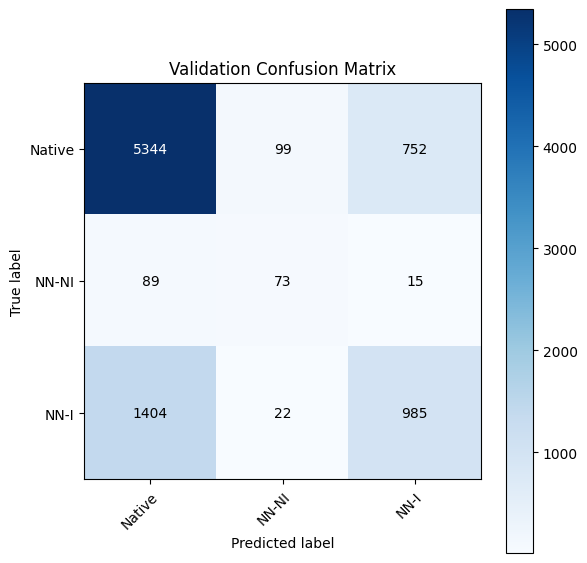

Stopping early as no improvement has been observed.
Early stopping at epoch 31
📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


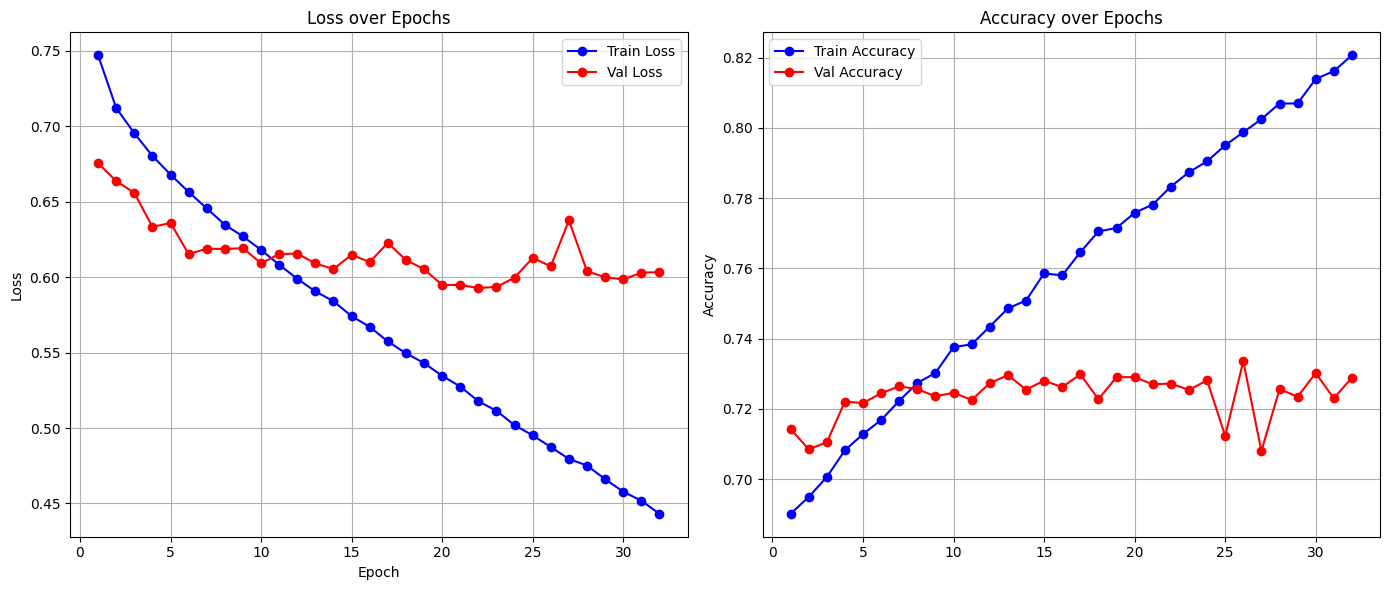

Full model built...
Total execution time: 104.74 seconds


In [60]:
model_name = "epochs_50_augmented"
embeddings_save_path = '/content/drive/MyDrive/Thesis/resnet_embeddings.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=False, augmentation=True, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path, debug_subset_size=None)

Using device: cuda
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 29/29 [00:14<00:00,  2.02it/s]


Augmenting train dataset...
🔢 Class distribution in train set: Counter({0: 24736, 2: 9662, 1: 1636})
⚖️ Class weights: tensor([0.0989, 0.1351, 0.1090])

🔁 Epoch 1/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1067.83it/s]


📉 Train Loss: 0.7366 | Accuracy: 0.6901
📈 Val Loss:   0.5783 | Accuracy: 0.7433

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.78      0.89      0.83      6220
NN Non-Invasive       0.33      0.01      0.01       172
    NN Invasive       0.59      0.41      0.48      2391

       accuracy                           0.74      8783
      macro avg       0.57      0.44      0.44      8783
   weighted avg       0.72      0.74      0.72      8783



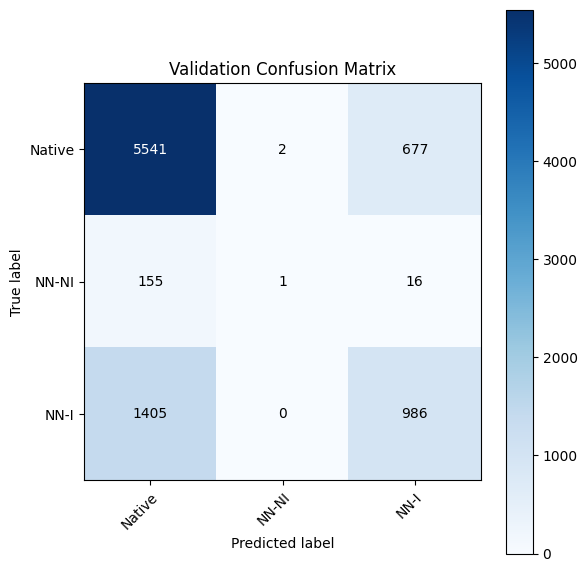


🔁 Epoch 2/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 975.85it/s] 


📉 Train Loss: 0.6031 | Accuracy: 0.7293
📈 Val Loss:   0.5382 | Accuracy: 0.7538

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.80      0.88      0.84      6220
NN Non-Invasive       0.21      0.08      0.12       172
    NN Invasive       0.61      0.49      0.54      2391

       accuracy                           0.75      8783
      macro avg       0.54      0.48      0.50      8783
   weighted avg       0.74      0.75      0.74      8783



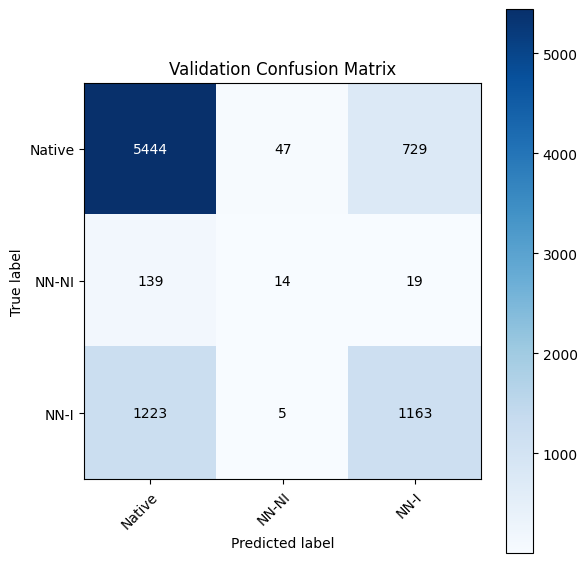


🔁 Epoch 3/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1067.13it/s]


📉 Train Loss: 0.5620 | Accuracy: 0.7450
📈 Val Loss:   0.5140 | Accuracy: 0.7655

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.82      0.87      0.84      6220
NN Non-Invasive       0.34      0.20      0.25       172
    NN Invasive       0.63      0.53      0.58      2391

       accuracy                           0.77      8783
      macro avg       0.59      0.54      0.56      8783
   weighted avg       0.75      0.77      0.76      8783



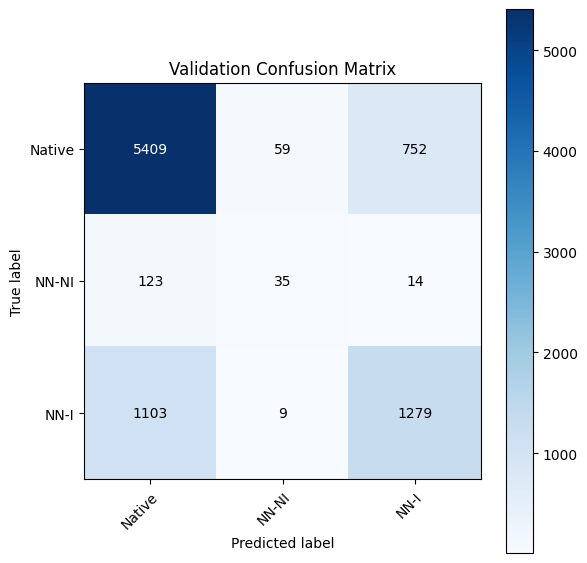


🔁 Epoch 4/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1061.07it/s]


📉 Train Loss: 0.5381 | Accuracy: 0.7572
📈 Val Loss:   0.4970 | Accuracy: 0.7705

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.82      0.86      0.84      6220
NN Non-Invasive       0.37      0.24      0.29       172
    NN Invasive       0.63      0.57      0.60      2391

       accuracy                           0.77      8783
      macro avg       0.61      0.56      0.58      8783
   weighted avg       0.76      0.77      0.77      8783



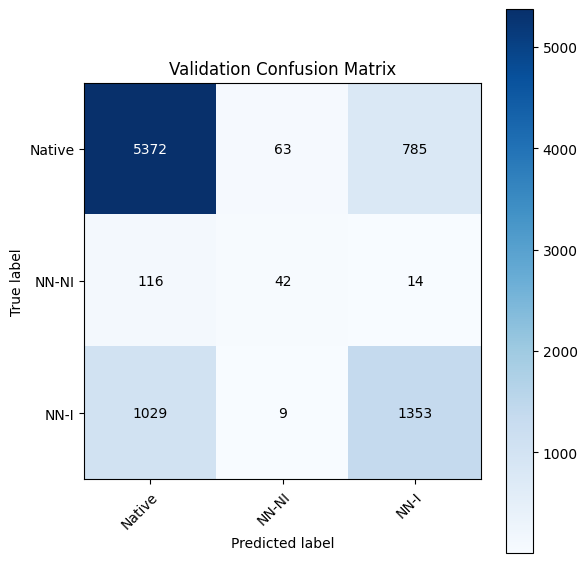


🔁 Epoch 5/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1108.72it/s]


📉 Train Loss: 0.5215 | Accuracy: 0.7636
📈 Val Loss:   0.4866 | Accuracy: 0.7780

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.86      0.85      6220
NN Non-Invasive       0.38      0.29      0.33       172
    NN Invasive       0.64      0.60      0.62      2391

       accuracy                           0.78      8783
      macro avg       0.62      0.58      0.60      8783
   weighted avg       0.77      0.78      0.77      8783



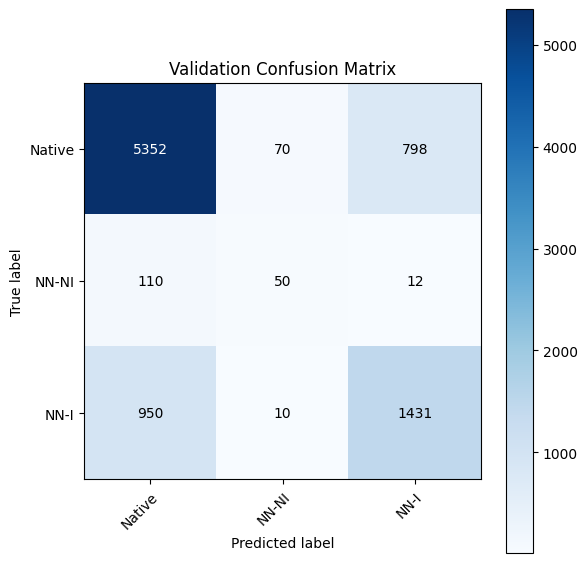


🔁 Epoch 6/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1095.70it/s]


📉 Train Loss: 0.5087 | Accuracy: 0.7693
📈 Val Loss:   0.4767 | Accuracy: 0.7808

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.86      0.85      6220
NN Non-Invasive       0.40      0.30      0.34       172
    NN Invasive       0.64      0.61      0.62      2391

       accuracy                           0.78      8783
      macro avg       0.63      0.59      0.60      8783
   weighted avg       0.78      0.78      0.78      8783



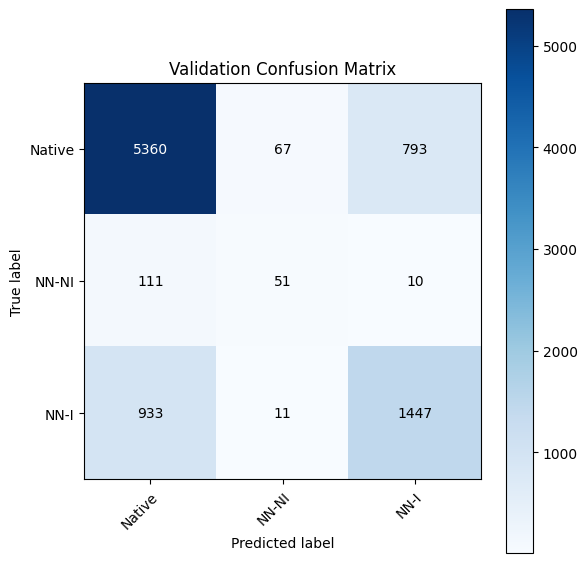


🔁 Epoch 7/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 770.26it/s]


📉 Train Loss: 0.4987 | Accuracy: 0.7734
📈 Val Loss:   0.4706 | Accuracy: 0.7832

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.86      0.85      6220
NN Non-Invasive       0.39      0.33      0.36       172
    NN Invasive       0.65      0.62      0.63      2391

       accuracy                           0.78      8783
      macro avg       0.63      0.60      0.61      8783
   weighted avg       0.78      0.78      0.78      8783



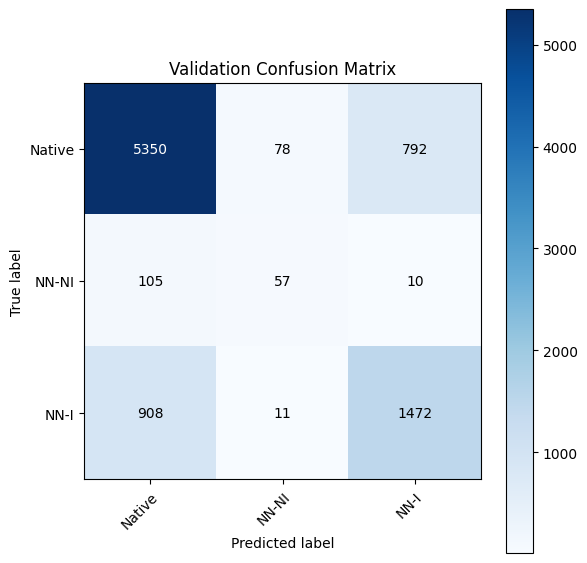


🔁 Epoch 8/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 990.67it/s]


📉 Train Loss: 0.4900 | Accuracy: 0.7776
📈 Val Loss:   0.4670 | Accuracy: 0.7850

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.85      0.85      6220
NN Non-Invasive       0.39      0.38      0.39       172
    NN Invasive       0.65      0.64      0.64      2391

       accuracy                           0.79      8783
      macro avg       0.63      0.63      0.63      8783
   weighted avg       0.78      0.79      0.78      8783



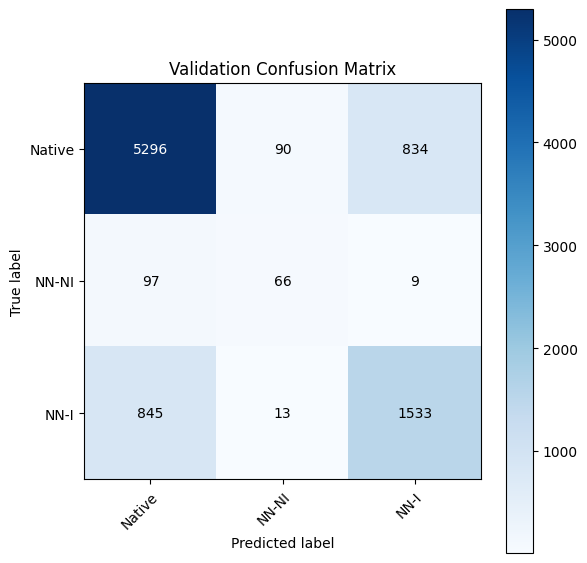


🔁 Epoch 9/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1066.75it/s]


📉 Train Loss: 0.4826 | Accuracy: 0.7809
📈 Val Loss:   0.4642 | Accuracy: 0.7869

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.85      0.85      6220
NN Non-Invasive       0.37      0.40      0.38       172
    NN Invasive       0.65      0.66      0.65      2391

       accuracy                           0.79      8783
      macro avg       0.62      0.63      0.63      8783
   weighted avg       0.79      0.79      0.79      8783



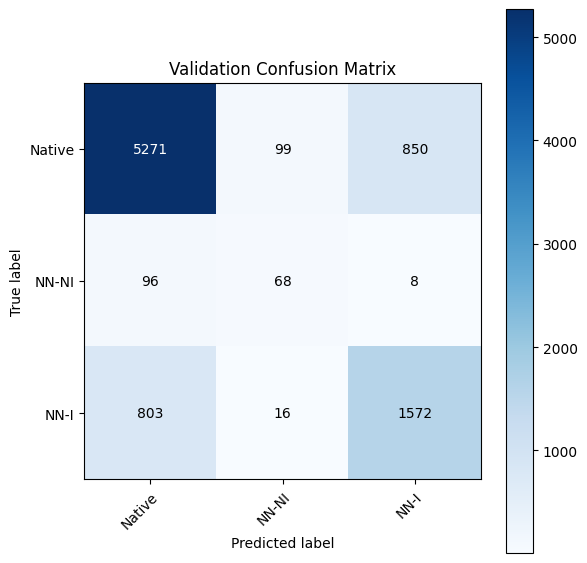


🔁 Epoch 10/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1096.06it/s]


📉 Train Loss: 0.4760 | Accuracy: 0.7841
📈 Val Loss:   0.4574 | Accuracy: 0.7918

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.87      0.86      6220
NN Non-Invasive       0.40      0.38      0.39       172
    NN Invasive       0.67      0.61      0.64      2391

       accuracy                           0.79      8783
      macro avg       0.64      0.62      0.63      8783
   weighted avg       0.79      0.79      0.79      8783



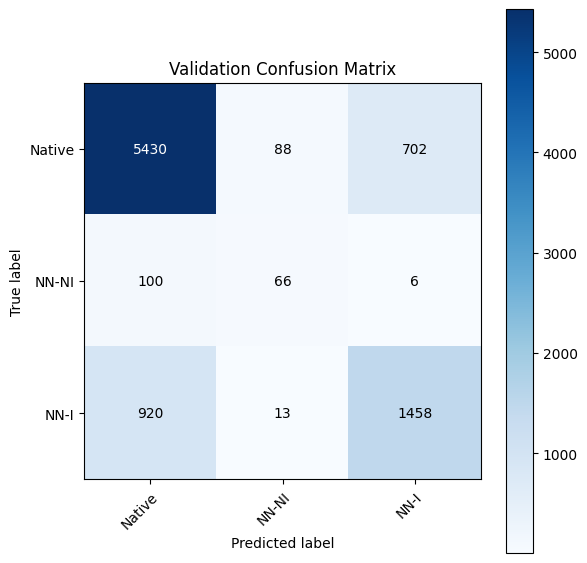


🔁 Epoch 11/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1084.20it/s]


📉 Train Loss: 0.4707 | Accuracy: 0.7869
📈 Val Loss:   0.4533 | Accuracy: 0.7932

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.86      0.86      6220
NN Non-Invasive       0.41      0.40      0.40       172
    NN Invasive       0.67      0.63      0.65      2391

       accuracy                           0.79      8783
      macro avg       0.64      0.63      0.64      8783
   weighted avg       0.79      0.79      0.79      8783



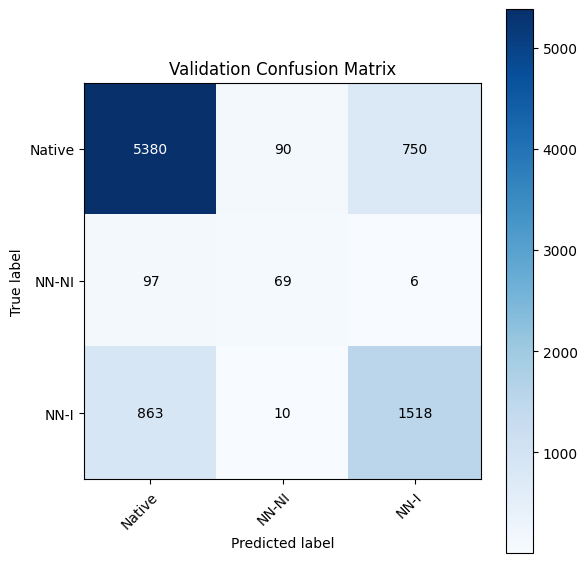


🔁 Epoch 12/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 803.00it/s]


📉 Train Loss: 0.4651 | Accuracy: 0.7874
📈 Val Loss:   0.4536 | Accuracy: 0.7908

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.87      0.86      6220
NN Non-Invasive       0.40      0.41      0.40       172
    NN Invasive       0.67      0.62      0.64      2391

       accuracy                           0.79      8783
      macro avg       0.64      0.63      0.63      8783
   weighted avg       0.79      0.79      0.79      8783



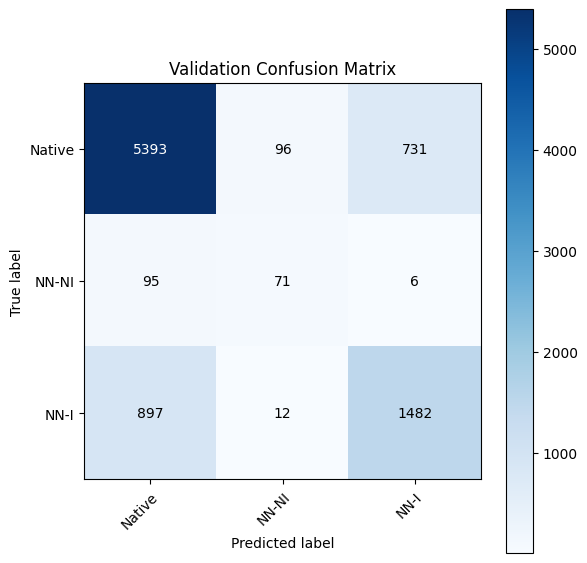


🔁 Epoch 13/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1085.32it/s]


📉 Train Loss: 0.4605 | Accuracy: 0.7911
📈 Val Loss:   0.4469 | Accuracy: 0.7962

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.87      0.86      6220
NN Non-Invasive       0.43      0.41      0.42       172
    NN Invasive       0.68      0.62      0.65      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.64      0.64      8783
   weighted avg       0.79      0.80      0.79      8783



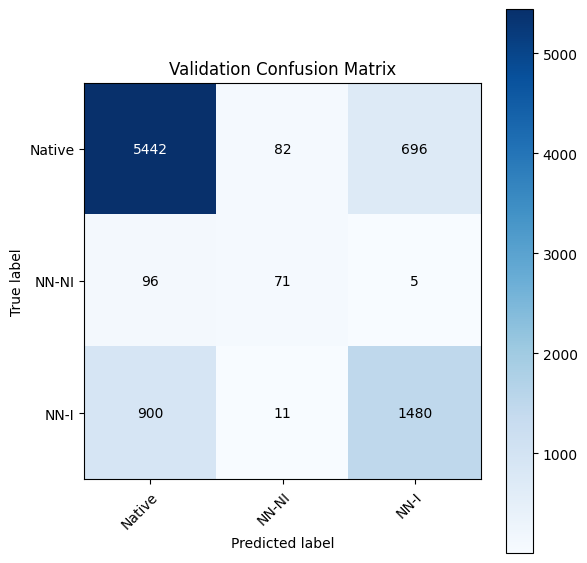


🔁 Epoch 14/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1050.50it/s]


📉 Train Loss: 0.4558 | Accuracy: 0.7939
📈 Val Loss:   0.4452 | Accuracy: 0.7987

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.88      0.86      6220
NN Non-Invasive       0.43      0.42      0.43       172
    NN Invasive       0.69      0.61      0.65      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.64      0.65      8783
   weighted avg       0.79      0.80      0.80      8783



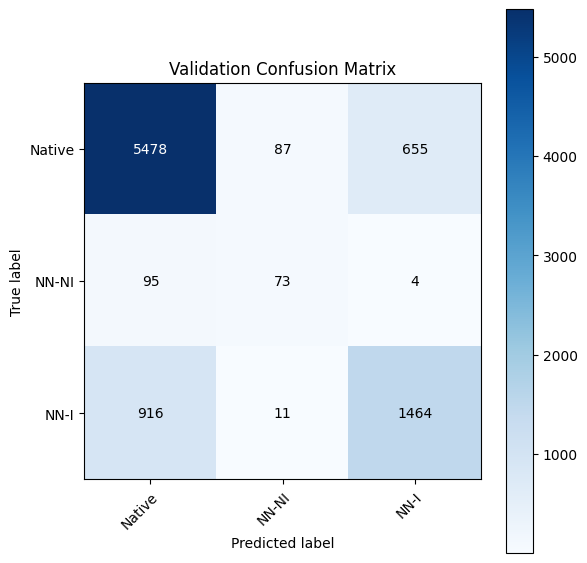


🔁 Epoch 15/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1074.78it/s]


📉 Train Loss: 0.4516 | Accuracy: 0.7961
📈 Val Loss:   0.4434 | Accuracy: 0.7984

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.88      0.86      6220
NN Non-Invasive       0.44      0.43      0.44       172
    NN Invasive       0.68      0.62      0.65      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.64      0.65      8783
   weighted avg       0.79      0.80      0.80      8783



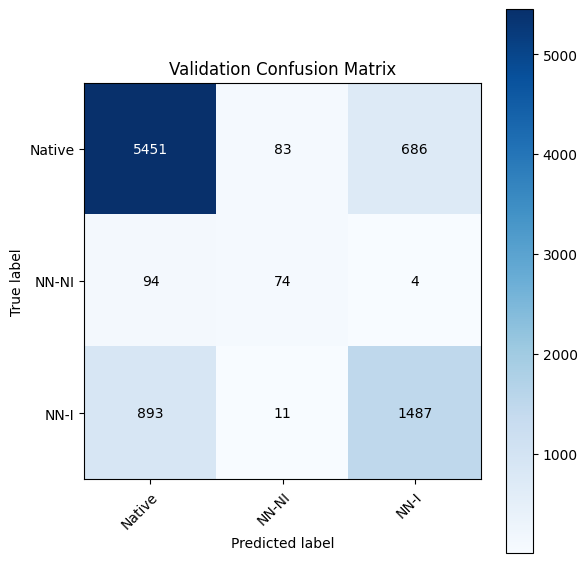


🔁 Epoch 16/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1074.45it/s]


📉 Train Loss: 0.4478 | Accuracy: 0.7988
📈 Val Loss:   0.4434 | Accuracy: 0.7980

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.87      0.86      6220
NN Non-Invasive       0.41      0.47      0.43       172
    NN Invasive       0.68      0.63      0.66      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.66      0.65      8783
   weighted avg       0.80      0.80      0.80      8783



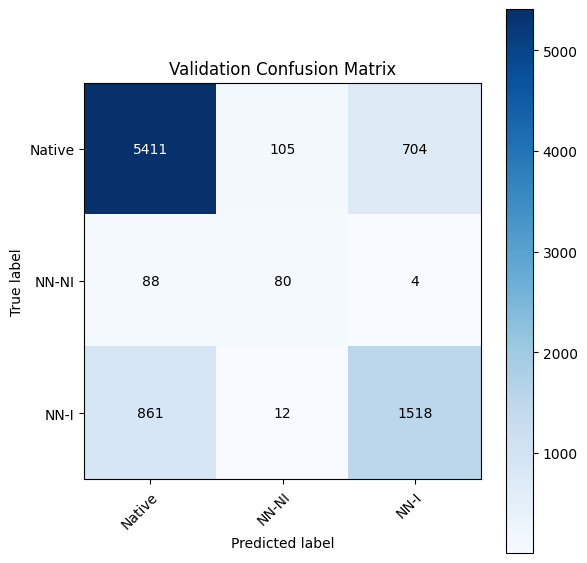


🔁 Epoch 17/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 710.35it/s]


📉 Train Loss: 0.4439 | Accuracy: 0.8015
📈 Val Loss:   0.4389 | Accuracy: 0.8017

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.87      0.86      6220
NN Non-Invasive       0.43      0.45      0.44       172
    NN Invasive       0.69      0.64      0.66      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.66      0.66      8783
   weighted avg       0.80      0.80      0.80      8783



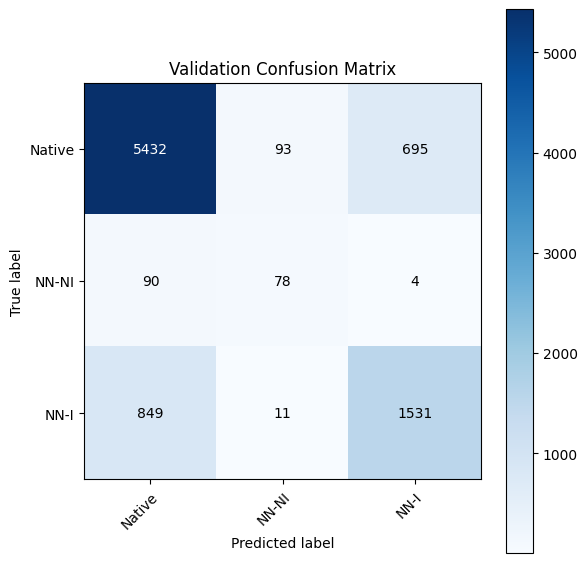


🔁 Epoch 18/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1004.38it/s]


📉 Train Loss: 0.4405 | Accuracy: 0.8034
📈 Val Loss:   0.4429 | Accuracy: 0.7957

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.87      0.86      6220
NN Non-Invasive       0.41      0.51      0.45       172
    NN Invasive       0.68      0.62      0.65      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.67      0.65      8783
   weighted avg       0.79      0.80      0.79      8783



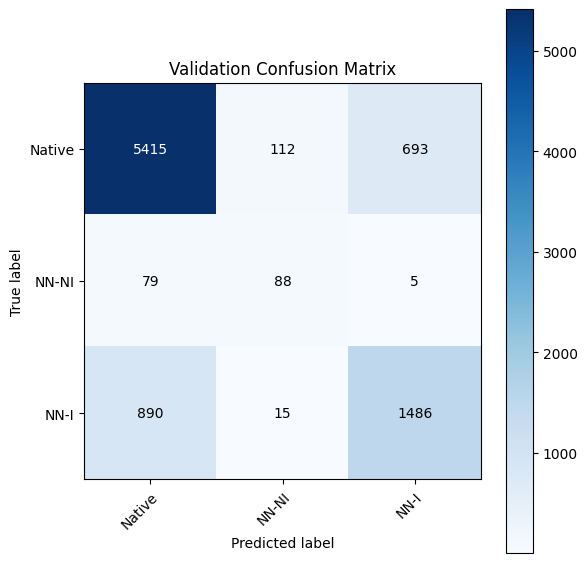


🔁 Epoch 19/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1084.02it/s]


📉 Train Loss: 0.4369 | Accuracy: 0.8052
📈 Val Loss:   0.4410 | Accuracy: 0.8002

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.88      0.86      6220
NN Non-Invasive       0.40      0.52      0.46       172
    NN Invasive       0.70      0.60      0.65      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.67      0.66      8783
   weighted avg       0.80      0.80      0.80      8783



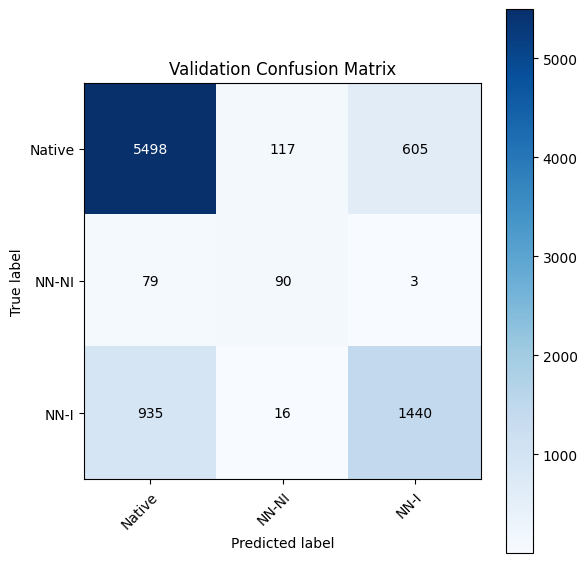


🔁 Epoch 20/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1047.90it/s]


📉 Train Loss: 0.4340 | Accuracy: 0.8061
📈 Val Loss:   0.4331 | Accuracy: 0.8021

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.88      0.86      6220
NN Non-Invasive       0.45      0.48      0.47       172
    NN Invasive       0.69      0.63      0.66      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.66      0.66      8783
   weighted avg       0.80      0.80      0.80      8783



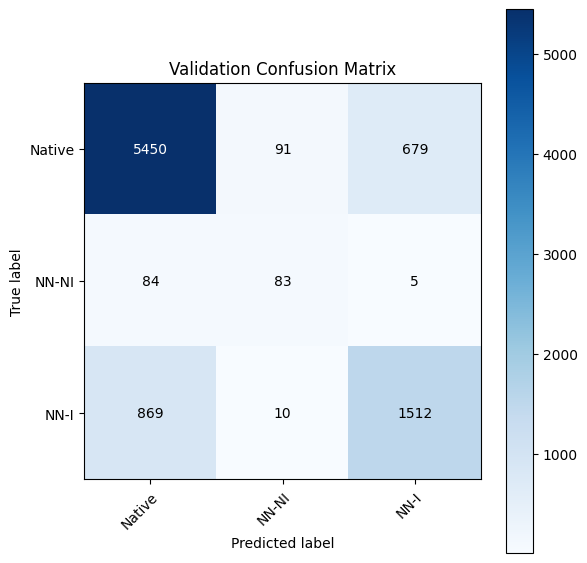


🔁 Epoch 21/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 742.14it/s]


📉 Train Loss: 0.4307 | Accuracy: 0.8087
📈 Val Loss:   0.4344 | Accuracy: 0.8009

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.86      0.86      6220
NN Non-Invasive       0.44      0.51      0.47       172
    NN Invasive       0.67      0.66      0.67      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.80      0.80      0.80      8783



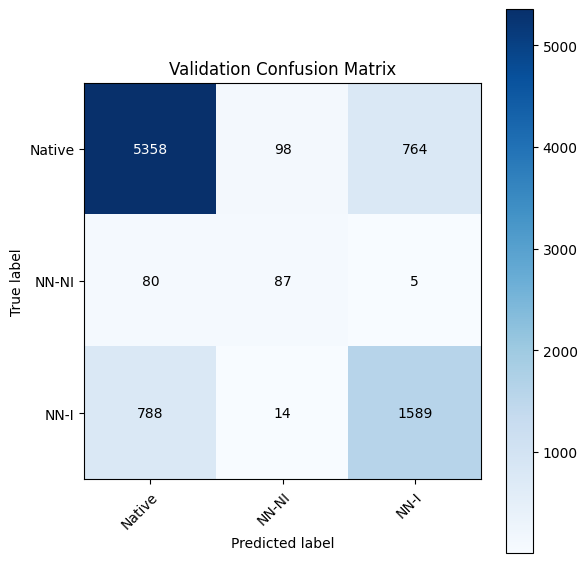


🔁 Epoch 22/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1039.81it/s]


📉 Train Loss: 0.4273 | Accuracy: 0.8099
📈 Val Loss:   0.4338 | Accuracy: 0.8008

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.87      0.86      6220
NN Non-Invasive       0.43      0.51      0.47       172
    NN Invasive       0.68      0.64      0.66      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.67      0.66      8783
   weighted avg       0.80      0.80      0.80      8783



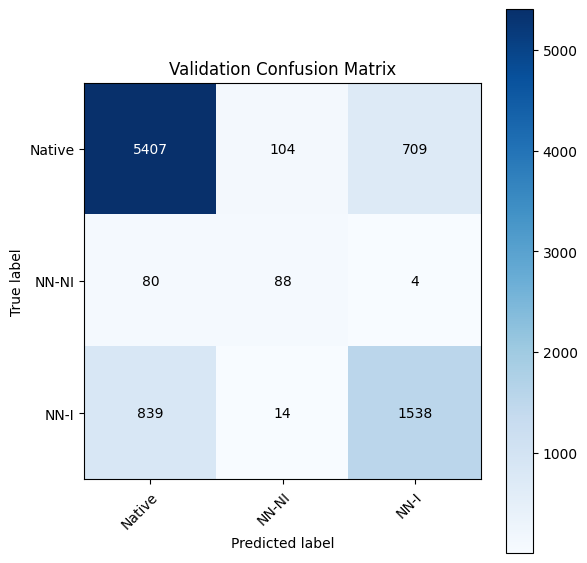


🔁 Epoch 23/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 984.95it/s] 


📉 Train Loss: 0.4246 | Accuracy: 0.8110
📈 Val Loss:   0.4309 | Accuracy: 0.8027

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.86      6220
NN Non-Invasive       0.45      0.50      0.47       172
    NN Invasive       0.68      0.66      0.67      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.80      0.80      0.80      8783



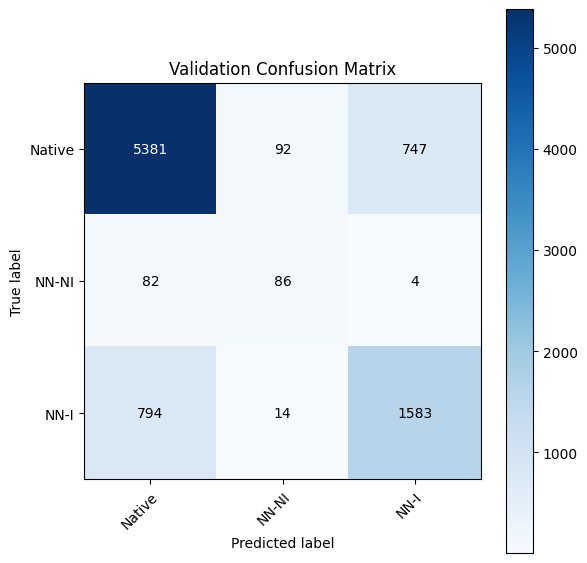


🔁 Epoch 24/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 995.56it/s] 


📉 Train Loss: 0.4217 | Accuracy: 0.8123
📈 Val Loss:   0.4296 | Accuracy: 0.8033

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.88      0.87      6220
NN Non-Invasive       0.46      0.50      0.48       172
    NN Invasive       0.70      0.62      0.65      2391

       accuracy                           0.80      8783
      macro avg       0.67      0.67      0.67      8783
   weighted avg       0.80      0.80      0.80      8783



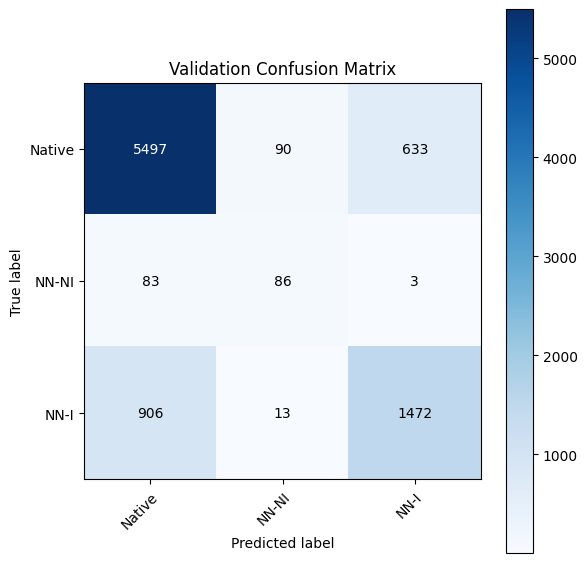


🔁 Epoch 25/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 752.30it/s]


📉 Train Loss: 0.4188 | Accuracy: 0.8140
📈 Val Loss:   0.4281 | Accuracy: 0.8058

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.87      6220
NN Non-Invasive       0.44      0.52      0.48       172
    NN Invasive       0.69      0.65      0.67      2391

       accuracy                           0.81      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.80      0.81      0.80      8783



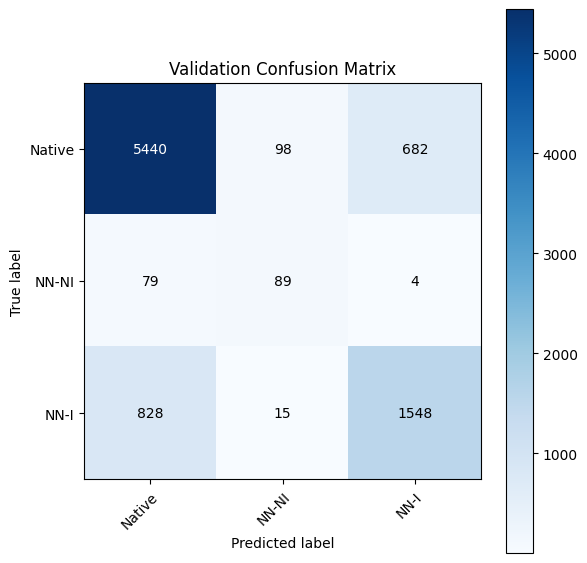


🔁 Epoch 26/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1042.02it/s]


📉 Train Loss: 0.4163 | Accuracy: 0.8156
📈 Val Loss:   0.4302 | Accuracy: 0.8028

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.86      6220
NN Non-Invasive       0.43      0.53      0.47       172
    NN Invasive       0.68      0.65      0.67      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.80      0.80      0.80      8783



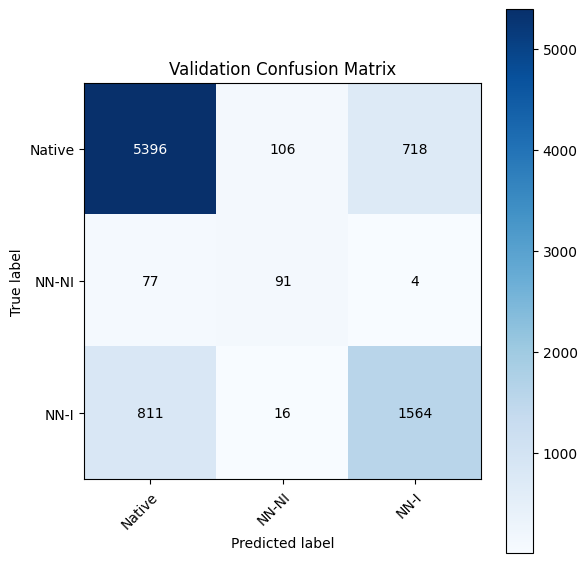


🔁 Epoch 27/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1028.52it/s]


📉 Train Loss: 0.4135 | Accuracy: 0.8170
📈 Val Loss:   0.4279 | Accuracy: 0.8033

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.86      6220
NN Non-Invasive       0.43      0.52      0.47       172
    NN Invasive       0.67      0.69      0.68      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.69      0.67      8783
   weighted avg       0.81      0.80      0.80      8783



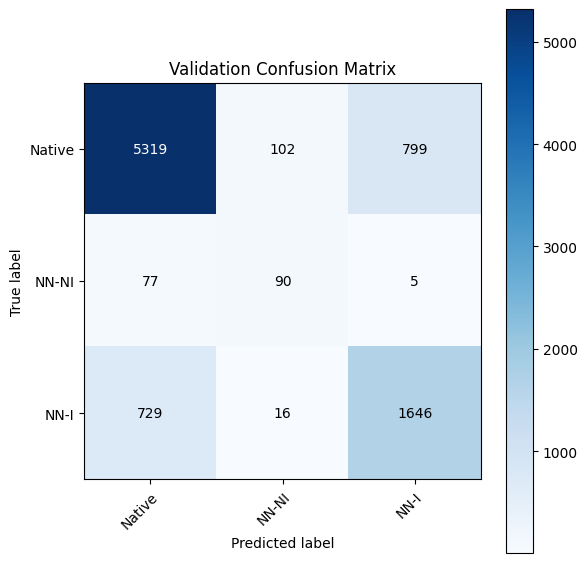


🔁 Epoch 28/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 966.34it/s]


📉 Train Loss: 0.4111 | Accuracy: 0.8167
📈 Val Loss:   0.4253 | Accuracy: 0.8037

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.88      0.86      6220
NN Non-Invasive       0.44      0.52      0.48       172
    NN Invasive       0.69      0.63      0.66      2391

       accuracy                           0.80      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.80      0.80      0.80      8783



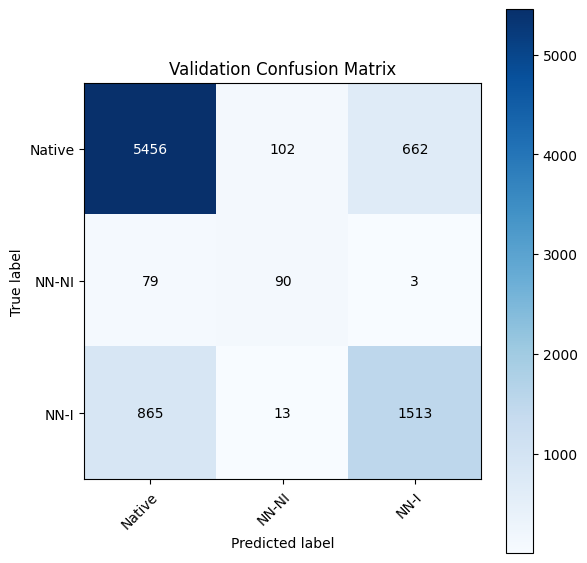


🔁 Epoch 29/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1050.57it/s]


📉 Train Loss: 0.4083 | Accuracy: 0.8186
📈 Val Loss:   0.4223 | Accuracy: 0.8055

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.86      6220
NN Non-Invasive       0.44      0.50      0.47       172
    NN Invasive       0.68      0.67      0.68      2391

       accuracy                           0.81      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.81      0.81      0.81      8783



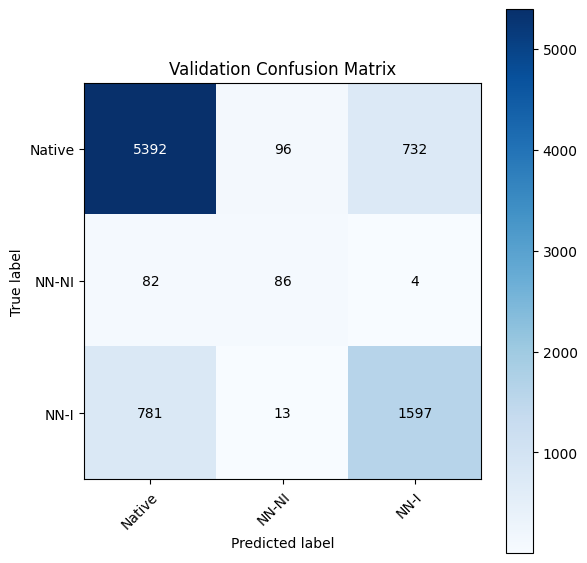


🔁 Epoch 30/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 732.95it/s]


📉 Train Loss: 0.4057 | Accuracy: 0.8213
📈 Val Loss:   0.4207 | Accuracy: 0.8068

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.86      6220
NN Non-Invasive       0.46      0.49      0.48       172
    NN Invasive       0.68      0.68      0.68      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.68      0.67      8783
   weighted avg       0.81      0.81      0.81      8783



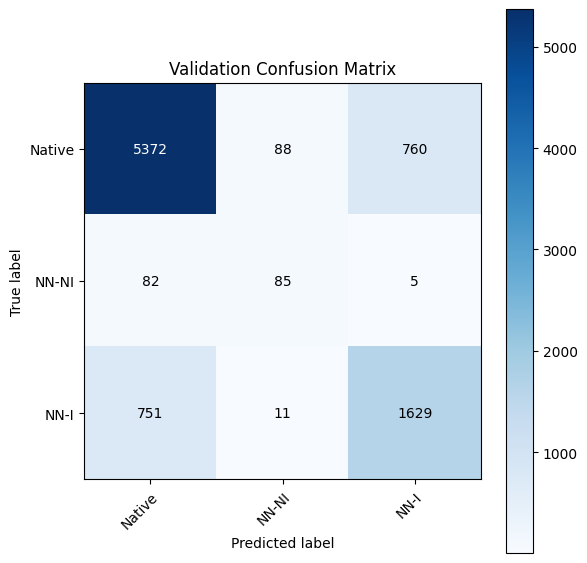


🔁 Epoch 31/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 983.22it/s] 


📉 Train Loss: 0.4031 | Accuracy: 0.8224
📈 Val Loss:   0.4239 | Accuracy: 0.8045

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.86      6220
NN Non-Invasive       0.40      0.54      0.46       172
    NN Invasive       0.69      0.65      0.67      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.69      0.67      8783
   weighted avg       0.81      0.80      0.80      8783



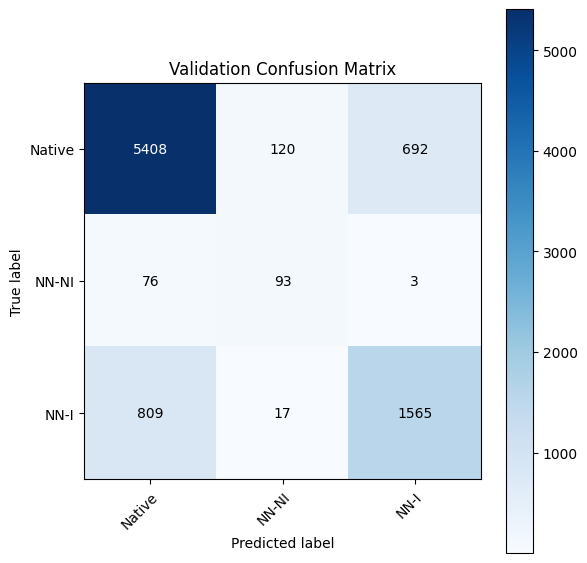


🔁 Epoch 32/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 993.29it/s]


📉 Train Loss: 0.4007 | Accuracy: 0.8240
📈 Val Loss:   0.4246 | Accuracy: 0.8028

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.87      0.86      6220
NN Non-Invasive       0.41      0.55      0.47       172
    NN Invasive       0.69      0.64      0.67      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.69      0.67      8783
   weighted avg       0.80      0.80      0.80      8783



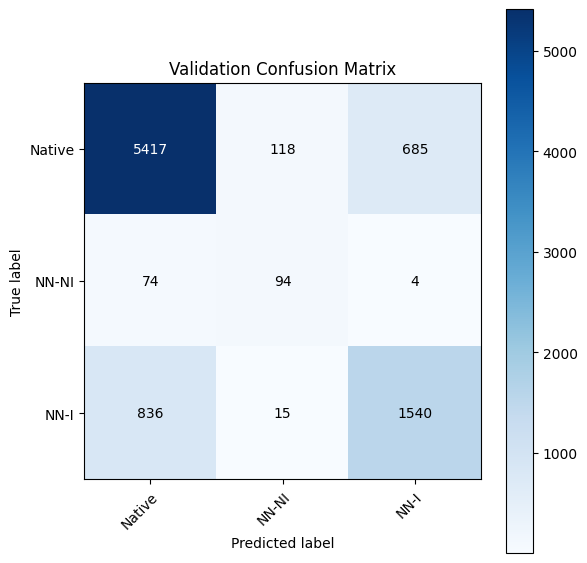


🔁 Epoch 33/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1000.05it/s]


📉 Train Loss: 0.3985 | Accuracy: 0.8237
📈 Val Loss:   0.4208 | Accuracy: 0.8083

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.88      0.87      6220
NN Non-Invasive       0.43      0.53      0.47       172
    NN Invasive       0.71      0.63      0.67      2391

       accuracy                           0.81      8783
      macro avg       0.66      0.68      0.67      8783
   weighted avg       0.81      0.81      0.81      8783



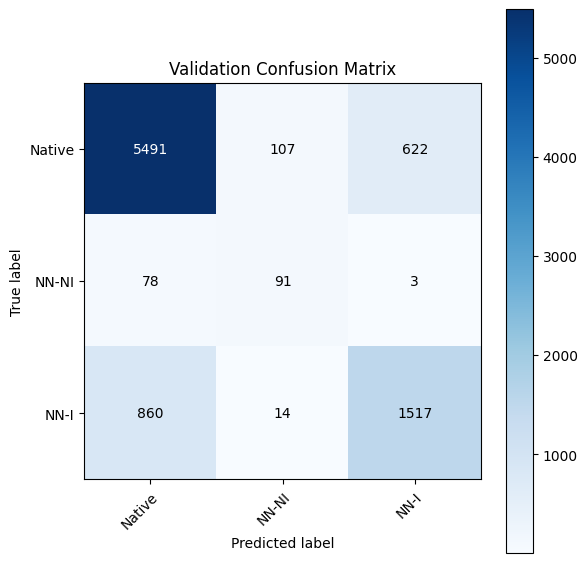


🔁 Epoch 34/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1011.40it/s]


📉 Train Loss: 0.3956 | Accuracy: 0.8263
📈 Val Loss:   0.4181 | Accuracy: 0.8084

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.88      0.87      6220
NN Non-Invasive       0.45      0.51      0.48       172
    NN Invasive       0.70      0.64      0.67      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.68      0.67      8783
   weighted avg       0.81      0.81      0.81      8783



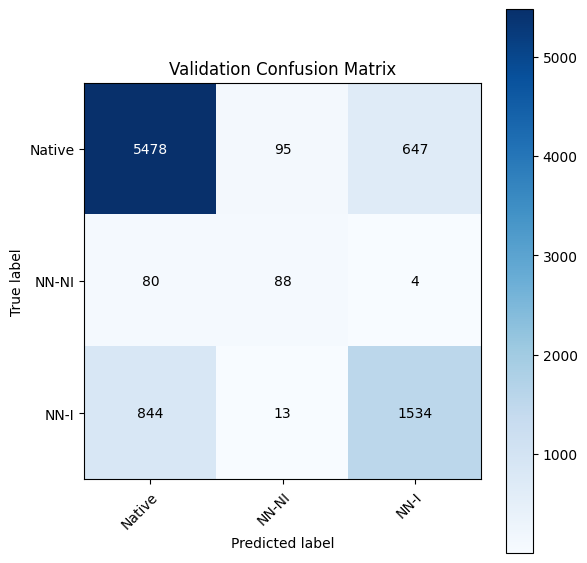


🔁 Epoch 35/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 656.37it/s]


📉 Train Loss: 0.3935 | Accuracy: 0.8255
📈 Val Loss:   0.4188 | Accuracy: 0.8103

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.88      0.87      6220
NN Non-Invasive       0.43      0.53      0.48       172
    NN Invasive       0.71      0.65      0.68      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.69      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



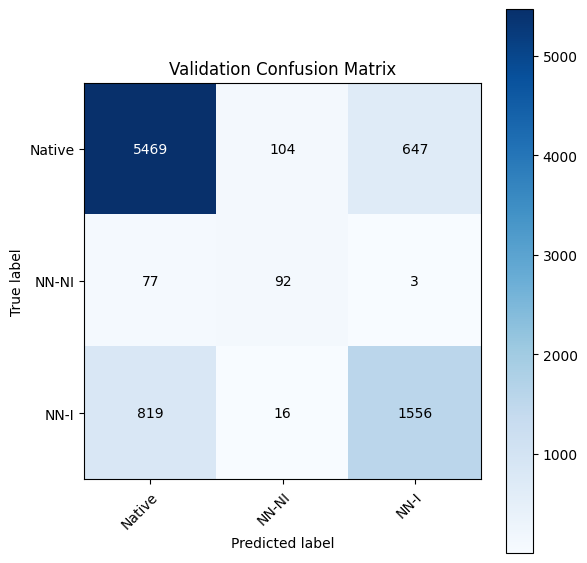


🔁 Epoch 36/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1006.50it/s]


📉 Train Loss: 0.3907 | Accuracy: 0.8278
📈 Val Loss:   0.4238 | Accuracy: 0.8036

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.85      0.86      6220
NN Non-Invasive       0.39      0.58      0.47       172
    NN Invasive       0.68      0.70      0.69      2391

       accuracy                           0.80      8783
      macro avg       0.65      0.71      0.67      8783
   weighted avg       0.81      0.80      0.81      8783



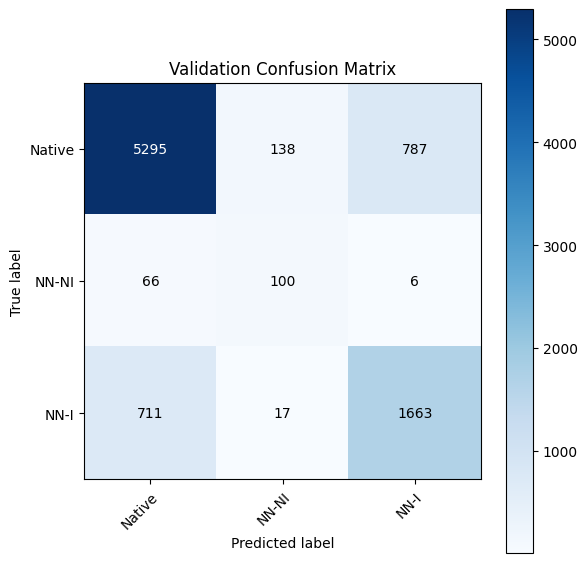


🔁 Epoch 37/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 966.07it/s]


📉 Train Loss: 0.3885 | Accuracy: 0.8295
📈 Val Loss:   0.4189 | Accuracy: 0.8064

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.85      0.86      6220
NN Non-Invasive       0.42      0.56      0.48       172
    NN Invasive       0.68      0.70      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.66      0.70      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



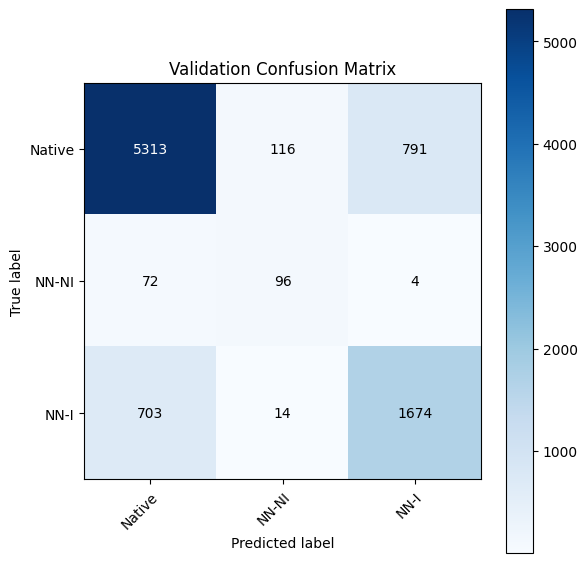


🔁 Epoch 38/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1009.68it/s]


📉 Train Loss: 0.3862 | Accuracy: 0.8314
📈 Val Loss:   0.4140 | Accuracy: 0.8092

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.87      0.87      6220
NN Non-Invasive       0.45      0.53      0.49       172
    NN Invasive       0.69      0.68      0.68      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.69      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



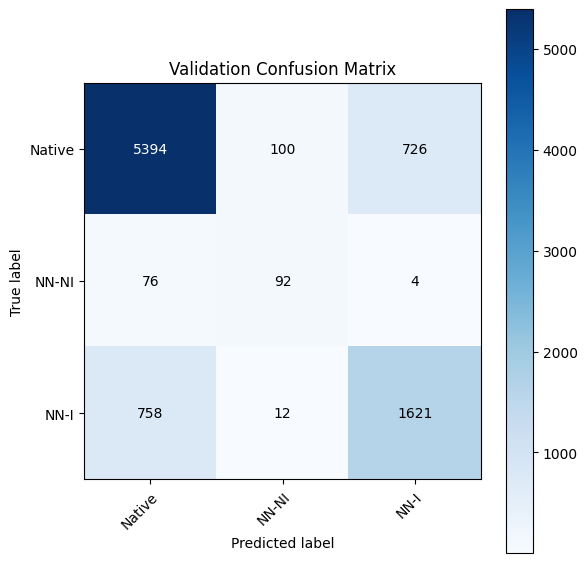


🔁 Epoch 39/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 817.21it/s]


📉 Train Loss: 0.3840 | Accuracy: 0.8314
📈 Val Loss:   0.4159 | Accuracy: 0.8064

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.85      0.86      6220
NN Non-Invasive       0.46      0.53      0.50       172
    NN Invasive       0.67      0.71      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.70      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



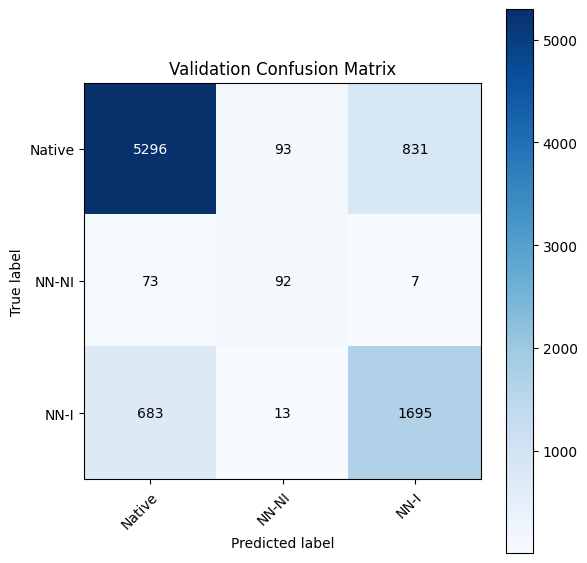


🔁 Epoch 40/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 999.02it/s] 


📉 Train Loss: 0.3815 | Accuracy: 0.8325
📈 Val Loss:   0.4123 | Accuracy: 0.8113

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.88      0.87      6220
NN Non-Invasive       0.46      0.54      0.50       172
    NN Invasive       0.70      0.66      0.68      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.69      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



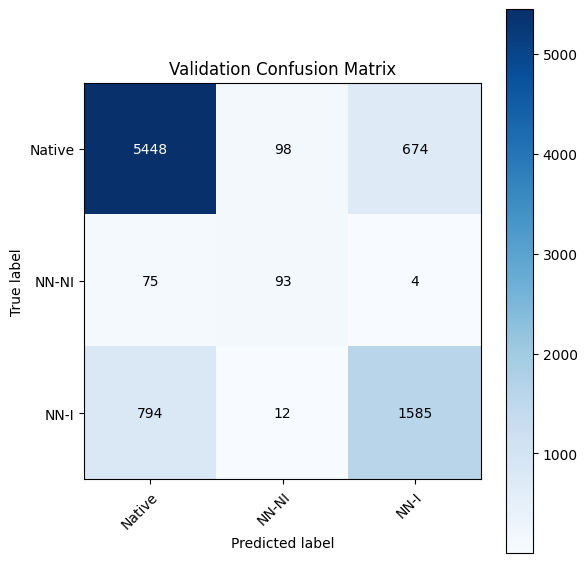


🔁 Epoch 41/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 983.59it/s]


📉 Train Loss: 0.3793 | Accuracy: 0.8327
📈 Val Loss:   0.4157 | Accuracy: 0.8064

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.85      0.86      6220
NN Non-Invasive       0.43      0.58      0.49       172
    NN Invasive       0.68      0.70      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.66      0.71      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



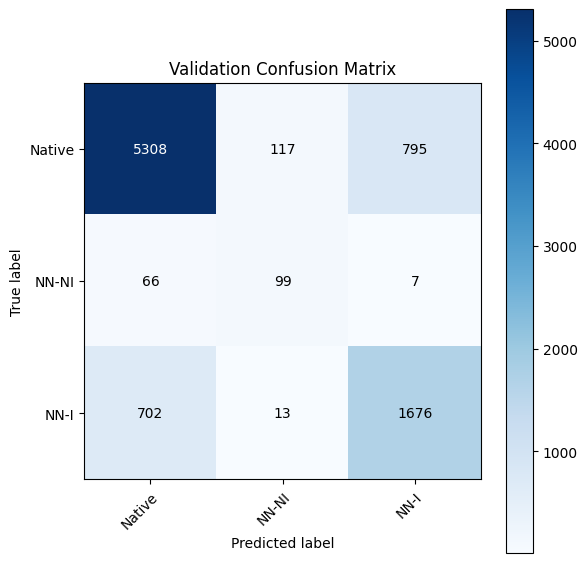


🔁 Epoch 42/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1003.09it/s]


📉 Train Loss: 0.3766 | Accuracy: 0.8363
📈 Val Loss:   0.4116 | Accuracy: 0.8124

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.88      0.87      6220
NN Non-Invasive       0.46      0.55      0.50       172
    NN Invasive       0.71      0.65      0.68      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.69      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



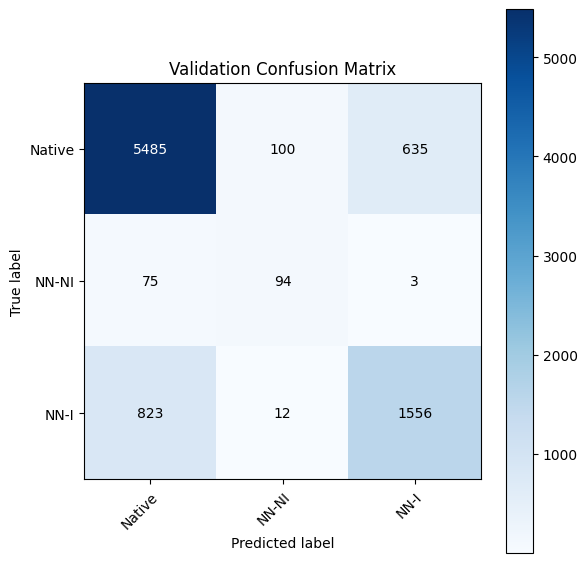


🔁 Epoch 43/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 996.12it/s] 


📉 Train Loss: 0.3745 | Accuracy: 0.8374
📈 Val Loss:   0.4128 | Accuracy: 0.8101

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.87      6220
NN Non-Invasive       0.44      0.58      0.50       172
    NN Invasive       0.69      0.69      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.71      0.69      8783
   weighted avg       0.81      0.81      0.81      8783



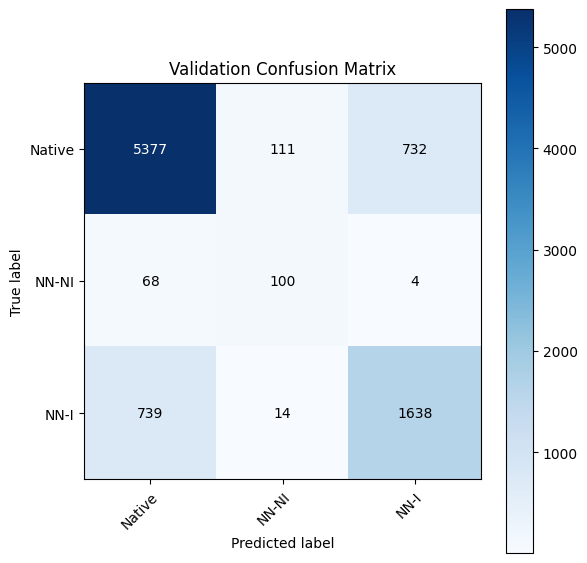


🔁 Epoch 44/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 659.09it/s]


📉 Train Loss: 0.3722 | Accuracy: 0.8378
📈 Val Loss:   0.4129 | Accuracy: 0.8109

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.89      0.87      6220
NN Non-Invasive       0.44      0.56      0.50       172
    NN Invasive       0.72      0.63      0.67      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.69      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



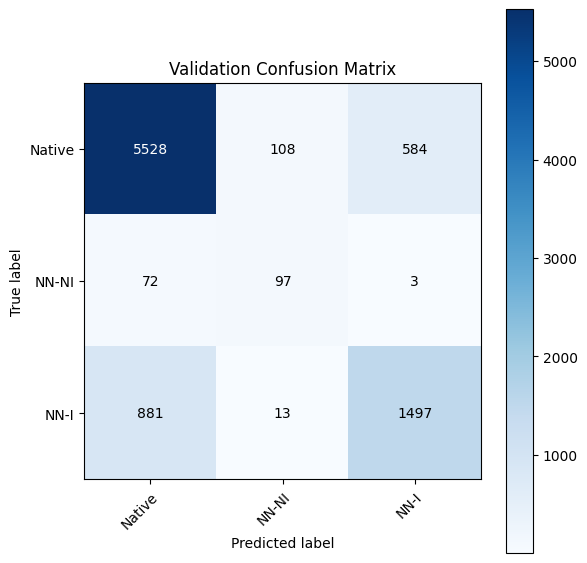


🔁 Epoch 45/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 931.06it/s]


📉 Train Loss: 0.3699 | Accuracy: 0.8377
📈 Val Loss:   0.4151 | Accuracy: 0.8067

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.85      0.86      6220
NN Non-Invasive       0.43      0.60      0.50       172
    NN Invasive       0.68      0.71      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.66      0.72      0.68      8783
   weighted avg       0.81      0.81      0.81      8783



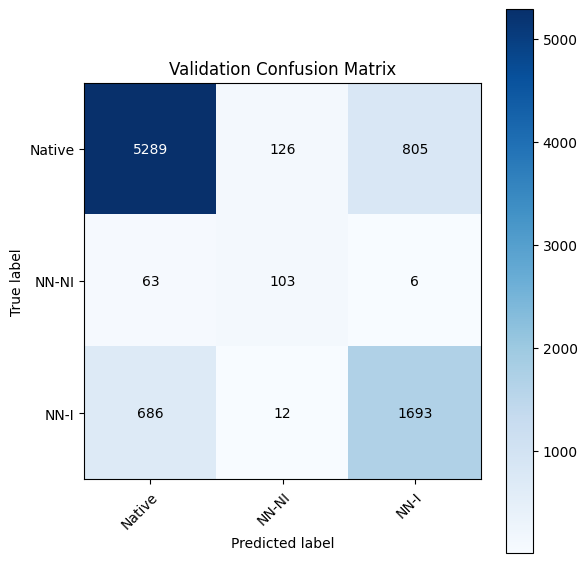


🔁 Epoch 46/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1001.42it/s]


📉 Train Loss: 0.3674 | Accuracy: 0.8407
📈 Val Loss:   0.4117 | Accuracy: 0.8094

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.87      6220
NN Non-Invasive       0.44      0.62      0.52       172
    NN Invasive       0.69      0.69      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.72      0.69      8783
   weighted avg       0.81      0.81      0.81      8783



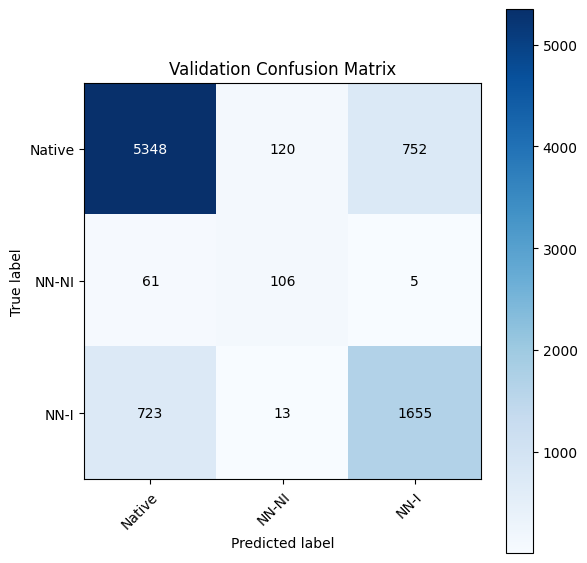


🔁 Epoch 47/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 994.75it/s]


📉 Train Loss: 0.3650 | Accuracy: 0.8422
📈 Val Loss:   0.4072 | Accuracy: 0.8133

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.87      0.87      6220
NN Non-Invasive       0.49      0.56      0.53       172
    NN Invasive       0.69      0.68      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.69      0.70      0.69      8783
   weighted avg       0.81      0.81      0.81      8783



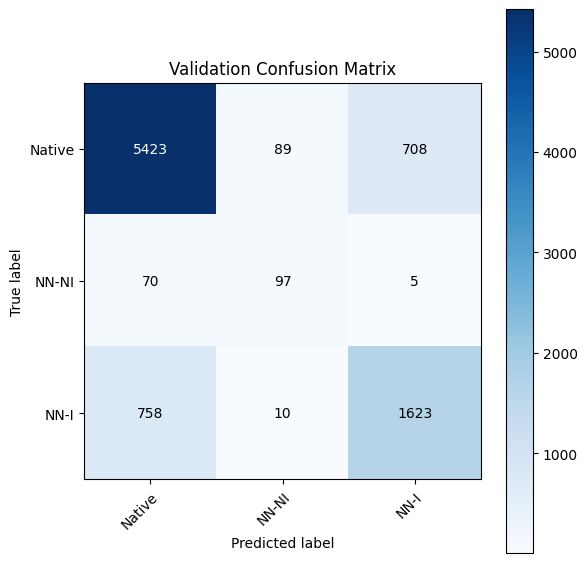


🔁 Epoch 48/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 950.33it/s]


📉 Train Loss: 0.3629 | Accuracy: 0.8418
📈 Val Loss:   0.4093 | Accuracy: 0.8127

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.87      0.87      6220
NN Non-Invasive       0.46      0.61      0.53       172
    NN Invasive       0.69      0.69      0.69      2391

       accuracy                           0.81      8783
      macro avg       0.68      0.72      0.70      8783
   weighted avg       0.82      0.81      0.81      8783



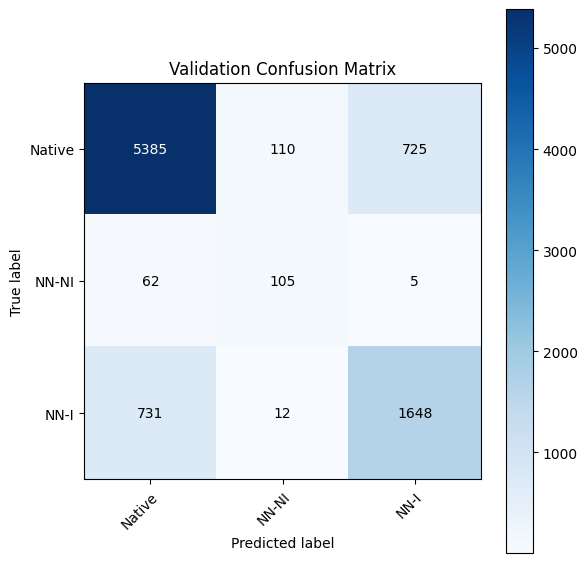


🔁 Epoch 49/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 722.22it/s]


📉 Train Loss: 0.3606 | Accuracy: 0.8446
📈 Val Loss:   0.4041 | Accuracy: 0.8166

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.87      0.87      6220
NN Non-Invasive       0.50      0.55      0.52       172
    NN Invasive       0.70      0.69      0.69      2391

       accuracy                           0.82      8783
      macro avg       0.69      0.70      0.70      8783
   weighted avg       0.82      0.82      0.82      8783



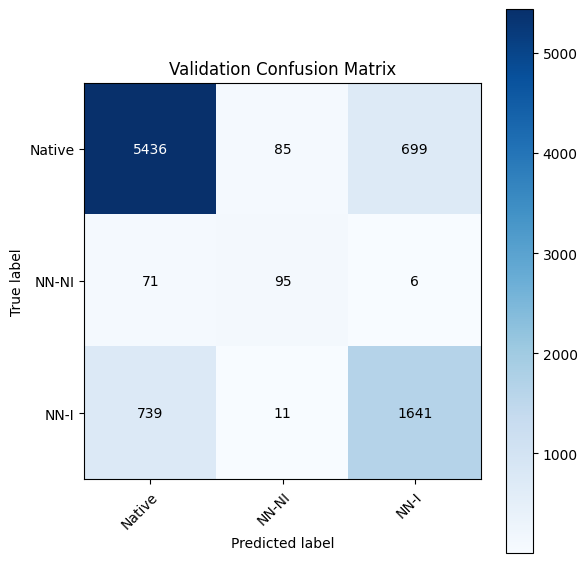


🔁 Epoch 50/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 974.10it/s]


📉 Train Loss: 0.3581 | Accuracy: 0.8449
📈 Val Loss:   0.4108 | Accuracy: 0.8087

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.84      0.86      6220
NN Non-Invasive       0.46      0.61      0.53       172
    NN Invasive       0.67      0.73      0.70      2391

       accuracy                           0.81      8783
      macro avg       0.67      0.73      0.70      8783
   weighted avg       0.82      0.81      0.81      8783



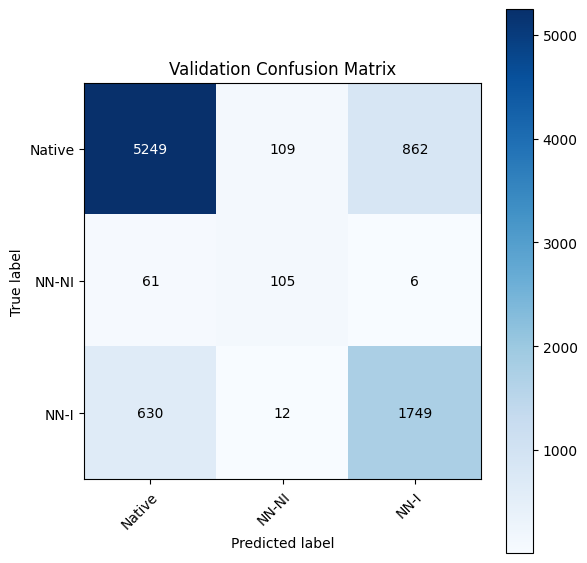

📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


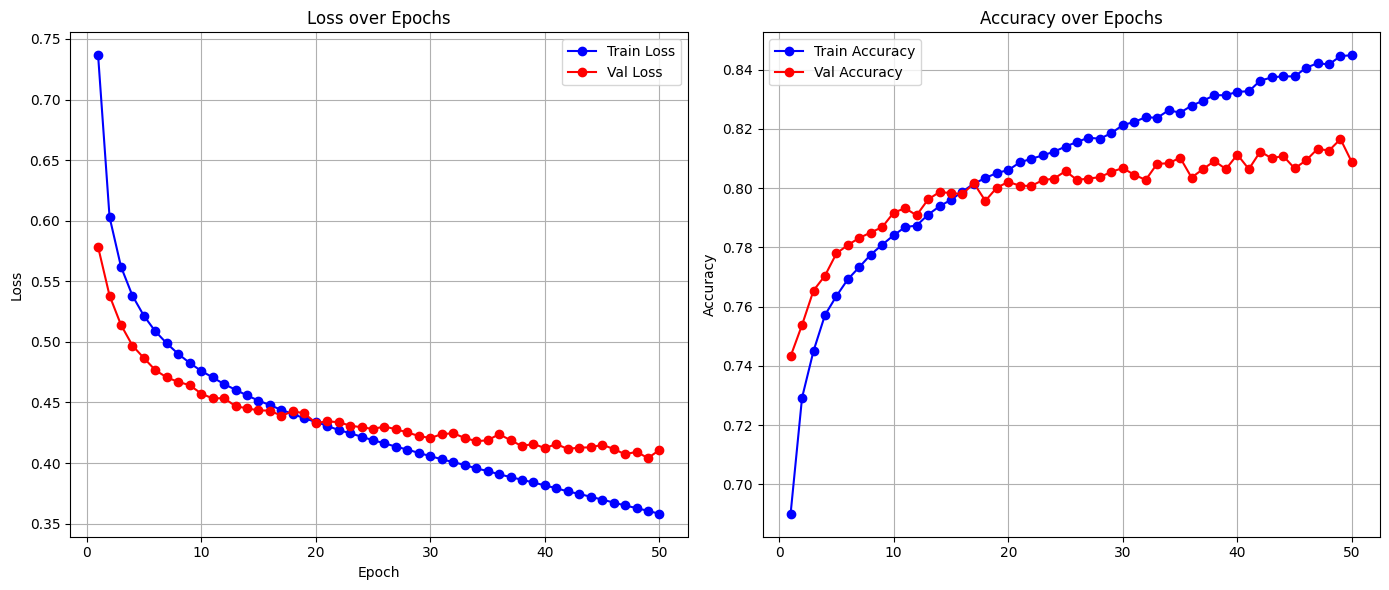

Full model built...
Total execution time: 201.27 seconds


In [61]:
model_name_BC1 = "epochs_50_augmented"
embeddings_save_path_BC1 = '/content/drive/MyDrive/Thesis/bioclip_1_embeddings.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=1, augmentation=True, output_dir="invasive_species", model_name=model_name_BC1, embeddings_save_path=embeddings_save_path_BC1, debug_subset_size=None)

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 29/29 [00:44<00:00,  1.53s/it]


Augmenting train dataset...
🔢 Class distribution in train set: Counter({0: 24864, 2: 9550, 1: 1620})
⚖️ Class weights: tensor([0.0988, 0.1353, 0.1091])

🔁 Epoch 1/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1114.37it/s]


📉 Train Loss: 0.7018 | Accuracy: 0.7025
📈 Val Loss:   0.5482 | Accuracy: 0.7463

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.79      0.86      0.83      6092
NN Non-Invasive       0.00      0.00      0.00       188
    NN Invasive       0.60      0.52      0.56      2503

       accuracy                           0.75      8783
      macro avg       0.47      0.46      0.46      8783
   weighted avg       0.72      0.75      0.73      8783



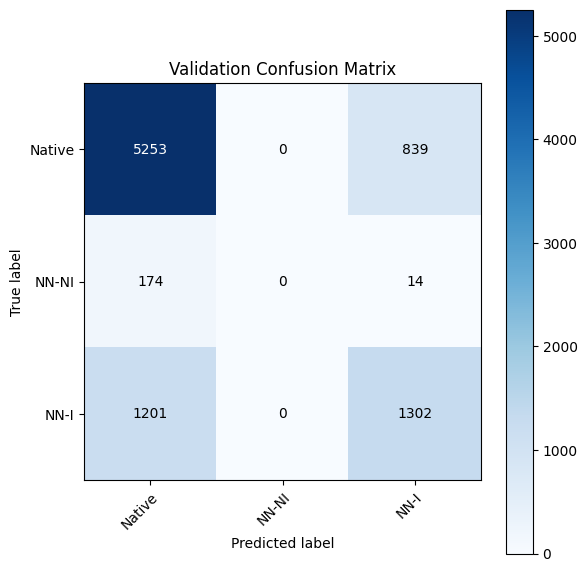


🔁 Epoch 2/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 782.76it/s]


📉 Train Loss: 0.5606 | Accuracy: 0.7362
📈 Val Loss:   0.4987 | Accuracy: 0.7645

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.83      0.83      6092
NN Non-Invasive       0.45      0.07      0.12       188
    NN Invasive       0.61      0.65      0.63      2503

       accuracy                           0.76      8783
      macro avg       0.63      0.52      0.53      8783
   weighted avg       0.76      0.76      0.76      8783



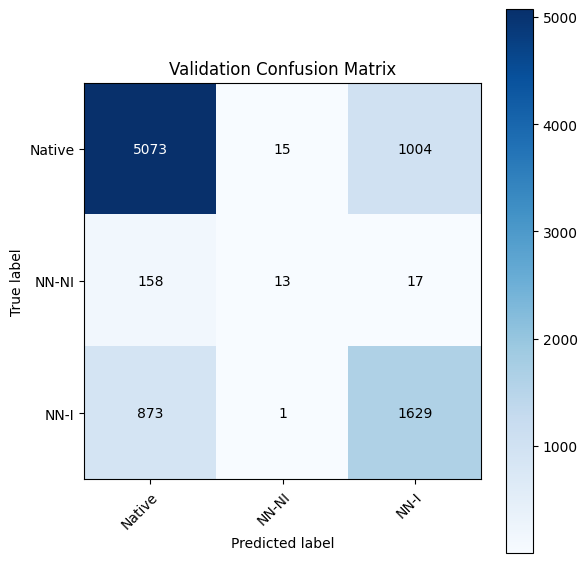


🔁 Epoch 3/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1030.97it/s]


📉 Train Loss: 0.5188 | Accuracy: 0.7541
📈 Val Loss:   0.4737 | Accuracy: 0.7748

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.83      0.85      0.84      6092
NN Non-Invasive       0.40      0.16      0.23       188
    NN Invasive       0.64      0.64      0.64      2503

       accuracy                           0.77      8783
      macro avg       0.63      0.55      0.57      8783
   weighted avg       0.77      0.77      0.77      8783



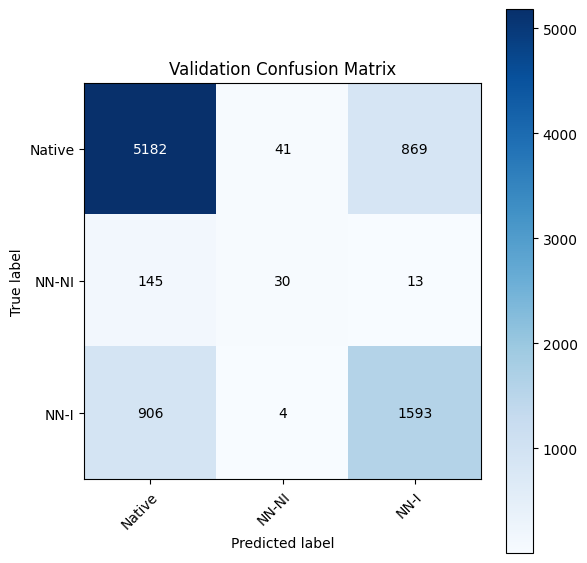


🔁 Epoch 4/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 986.68it/s]


📉 Train Loss: 0.4958 | Accuracy: 0.7643
📈 Val Loss:   0.4575 | Accuracy: 0.7833

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.84      0.84      6092
NN Non-Invasive       0.38      0.26      0.31       188
    NN Invasive       0.65      0.69      0.67      2503

       accuracy                           0.78      8783
      macro avg       0.63      0.60      0.61      8783
   weighted avg       0.78      0.78      0.78      8783



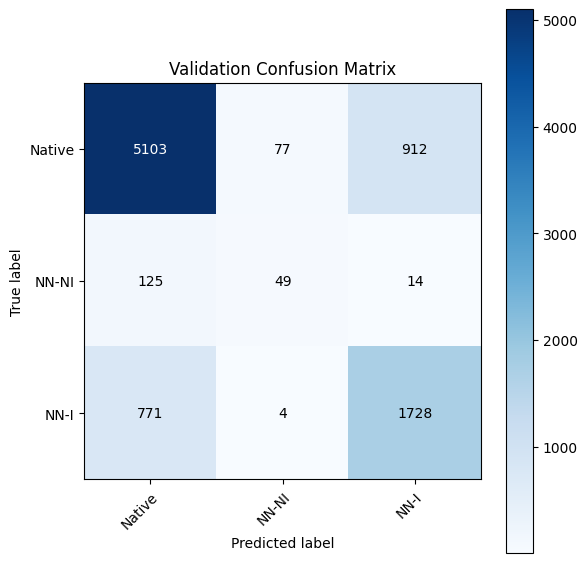


🔁 Epoch 5/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1062.31it/s]


📉 Train Loss: 0.4802 | Accuracy: 0.7738
📈 Val Loss:   0.4519 | Accuracy: 0.7904

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.87      0.85      6092
NN Non-Invasive       0.40      0.41      0.41       188
    NN Invasive       0.69      0.62      0.66      2503

       accuracy                           0.79      8783
      macro avg       0.64      0.63      0.64      8783
   weighted avg       0.79      0.79      0.79      8783



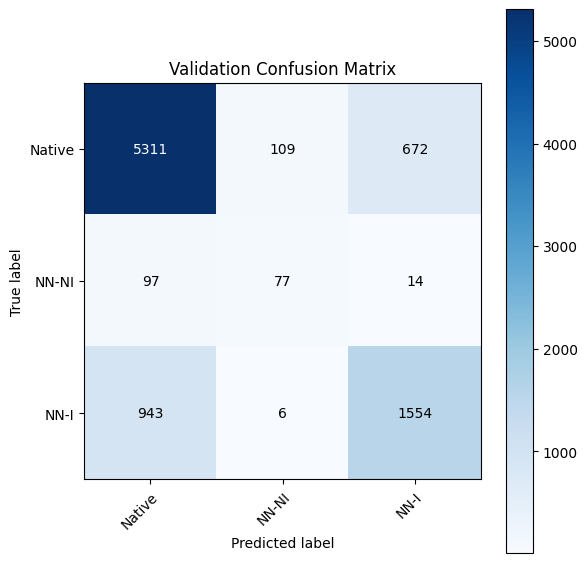


🔁 Epoch 6/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 763.14it/s]


📉 Train Loss: 0.4681 | Accuracy: 0.7808
📈 Val Loss:   0.4370 | Accuracy: 0.7946

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.86      0.85      6092
NN Non-Invasive       0.40      0.36      0.38       188
    NN Invasive       0.68      0.68      0.68      2503

       accuracy                           0.79      8783
      macro avg       0.64      0.63      0.64      8783
   weighted avg       0.79      0.79      0.79      8783



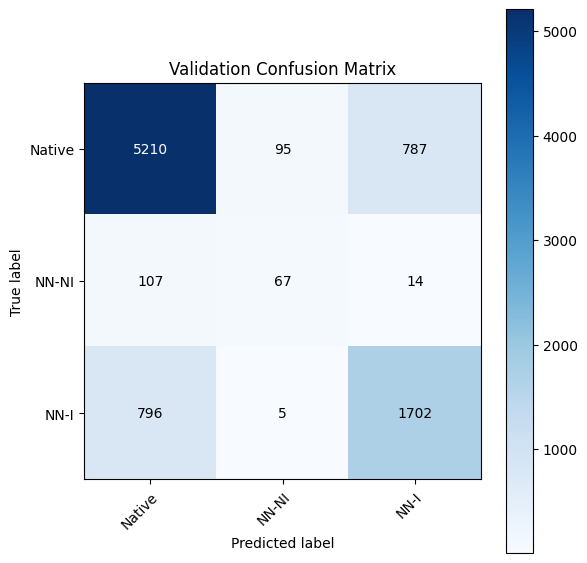


🔁 Epoch 7/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1044.29it/s]


📉 Train Loss: 0.4582 | Accuracy: 0.7877
📈 Val Loss:   0.4276 | Accuracy: 0.8009

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.86      0.86      6092
NN Non-Invasive       0.42      0.35      0.38       188
    NN Invasive       0.69      0.69      0.69      2503

       accuracy                           0.80      8783
      macro avg       0.65      0.63      0.64      8783
   weighted avg       0.80      0.80      0.80      8783



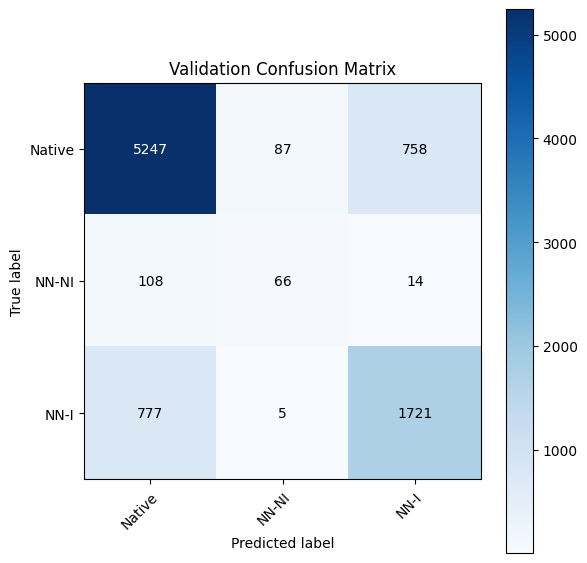


🔁 Epoch 8/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1056.98it/s]


📉 Train Loss: 0.4496 | Accuracy: 0.7920
📈 Val Loss:   0.4286 | Accuracy: 0.8003

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.83      0.85      6092
NN Non-Invasive       0.42      0.53      0.47       188
    NN Invasive       0.67      0.74      0.70      2503

       accuracy                           0.80      8783
      macro avg       0.66      0.70      0.68      8783
   weighted avg       0.81      0.80      0.80      8783



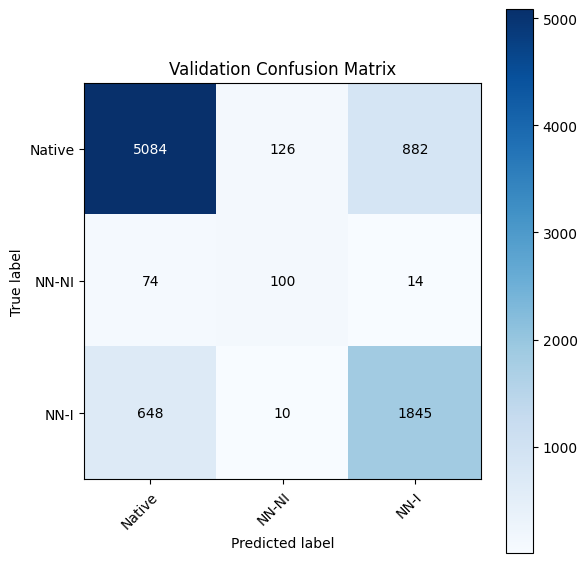


🔁 Epoch 9/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1061.62it/s]


📉 Train Loss: 0.4424 | Accuracy: 0.7983
📈 Val Loss:   0.4185 | Accuracy: 0.8002

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.82      0.85      6092
NN Non-Invasive       0.44      0.47      0.46       188
    NN Invasive       0.66      0.77      0.71      2503

       accuracy                           0.80      8783
      macro avg       0.66      0.69      0.67      8783
   weighted avg       0.81      0.80      0.80      8783



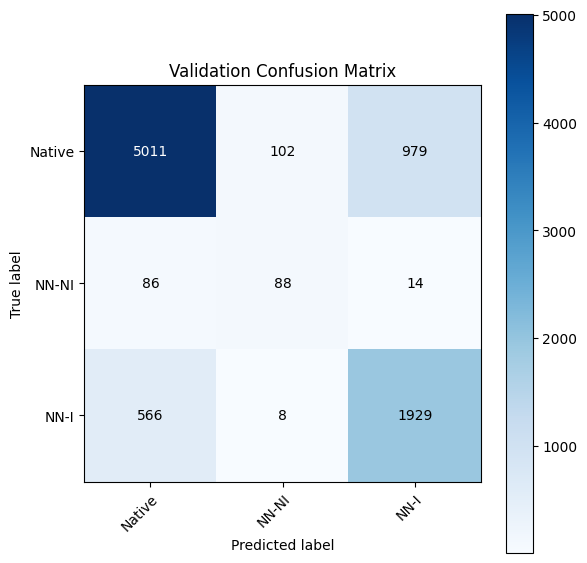


🔁 Epoch 10/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 728.85it/s]


📉 Train Loss: 0.4363 | Accuracy: 0.7998
📈 Val Loss:   0.4162 | Accuracy: 0.8027

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.83      0.85      6092
NN Non-Invasive       0.44      0.53      0.48       188
    NN Invasive       0.67      0.77      0.71      2503

       accuracy                           0.80      8783
      macro avg       0.67      0.71      0.68      8783
   weighted avg       0.81      0.80      0.81      8783



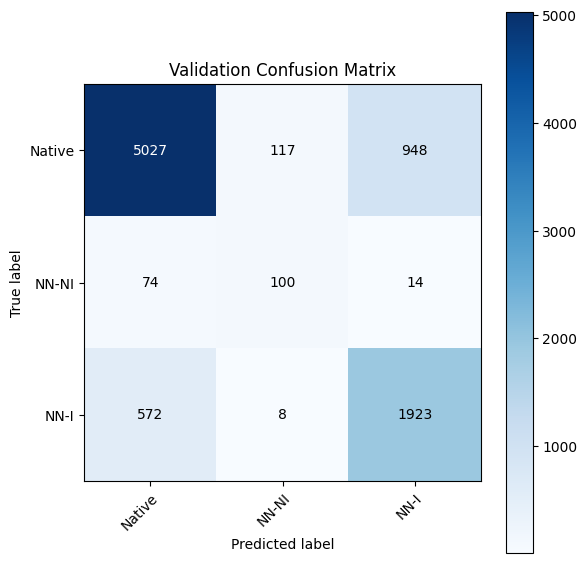


🔁 Epoch 11/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1078.46it/s]


📉 Train Loss: 0.4306 | Accuracy: 0.8031
📈 Val Loss:   0.4143 | Accuracy: 0.8103

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.86      6092
NN Non-Invasive       0.41      0.60      0.49       188
    NN Invasive       0.71      0.71      0.71      2503

       accuracy                           0.81      8783
      macro avg       0.66      0.72      0.69      8783
   weighted avg       0.81      0.81      0.81      8783



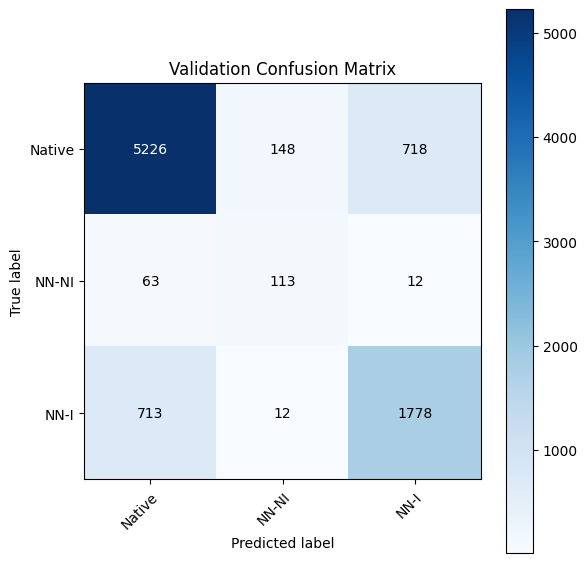


🔁 Epoch 12/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 981.67it/s] 


📉 Train Loss: 0.4256 | Accuracy: 0.8053
📈 Val Loss:   0.4040 | Accuracy: 0.8143

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.86      0.87      6092
NN Non-Invasive       0.48      0.47      0.48       188
    NN Invasive       0.70      0.73      0.71      2503

       accuracy                           0.81      8783
      macro avg       0.69      0.69      0.69      8783
   weighted avg       0.82      0.81      0.82      8783



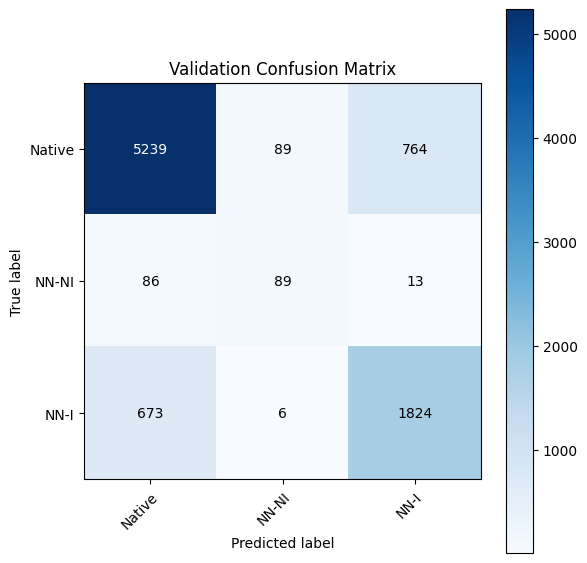


🔁 Epoch 13/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1037.56it/s]


📉 Train Loss: 0.4204 | Accuracy: 0.8078
📈 Val Loss:   0.3992 | Accuracy: 0.8191

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.86      0.88      0.87      6092
NN Non-Invasive       0.50      0.43      0.46       188
    NN Invasive       0.73      0.69      0.71      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.67      0.68      8783
   weighted avg       0.82      0.82      0.82      8783



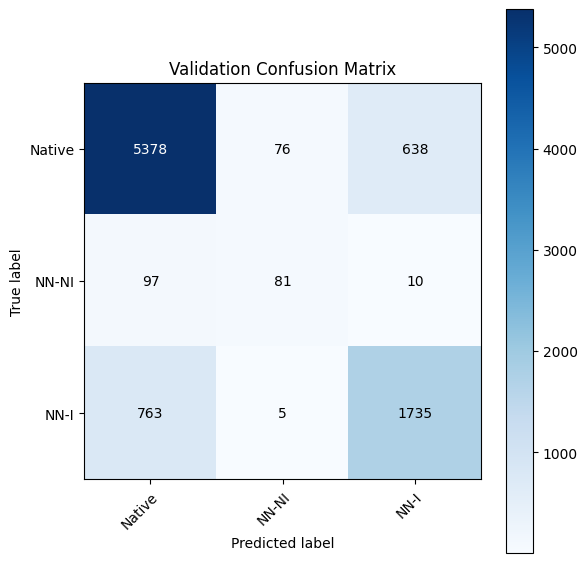


🔁 Epoch 14/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1036.30it/s]


📉 Train Loss: 0.4168 | Accuracy: 0.8107
📈 Val Loss:   0.4024 | Accuracy: 0.8181

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.84      0.91      0.88      6092
NN Non-Invasive       0.52      0.44      0.47       188
    NN Invasive       0.77      0.61      0.68      2503

       accuracy                           0.82      8783
      macro avg       0.71      0.65      0.68      8783
   weighted avg       0.81      0.82      0.81      8783



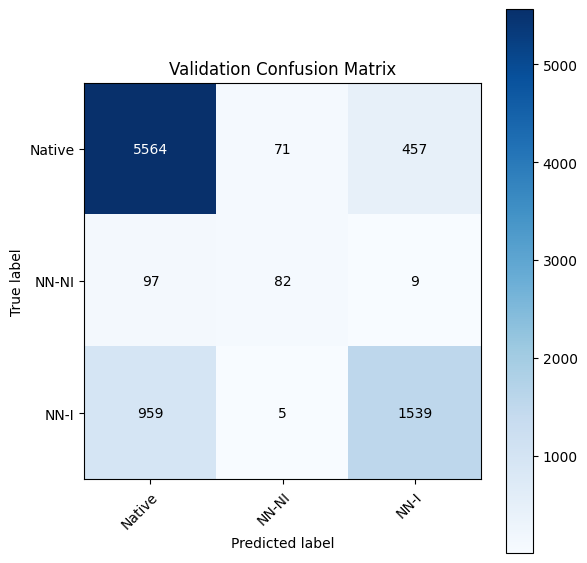


🔁 Epoch 15/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 830.73it/s]


📉 Train Loss: 0.4120 | Accuracy: 0.8125
📈 Val Loss:   0.3957 | Accuracy: 0.8215

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.87      0.87      6092
NN Non-Invasive       0.50      0.53      0.52       188
    NN Invasive       0.72      0.72      0.72      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.71      0.70      8783
   weighted avg       0.82      0.82      0.82      8783



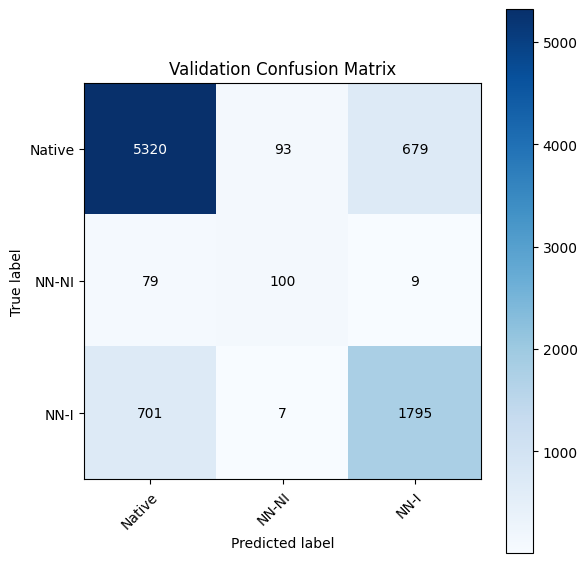


🔁 Epoch 16/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1052.16it/s]


📉 Train Loss: 0.4086 | Accuracy: 0.8153
📈 Val Loss:   0.3958 | Accuracy: 0.8194

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.90      0.87      6092
NN Non-Invasive       0.51      0.49      0.50       188
    NN Invasive       0.75      0.65      0.70      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.68      0.69      8783
   weighted avg       0.82      0.82      0.82      8783



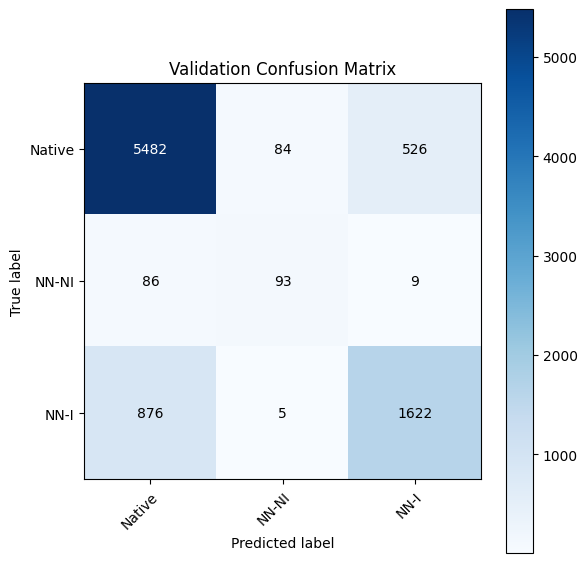


🔁 Epoch 17/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 989.72it/s]


📉 Train Loss: 0.4053 | Accuracy: 0.8173
📈 Val Loss:   0.3959 | Accuracy: 0.8225

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.85      0.91      0.88      6092
NN Non-Invasive       0.51      0.51      0.51       188
    NN Invasive       0.76      0.64      0.70      2503

       accuracy                           0.82      8783
      macro avg       0.71      0.68      0.69      8783
   weighted avg       0.82      0.82      0.82      8783



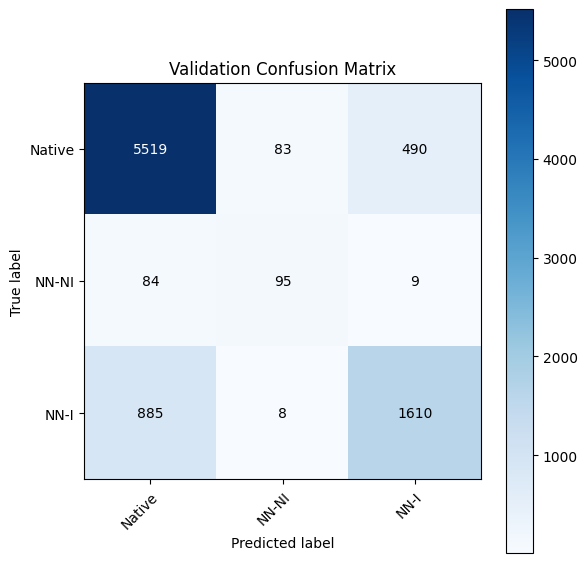


🔁 Epoch 18/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1034.49it/s]


📉 Train Loss: 0.4019 | Accuracy: 0.8182
📈 Val Loss:   0.3882 | Accuracy: 0.8199

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.86      0.87      6092
NN Non-Invasive       0.50      0.55      0.53       188
    NN Invasive       0.70      0.75      0.73      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.72      0.71      8783
   weighted avg       0.82      0.82      0.82      8783



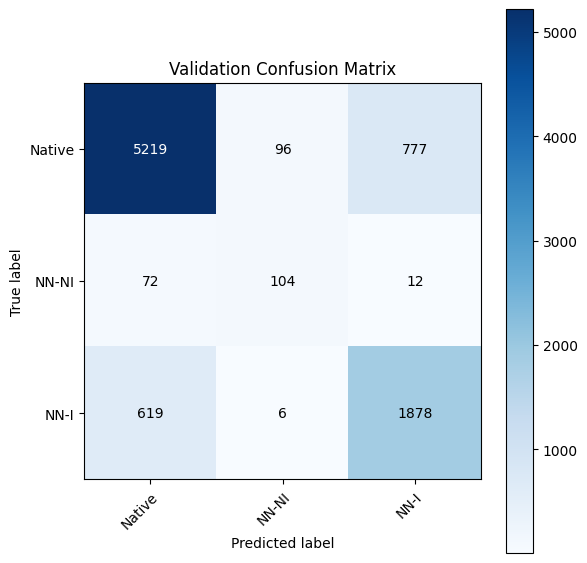


🔁 Epoch 19/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 997.97it/s] 


📉 Train Loss: 0.3985 | Accuracy: 0.8198
📈 Val Loss:   0.3884 | Accuracy: 0.8241

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.88      0.88      6092
NN Non-Invasive       0.49      0.57      0.53       188
    NN Invasive       0.73      0.71      0.72      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.72      0.71      8783
   weighted avg       0.82      0.82      0.82      8783



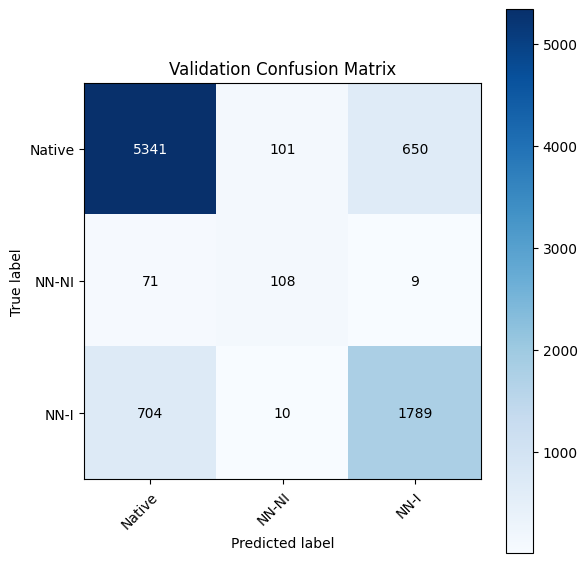


🔁 Epoch 20/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 765.73it/s]


📉 Train Loss: 0.3957 | Accuracy: 0.8201
📈 Val Loss:   0.3847 | Accuracy: 0.8276

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.89      0.88      6092
NN Non-Invasive       0.52      0.59      0.55       188
    NN Invasive       0.74      0.70      0.72      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.73      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



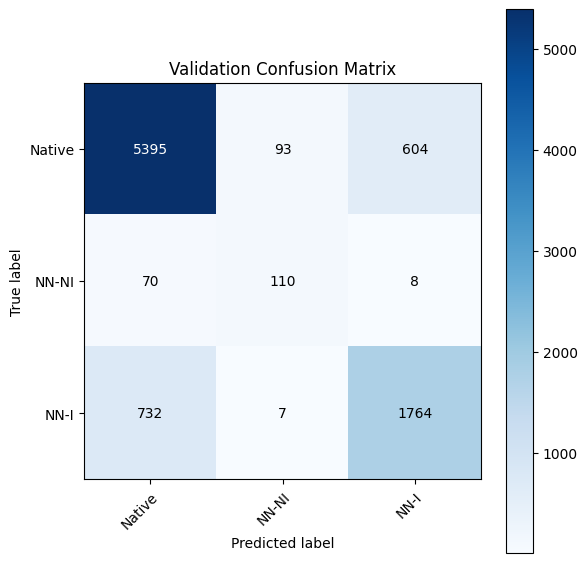


🔁 Epoch 21/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1040.67it/s]


📉 Train Loss: 0.3928 | Accuracy: 0.8222
📈 Val Loss:   0.3843 | Accuracy: 0.8228

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.87      6092
NN Non-Invasive       0.50      0.62      0.56       188
    NN Invasive       0.71      0.76      0.73      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.74      0.72      8783
   weighted avg       0.83      0.82      0.82      8783



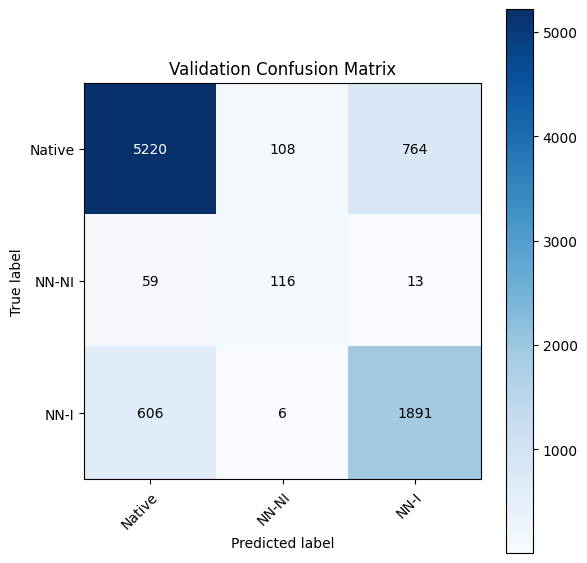


🔁 Epoch 22/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1036.81it/s]


📉 Train Loss: 0.3905 | Accuracy: 0.8234
📈 Val Loss:   0.3847 | Accuracy: 0.8232

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.87      6092
NN Non-Invasive       0.47      0.65      0.54       188
    NN Invasive       0.72      0.75      0.73      2503

       accuracy                           0.82      8783
      macro avg       0.69      0.75      0.72      8783
   weighted avg       0.83      0.82      0.83      8783



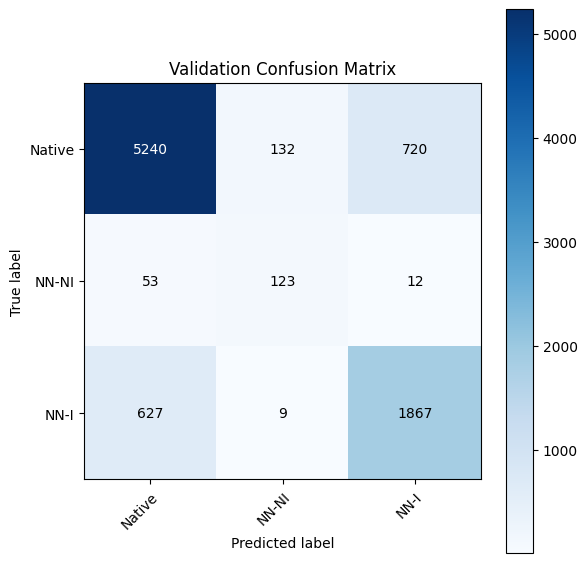


🔁 Epoch 23/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1042.72it/s]


📉 Train Loss: 0.3875 | Accuracy: 0.8241
📈 Val Loss:   0.3842 | Accuracy: 0.8181

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.90      0.83      0.87      6092
NN Non-Invasive       0.50      0.61      0.55       188
    NN Invasive       0.68      0.79      0.74      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.74      0.72      8783
   weighted avg       0.83      0.82      0.82      8783



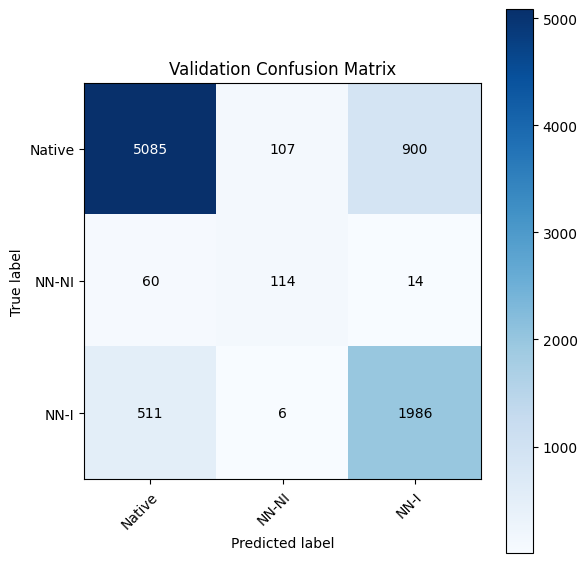


🔁 Epoch 24/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 750.79it/s]


📉 Train Loss: 0.3852 | Accuracy: 0.8269
📈 Val Loss:   0.3823 | Accuracy: 0.8278

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.89      0.88      6092
NN Non-Invasive       0.50      0.63      0.56       188
    NN Invasive       0.76      0.68      0.72      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.74      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



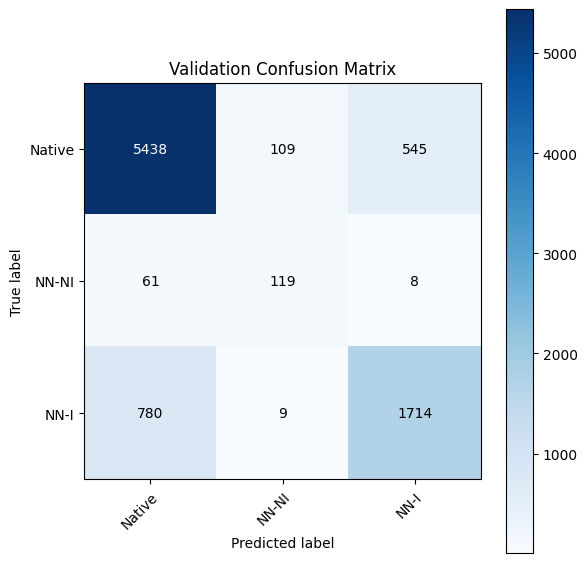


🔁 Epoch 25/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 972.06it/s] 


📉 Train Loss: 0.3831 | Accuracy: 0.8273
📈 Val Loss:   0.3752 | Accuracy: 0.8284

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6092
NN Non-Invasive       0.53      0.57      0.55       188
    NN Invasive       0.73      0.73      0.73      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.73      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



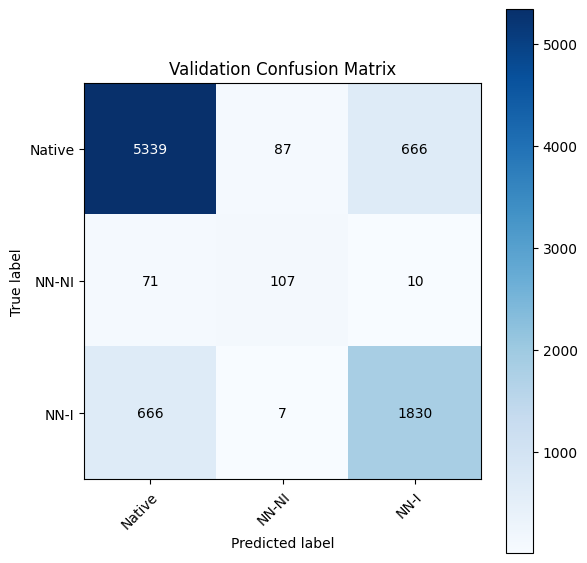


🔁 Epoch 26/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1026.43it/s]


📉 Train Loss: 0.3808 | Accuracy: 0.8278
📈 Val Loss:   0.3776 | Accuracy: 0.8293

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.90      0.88      6092
NN Non-Invasive       0.53      0.59      0.55       188
    NN Invasive       0.76      0.69      0.72      2503

       accuracy                           0.83      8783
      macro avg       0.72      0.72      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



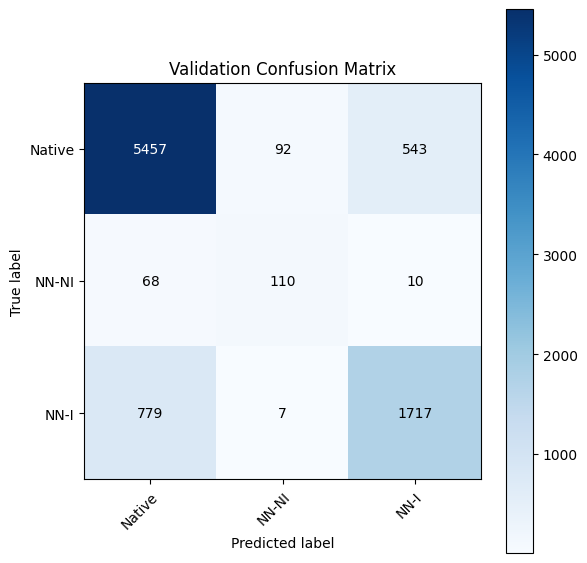


🔁 Epoch 27/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 1020.90it/s]


📉 Train Loss: 0.3781 | Accuracy: 0.8307
📈 Val Loss:   0.3774 | Accuracy: 0.8244

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.85      0.87      6092
NN Non-Invasive       0.48      0.66      0.56       188
    NN Invasive       0.71      0.77      0.74      2503

       accuracy                           0.82      8783
      macro avg       0.70      0.76      0.72      8783
   weighted avg       0.83      0.82      0.83      8783



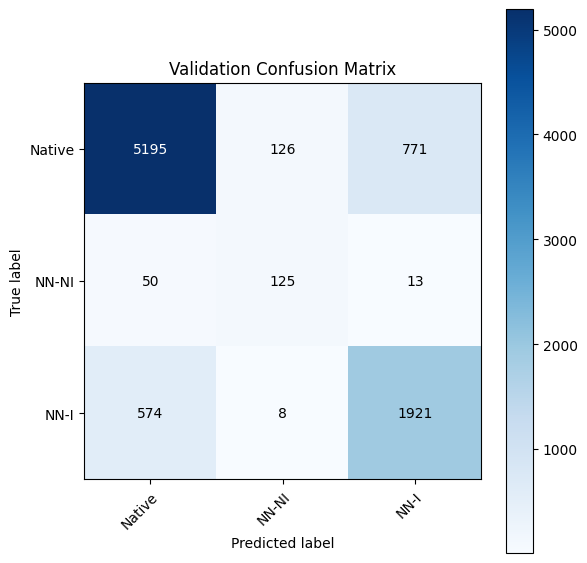


🔁 Epoch 28/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 982.78it/s]


📉 Train Loss: 0.3766 | Accuracy: 0.8289
📈 Val Loss:   0.3732 | Accuracy: 0.8299

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6092
NN Non-Invasive       0.52      0.61      0.56       188
    NN Invasive       0.74      0.72      0.73      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.74      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



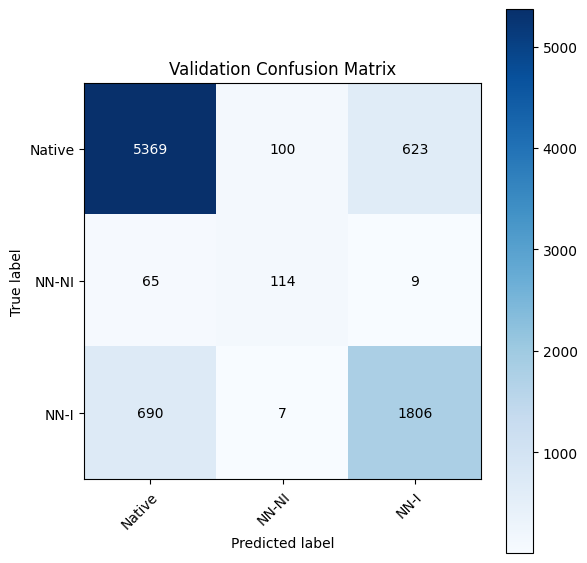


🔁 Epoch 29/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 698.18it/s]


📉 Train Loss: 0.3743 | Accuracy: 0.8322
📈 Val Loss:   0.3764 | Accuracy: 0.8291

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.89      0.88      6092
NN Non-Invasive       0.49      0.66      0.57       188
    NN Invasive       0.75      0.71      0.73      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.75      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



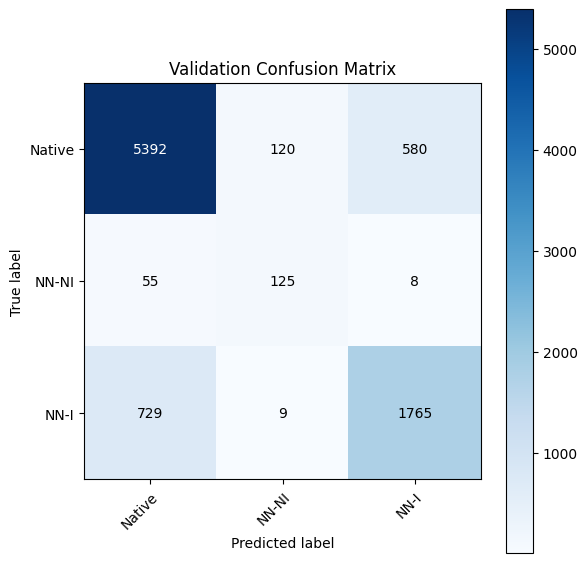


🔁 Epoch 30/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 995.28it/s] 


📉 Train Loss: 0.3723 | Accuracy: 0.8322
📈 Val Loss:   0.3720 | Accuracy: 0.8314

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.88      6092
NN Non-Invasive       0.51      0.60      0.55       188
    NN Invasive       0.75      0.72      0.73      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.73      0.72      8783
   weighted avg       0.83      0.83      0.83      8783



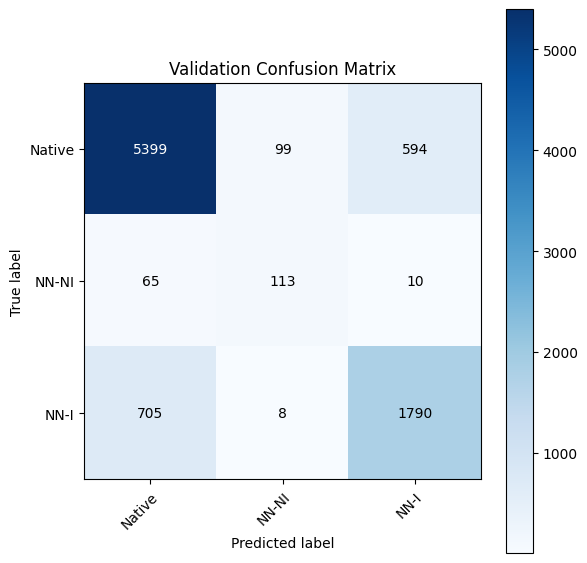


🔁 Epoch 31/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 959.81it/s]


📉 Train Loss: 0.3705 | Accuracy: 0.8319
📈 Val Loss:   0.3686 | Accuracy: 0.8326

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6092
NN Non-Invasive       0.57      0.57      0.57       188
    NN Invasive       0.73      0.75      0.74      2503

       accuracy                           0.83      8783
      macro avg       0.73      0.73      0.73      8783
   weighted avg       0.83      0.83      0.83      8783



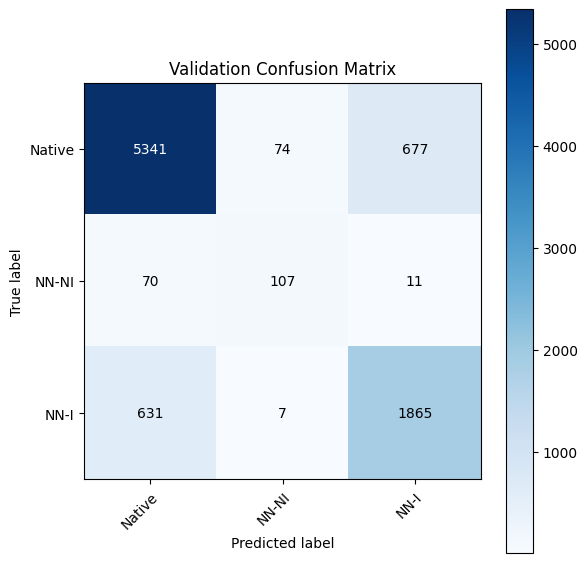


🔁 Epoch 32/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 998.04it/s]


📉 Train Loss: 0.3686 | Accuracy: 0.8342
📈 Val Loss:   0.3736 | Accuracy: 0.8304

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6092
NN Non-Invasive       0.49      0.66      0.56       188
    NN Invasive       0.73      0.75      0.74      2503

       accuracy                           0.83      8783
      macro avg       0.70      0.76      0.73      8783
   weighted avg       0.83      0.83      0.83      8783



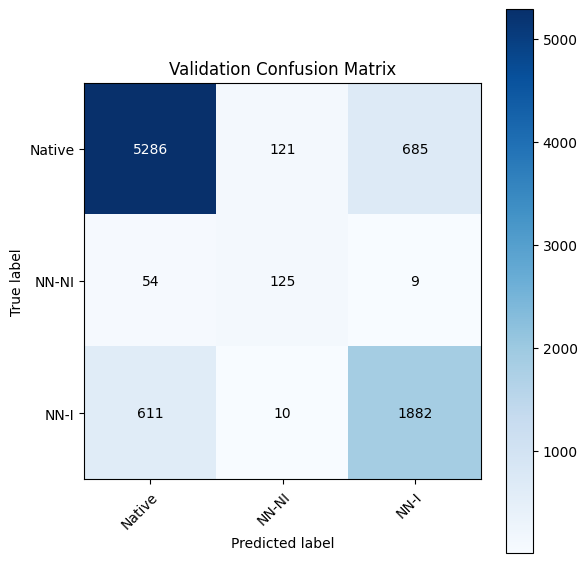


🔁 Epoch 33/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 678.01it/s]


📉 Train Loss: 0.3669 | Accuracy: 0.8350
📈 Val Loss:   0.3687 | Accuracy: 0.8317

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6092
NN Non-Invasive       0.55      0.63      0.59       188
    NN Invasive       0.73      0.75      0.74      2503

       accuracy                           0.83      8783
      macro avg       0.72      0.75      0.74      8783
   weighted avg       0.83      0.83      0.83      8783



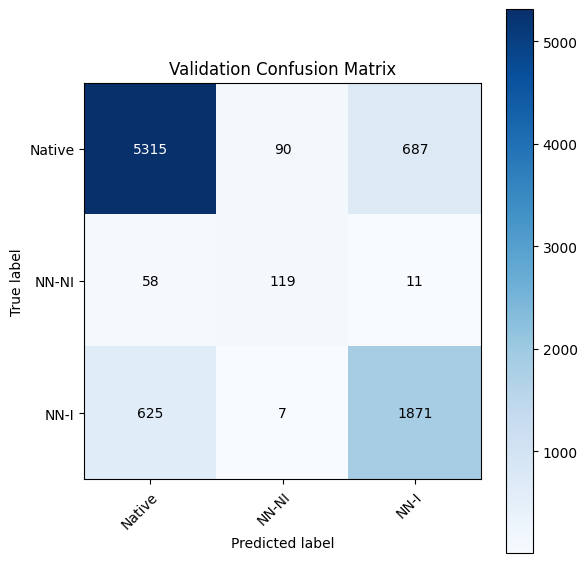


🔁 Epoch 34/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 940.31it/s]


📉 Train Loss: 0.3645 | Accuracy: 0.8372
📈 Val Loss:   0.3688 | Accuracy: 0.8302

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.86      0.88      6092
NN Non-Invasive       0.53      0.64      0.58       188
    NN Invasive       0.72      0.76      0.74      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.76      0.73      8783
   weighted avg       0.83      0.83      0.83      8783



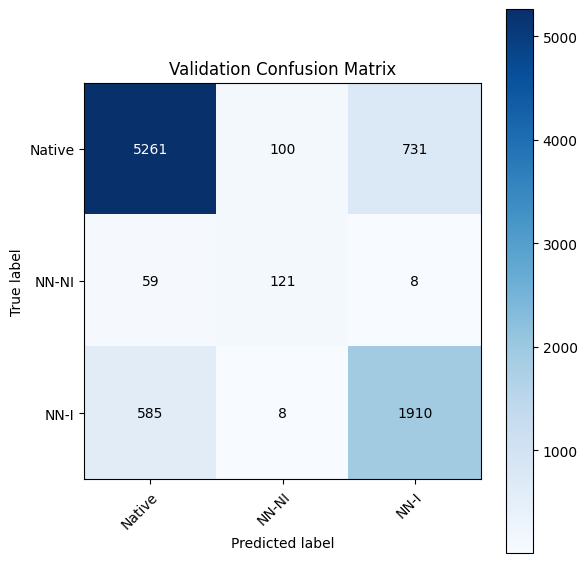


🔁 Epoch 35/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 952.16it/s]


📉 Train Loss: 0.3636 | Accuracy: 0.8363
📈 Val Loss:   0.3693 | Accuracy: 0.8334

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.90      0.88      6092
NN Non-Invasive       0.53      0.65      0.59       188
    NN Invasive       0.77      0.69      0.73      2503

       accuracy                           0.83      8783
      macro avg       0.72      0.75      0.73      8783
   weighted avg       0.83      0.83      0.83      8783



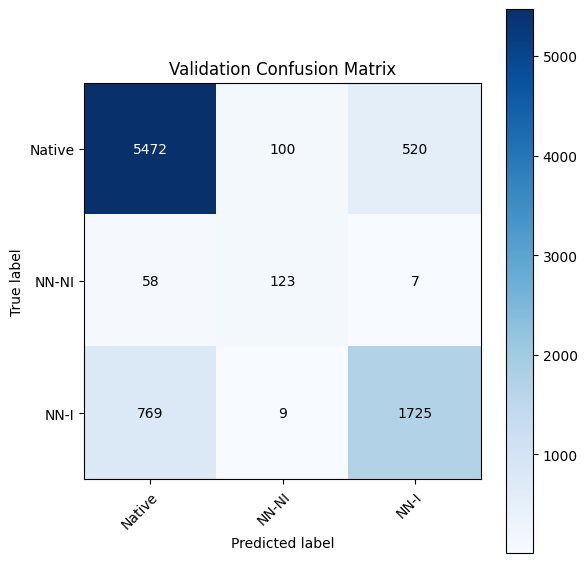


🔁 Epoch 36/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 999.70it/s] 


📉 Train Loss: 0.3617 | Accuracy: 0.8382
📈 Val Loss:   0.3641 | Accuracy: 0.8375

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.88      6092
NN Non-Invasive       0.58      0.61      0.60       188
    NN Invasive       0.75      0.73      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.74      0.74      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



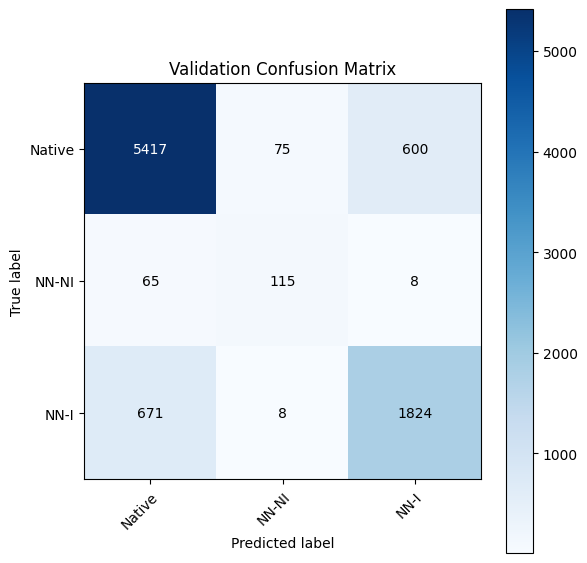


🔁 Epoch 37/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 982.00it/s] 


📉 Train Loss: 0.3601 | Accuracy: 0.8378
📈 Val Loss:   0.3655 | Accuracy: 0.8355

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6092
NN Non-Invasive       0.53      0.68      0.59       188
    NN Invasive       0.75      0.73      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.72      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



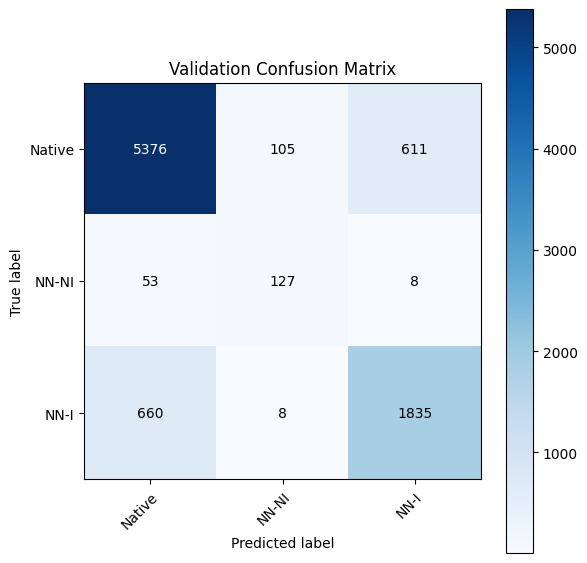


🔁 Epoch 38/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 716.10it/s]


📉 Train Loss: 0.3585 | Accuracy: 0.8398
📈 Val Loss:   0.3625 | Accuracy: 0.8379

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6092
NN Non-Invasive       0.56      0.63      0.59       188
    NN Invasive       0.76      0.72      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.73      0.75      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



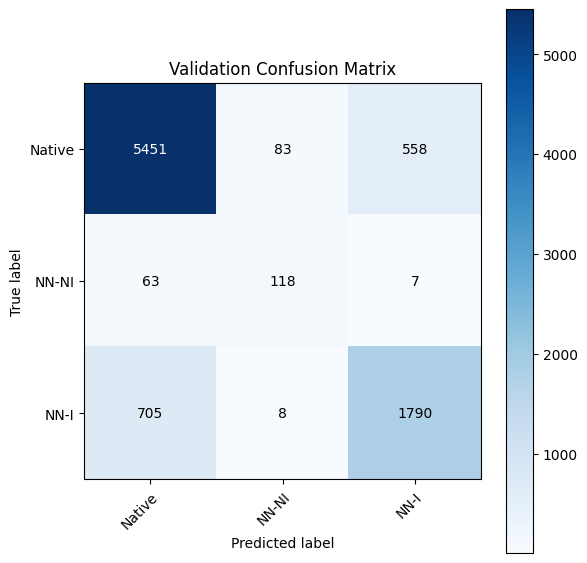


🔁 Epoch 39/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 955.85it/s]


📉 Train Loss: 0.3569 | Accuracy: 0.8406
📈 Val Loss:   0.3624 | Accuracy: 0.8370

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.88      6092
NN Non-Invasive       0.57      0.60      0.59       188
    NN Invasive       0.76      0.72      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.73      0.74      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



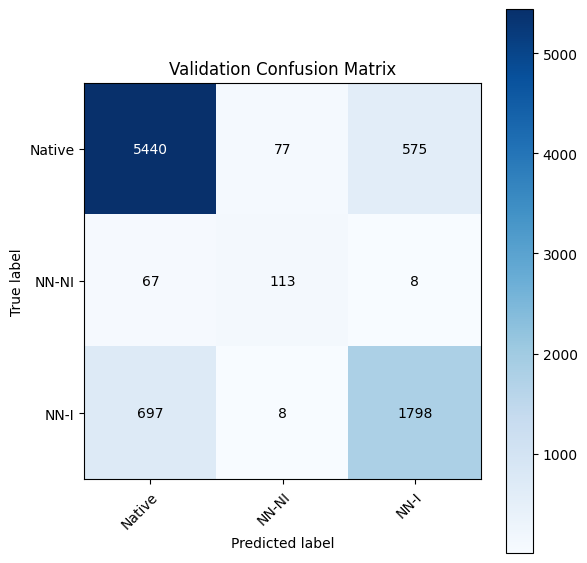


🔁 Epoch 40/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 962.85it/s]


📉 Train Loss: 0.3560 | Accuracy: 0.8418
📈 Val Loss:   0.3644 | Accuracy: 0.8375

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.90      0.89      6092
NN Non-Invasive       0.56      0.66      0.60       188
    NN Invasive       0.77      0.70      0.73      2503

       accuracy                           0.84      8783
      macro avg       0.73      0.75      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



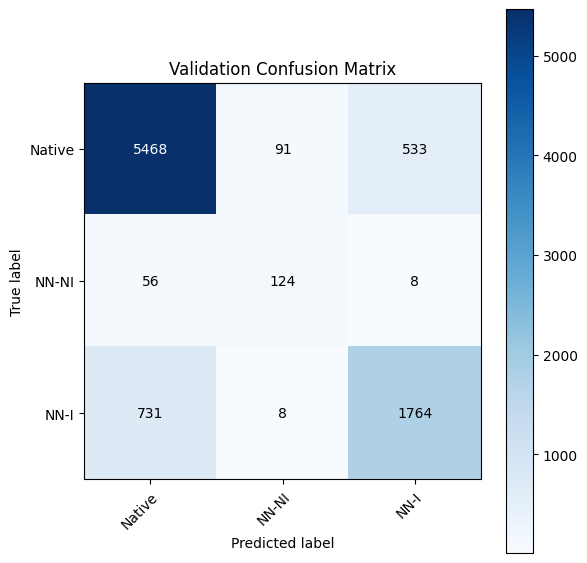


🔁 Epoch 41/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 931.98it/s]


📉 Train Loss: 0.3540 | Accuracy: 0.8417
📈 Val Loss:   0.3598 | Accuracy: 0.8378

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.90      0.89      6092
NN Non-Invasive       0.61      0.57      0.59       188
    NN Invasive       0.76      0.70      0.73      2503

       accuracy                           0.84      8783
      macro avg       0.75      0.73      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



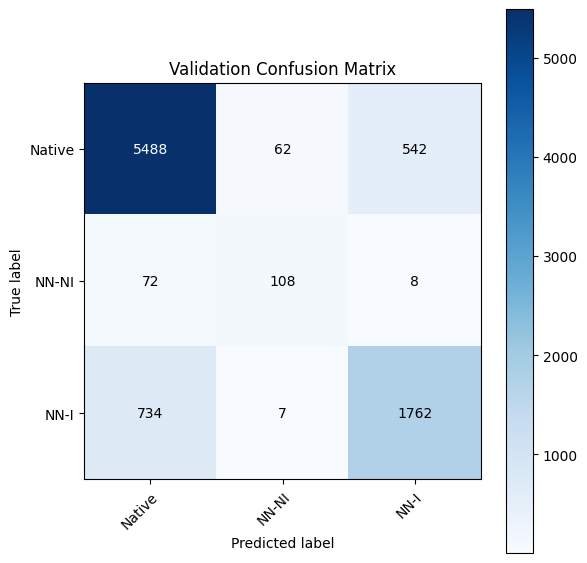


🔁 Epoch 42/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 712.80it/s]


📉 Train Loss: 0.3527 | Accuracy: 0.8430
📈 Val Loss:   0.3622 | Accuracy: 0.8335

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6092
NN Non-Invasive       0.54      0.68      0.60       188
    NN Invasive       0.73      0.76      0.74      2503

       accuracy                           0.83      8783
      macro avg       0.72      0.77      0.74      8783
   weighted avg       0.84      0.83      0.84      8783



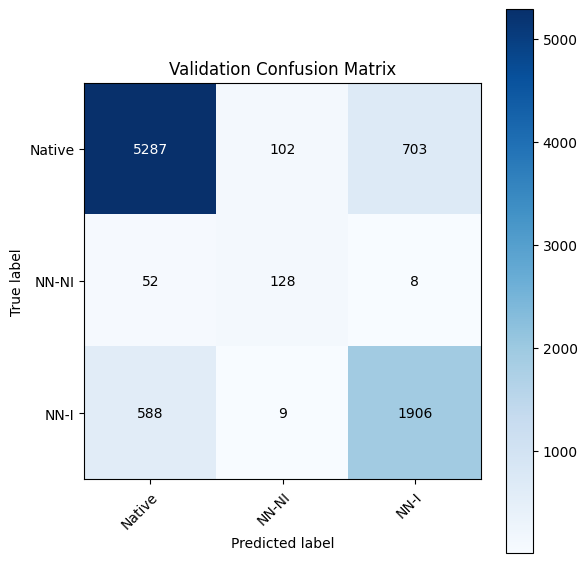


🔁 Epoch 43/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 925.31it/s]


📉 Train Loss: 0.3513 | Accuracy: 0.8420
📈 Val Loss:   0.3599 | Accuracy: 0.8342

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6092
NN Non-Invasive       0.56      0.65      0.60       188
    NN Invasive       0.73      0.76      0.74      2503

       accuracy                           0.83      8783
      macro avg       0.73      0.76      0.74      8783
   weighted avg       0.84      0.83      0.84      8783



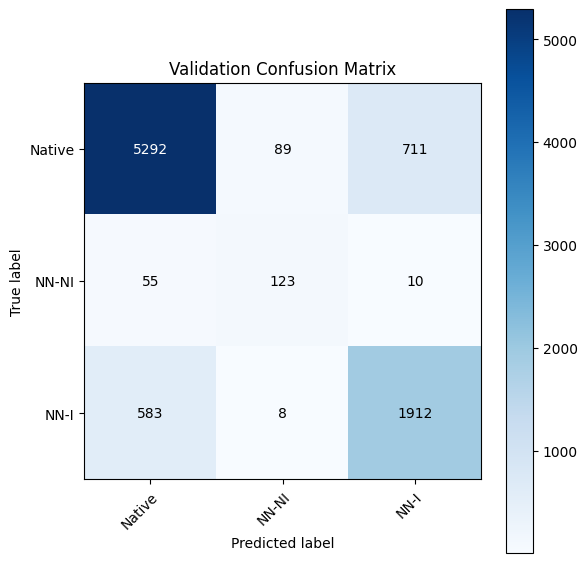


🔁 Epoch 44/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 946.71it/s]


📉 Train Loss: 0.3500 | Accuracy: 0.8435
📈 Val Loss:   0.3627 | Accuracy: 0.8348

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6092
NN Non-Invasive       0.52      0.71      0.60       188
    NN Invasive       0.74      0.75      0.75      2503

       accuracy                           0.83      8783
      macro avg       0.71      0.78      0.74      8783
   weighted avg       0.84      0.83      0.84      8783



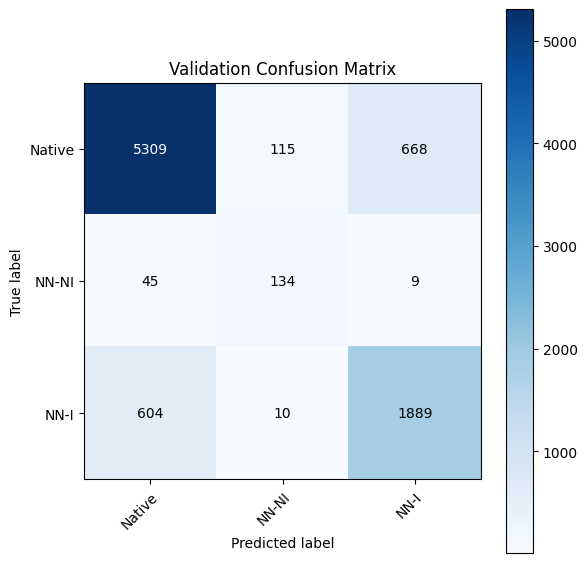


🔁 Epoch 45/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 968.31it/s]


📉 Train Loss: 0.3488 | Accuracy: 0.8440
📈 Val Loss:   0.3583 | Accuracy: 0.8374

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.88      0.88      6092
NN Non-Invasive       0.56      0.65      0.61       188
    NN Invasive       0.75      0.74      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.73      0.76      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



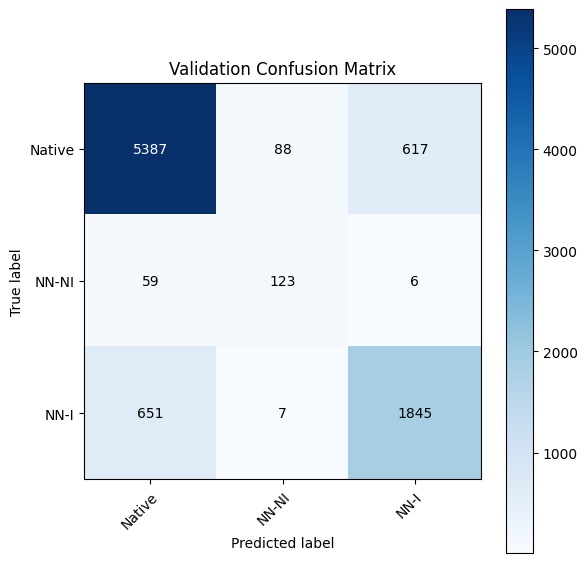


🔁 Epoch 46/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 956.62it/s]


📉 Train Loss: 0.3479 | Accuracy: 0.8450
📈 Val Loss:   0.3582 | Accuracy: 0.8379

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.90      0.89      6092
NN Non-Invasive       0.58      0.61      0.60       188
    NN Invasive       0.77      0.70      0.73      2503

       accuracy                           0.84      8783
      macro avg       0.74      0.74      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



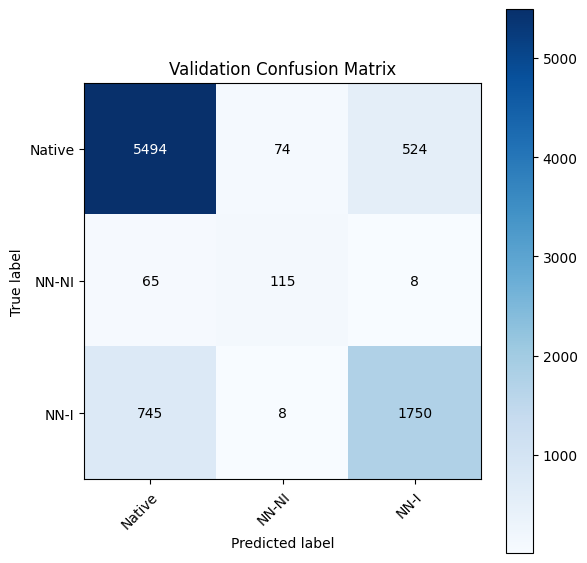


🔁 Epoch 47/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 746.72it/s]


📉 Train Loss: 0.3464 | Accuracy: 0.8456
📈 Val Loss:   0.3573 | Accuracy: 0.8379

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6092
NN Non-Invasive       0.58      0.64      0.61       188
    NN Invasive       0.76      0.72      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.74      0.75      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



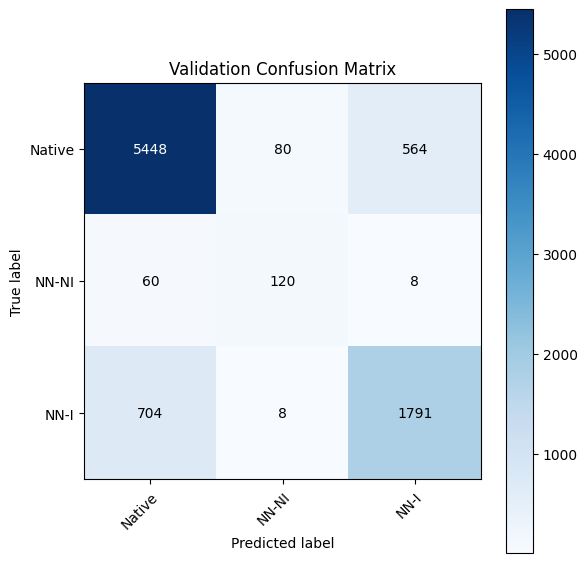


🔁 Epoch 48/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 963.20it/s]


📉 Train Loss: 0.3443 | Accuracy: 0.8455
📈 Val Loss:   0.3641 | Accuracy: 0.8370

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.87      0.90      0.89      6092
NN Non-Invasive       0.51      0.71      0.60       188
    NN Invasive       0.78      0.70      0.73      2503

       accuracy                           0.84      8783
      macro avg       0.72      0.77      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



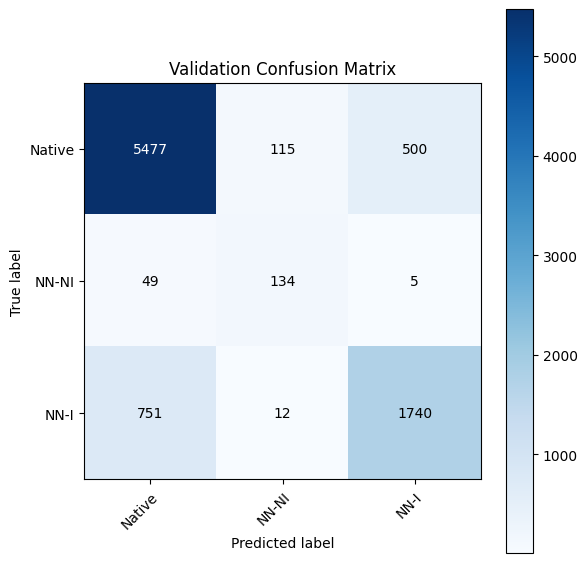


🔁 Epoch 49/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 974.13it/s]


📉 Train Loss: 0.3439 | Accuracy: 0.8466
📈 Val Loss:   0.3571 | Accuracy: 0.8387

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.88      0.89      0.89      6092
NN Non-Invasive       0.61      0.62      0.61       188
    NN Invasive       0.75      0.73      0.74      2503

       accuracy                           0.84      8783
      macro avg       0.75      0.75      0.75      8783
   weighted avg       0.84      0.84      0.84      8783



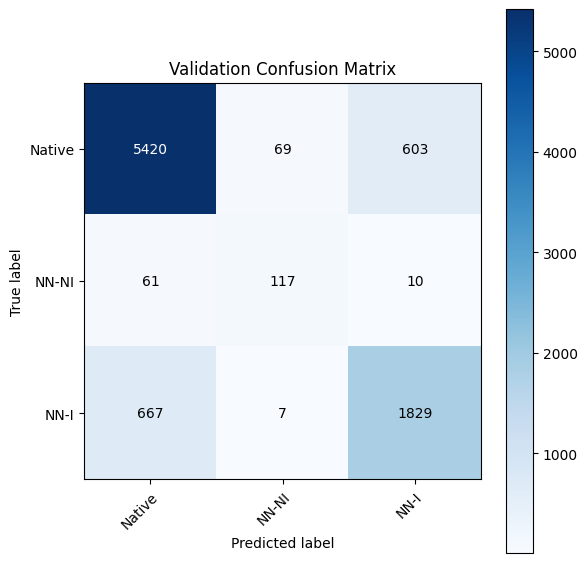


🔁 Epoch 50/50


Evaluating: 100%|██████████| 275/275 [00:00<00:00, 961.81it/s]


📉 Train Loss: 0.3424 | Accuracy: 0.8473
📈 Val Loss:   0.3627 | Accuracy: 0.8351

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.89      0.87      0.88      6092
NN Non-Invasive       0.49      0.78      0.60       188
    NN Invasive       0.75      0.75      0.75      2503

       accuracy                           0.84      8783
      macro avg       0.71      0.80      0.74      8783
   weighted avg       0.84      0.84      0.84      8783



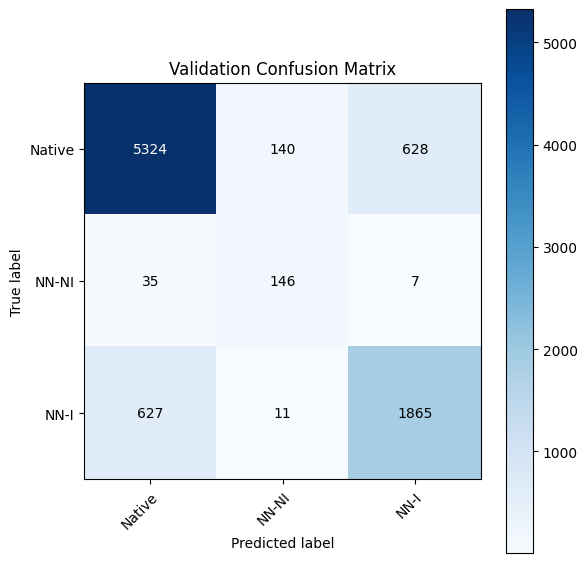

📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


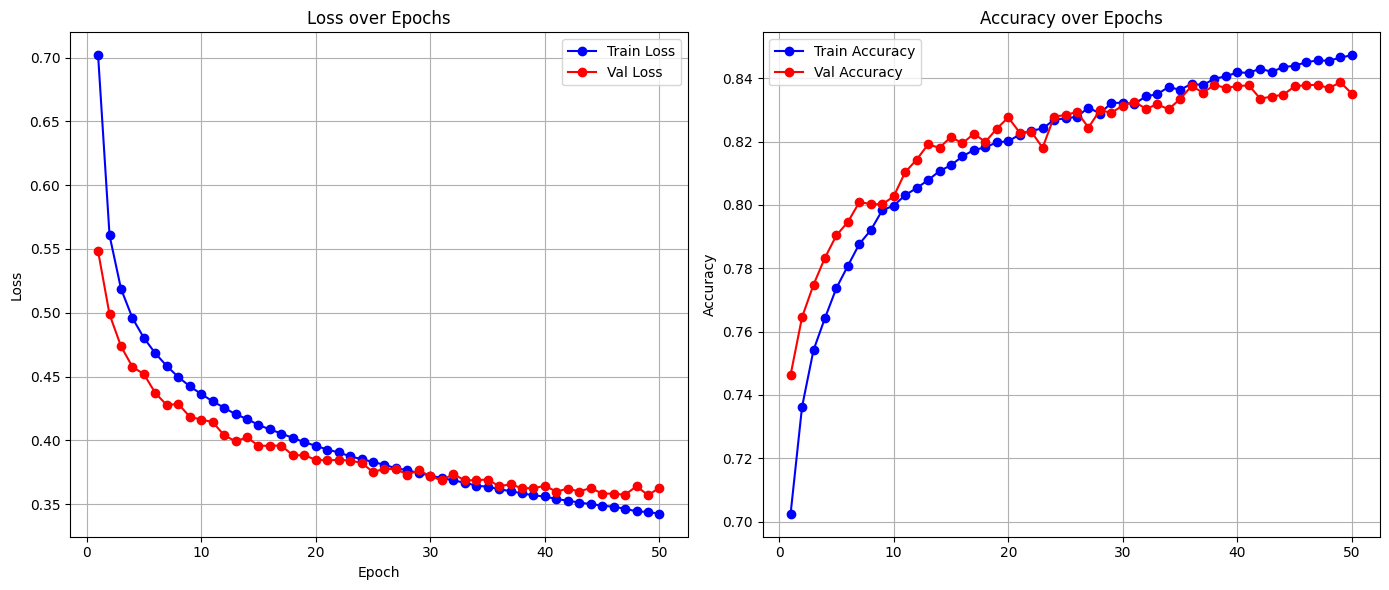

Full model built...
Total execution time: 300.90 seconds


In [62]:
model_name_BC2 = "epochs_50_augmented"
embeddings_save_path_BC2 = '/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt'
create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, bioclip_version=2, output_dir="invasive_species", model_name=model_name, embeddings_save_path=embeddings_save_path_BC2, debug_subset_size=None)